In [ ]:
#Set up Spark in Colab
######################
!pip install -q pyspark
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("Spark_in_Colab").getOrCreate()
spark.createDataFrame([{"status": "Spark is working!", "location": "Google Colab"}]).show()

#Mount your Google Drive folder so you can access your data files on Colab
from google.colab import drive
drive.mount('/content/drive')

+------------+-----------------+
|    location|           status|
+------------+-----------------+
|Google Colab|Spark is working!|
+------------+-----------------+

Mounted at /content/drive


In [ ]:
#Initialize packages
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# **Step 1: Cleaning the data**

In [ ]:
#Setting the file paths for the datasets used in this notebook
Order_items = "/content/drive/MyDrive/1. Big Data/Data/order_items.parquet"
Orders = "/content/drive/MyDrive/1. Big Data/Data/orders.parquet"
Products = "/content/drive/MyDrive/1. Big Data/Data/products.parquet"
Website_pageviews = "/content/drive/MyDrive/1. Big Data/Data/website_pageviews.parquet"
Website_sessions = "/content/drive/MyDrive/1. Big Data/Data/website_sessions.parquet"

# File for test model
website_pageviews_holdout = "/content/drive/MyDrive/1. Big Data/Data/website_pageviews_holdout.parquet"
website_sessions_holdout = "/content/drive/MyDrive/1. Big Data/Data/website_sessions_holdout.parquet"

In [ ]:
#Read()
Order_items=spark.read.format("parquet").load(Order_items)
Orders=spark.read.format("parquet").load(Orders)
Products=spark.read.format("parquet").load(Products)
Website_pageviews=spark.read.format("parquet").load(Website_pageviews)
Website_sessions=spark.read.format("parquet").load(Website_sessions)


website_pageviews_holdout=spark.read.format("parquet").load(website_pageviews_holdout)
website_sessions_holdout=spark.read.format("parquet").load(website_sessions_holdout)


##Clean Order_items

In [ ]:
Order_items.show(5)

+-------------+-------------------+--------+----------+---------------+----------+---------+
|order_item_id|         created_at|order_id|product_id|is_primary_item|price_euro|cogs_euro|
+-------------+-------------------+--------+----------+---------------+----------+---------+
|            1|2022-03-19 10:42:46|       1|         1|              1|    149.99|    69.49|
|            2|2022-03-19 19:27:37|       2|         1|              1|    149.99|    69.49|
|            3|2022-03-20 06:44:45|       3|         1|              1|    149.99|    69.49|
|            4|2022-03-20 09:41:45|       4|         1|              1|    149.99|    69.49|
|            5|2022-03-20 11:28:15|       5|         1|              1|    149.99|    69.49|
+-------------+-------------------+--------+----------+---------------+----------+---------+
only showing top 5 rows


In [ ]:
Order_items.printSchema()

root
 |-- order_item_id: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- is_primary_item: integer (nullable = true)
 |-- price_euro: double (nullable = true)
 |-- cogs_euro: double (nullable = true)



In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import to_timestamp, col

Order_items = Order_items.withColumn(
    "created_at",
    to_timestamp(col("created_at"), "yyyy-MM-dd HH:mm:ss")
)
Order_items.printSchema()

root
 |-- order_item_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- is_primary_item: integer (nullable = true)
 |-- price_euro: double (nullable = true)
 |-- cogs_euro: double (nullable = true)



In [ ]:
Order_items.describe().show()

+-------+------------------+------------------+------------------+------------------+-----------------+------------------+
|summary|     order_item_id|          order_id|        product_id|   is_primary_item|       price_euro|         cogs_euro|
+-------+------------------+------------------+------------------+------------------+-----------------+------------------+
|  count|             35626|             35626|             35626|             35626|            35626|             35626|
|   mean|           17813.5|15449.376635041823|1.7285690226239263|0.8137596137652277|148.5697451300941| 68.13963790492446|
| stddev|10284.484681629248| 8156.243924787071|1.0657706207744304| 0.389305996540846|7.755039007601754|3.7479267918817603|
|    min|                 1|                 1|                 1|                 0|           129.99|             59.49|
|    max|             35626|             28991|                 4|                 1|           159.99|             72.49|
+-------+-------

In [ ]:
#Count the number of nulls per column
from pyspark.sql.functions import isnan, when, count, col
Order_items.select([count(when(col(c).isNull(), c)).alias(c) for c in Order_items.columns]).show()

+-------------+----------+--------+----------+---------------+----------+---------+
|order_item_id|created_at|order_id|product_id|is_primary_item|price_euro|cogs_euro|
+-------------+----------+--------+----------+---------------+----------+---------+
|            0|         0|       0|         0|              0|         0|        0|
+-------------+----------+--------+----------+---------------+----------+---------+



##Clean Order


In [ ]:
Orders.show(5)

+--------+-------------------+------------------+-------+------------------+---------------+----------+---------+
|order_id|         created_at|website_session_id|user_id|primary_product_id|items_purchased|price_euro|cogs_euro|
+--------+-------------------+------------------+-------+------------------+---------------+----------+---------+
|       1|2022-03-19 10:42:46|                20|     20|                 1|              1|    149.99|    69.49|
|       2|2022-03-19 19:27:37|               104|    104|                 1|              1|    149.99|    69.49|
|       3|2022-03-20 06:44:45|               147|    147|                 1|              1|    149.99|    69.49|
|       4|2022-03-20 09:41:45|               160|    160|                 1|              1|    149.99|    69.49|
|       5|2022-03-20 11:28:15|               177|    177|                 1|              1|    149.99|    69.49|
+--------+-------------------+------------------+-------+------------------+------------

In [ ]:
Orders.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- website_session_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- primary_product_id: integer (nullable = true)
 |-- items_purchased: integer (nullable = true)
 |-- price_euro: double (nullable = true)
 |-- cogs_euro: double (nullable = true)



In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import to_timestamp

Orders = Orders.withColumn(
    "created_at",
    to_timestamp(col("created_at"), "yyyy-MM-dd HH:mm:ss")
)
Orders.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- website_session_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- primary_product_id: integer (nullable = true)
 |-- items_purchased: integer (nullable = true)
 |-- price_euro: double (nullable = true)
 |-- cogs_euro: double (nullable = true)



In [ ]:
Orders.describe().show()

+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|         order_id|website_session_id|           user_id|primary_product_id|   items_purchased|        price_euro|         cogs_euro|
+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|            28991|             28991|             28991|             28991|             28991|             28991|             28991|
|   mean|          14496.0|235968.71463557656|197751.59894450003|1.3580076575488944|1.2288641302473182| 182.5720306302986| 83.73435686938184|
| stddev|8369.125163360863|121180.02314393374| 99669.73474534653| 0.694561699596513|0.4201088286790469|58.536722868581236|26.477627804545744|
|    min|                1|                20|                13|                 1|                 1|            129.99|             59.49|
|    m

In [ ]:
#Count the number of nulls per column
from pyspark.sql.functions import isnan, when, count, col
Orders.select([count(when(col(c).isNull(), c)).alias(c) for c in Orders.columns]).show()

+--------+----------+------------------+-------+------------------+---------------+----------+---------+
|order_id|created_at|website_session_id|user_id|primary_product_id|items_purchased|price_euro|cogs_euro|
+--------+----------+------------------+-------+------------------+---------------+----------+---------+
|       0|         0|                 0|      0|                 0|              0|         0|        0|
+--------+----------+------------------+-------+------------------+---------------+----------+---------+



##Clean Products


In [ ]:
Products.show(5)

+----------+-------------------+------------+
|product_id|         created_at|product_name|
+----------+-------------------+------------+
|         1|2022-03-19 08:00:00|    CorePack|
|         2|2023-01-06 13:00:00|TechFortress|
|         3|2023-12-12 09:00:00|     AirLite|
|         4|2024-02-05 10:00:00|    EcoShell|
+----------+-------------------+------------+



In [ ]:
Products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- product_name: string (nullable = true)



In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import to_timestamp

Products = Products.withColumn(
    "created_at",
    to_timestamp(col("created_at"), "yyyy-MM-dd HH:mm:ss")
)
Products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- product_name: string (nullable = true)



In [ ]:
Products.describe().show()

+-------+------------------+------------+
|summary|        product_id|product_name|
+-------+------------------+------------+
|  count|                 4|           4|
|   mean|               2.5|        NULL|
| stddev|1.2909944487358056|        NULL|
|    min|                 1|     AirLite|
|    max|                 4|TechFortress|
+-------+------------------+------------+



In [ ]:
#Count the number of nulls per column
from pyspark.sql.functions import isnan, when, count, col
Products.select([count(when(col(c).isNull(), c)).alias(c) for c in Products.columns]).show()

+----------+----------+------------+
|product_id|created_at|product_name|
+----------+----------+------------+
|         0|         0|           0|
+----------+----------+------------+



##Clean Website_pageviews

In [ ]:
Website_pageviews.show()

+-------------------+-------------------+------------------+-------------+
|website_pageview_id|         created_at|website_session_id| pageview_url|
+-------------------+-------------------+------------------+-------------+
|                  1|2022-03-19 08:04:16|                 1|        /home|
|                  2|2022-03-19 08:16:49|                 2|        /home|
|                  3|2022-03-19 08:26:55|                 3|        /home|
|                  4|2022-03-19 08:37:33|                 4|        /home|
|                  5|2022-03-19 09:00:55|                 5|        /home|
|                  6|2022-03-19 09:05:46|                 6|        /home|
|                  7|2022-03-19 09:06:27|                 7|        /home|
|                  8|2022-03-19 09:10:08|                 6|    /products|
|                  9|2022-03-19 09:10:52|                 6|/the-corepack|
|                 10|2022-03-19 09:14:02|                 6|        /cart|
|                 11|2022

In [ ]:
Website_pageviews.count()

1052523

In [ ]:
Website_pageviews.printSchema()


root
 |-- website_pageview_id: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- website_session_id: integer (nullable = true)
 |-- pageview_url: string (nullable = true)



In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import try_to_timestamp, col, lit, isnan, when, count

Website_pageviews = Website_pageviews.withColumn(
    "created_at",
    try_to_timestamp(col("created_at"), lit("yyyy-MM-dd HH:mm:ss"))
)

In [ ]:
Website_pageviews.select("pageview_url").distinct().show()

+-----------------+
|     pageview_url|
+-----------------+
|        /shipping|
|        /products|
|            /cart|
|    /the-ecoshell|
|         /billing|
|            /home|
|        /lander-3|
|        /lander-2|
|        /lander-1|
|/the-techfortress|
|    /the-corepack|
|        /lander-4|
|        /lander-5|
|     /the-airlite|
+-----------------+



In [ ]:
df_raw_pageviews = Website_pageviews

**Handling Data Leakage**

To ensure the model predicts **purchase intent** rather than **checkout progress**, we removed the following high-correlation URLs from the `pageviews` dataset:
* `['/cart', '/shipping', '/billing']`

**Why?** These pages are proximal indicators of a purchase. Including them causes **Target Leakage**, leading to unrealistic model accuracy that fails in production.

In [ ]:
from pyspark.sql import functions as F
leakage_urls = ["/shipping", "/billing","/cart"]

Website_pageviews = Website_pageviews.filter(
    ~F.col("pageview_url").isin(leakage_urls)
)


In [ ]:
Website_pageviews.describe().show()

+-------+-------------------+------------------+-----------------+
|summary|website_pageview_id|website_session_id|     pageview_url|
+-------+-------------------+------------------+-----------------+
|  count|             862146|            862146|           862146|
|   mean|  522240.9288055619|221874.87824799976|             NULL|
| stddev|  304231.9185750923| 124634.8677112506|             NULL|
|    min|                  1|                 1|            /home|
|    max|            1052523|            434009|/the-techfortress|
+-------+-------------------+------------------+-----------------+



In [ ]:
#Count the number of nulls per column
from pyspark.sql.functions import isnan, when, count, col
Website_pageviews.select([count(when(col(c).isNull(), c)).alias(c) for c in Website_pageviews.columns]).show()

+-------------------+----------+------------------+------------+
|website_pageview_id|created_at|website_session_id|pageview_url|
+-------------------+----------+------------------+------------+
|                  0|         4|                 0|           0|
+-------------------+----------+------------------+------------+



##Clean Website_sessions

In [ ]:
Website_sessions.show(5)

+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+
|website_session_id|         created_at|user_id|is_repeat_session|utm_source|utm_campaign|utm_content|device_type|        http_referer|traffic_source|
+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+
|                 1|2022-03-19 08:04:16|      1|                0|   gsearch|    nonbrand|     g_ad_1|     mobile|https://www.gsear...|   paid_search|
|                 2|2022-03-19 08:16:49|      2|                0|   gsearch|    nonbrand|     g_ad_1|    desktop|https://www.gsear...|   paid_search|
|                 3|2022-03-19 08:26:55|      3|                0|   gsearch|    nonbrand|     g_ad_1|    desktop|https://www.gsear...|   paid_search|
|                 4|2022-03-19 08:37:33|      4|                0|   gsearch|    nonbrand|    

In [ ]:
Website_sessions.printSchema()


root
 |-- website_session_id: integer (nullable = true)
 |-- created_at: string (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_repeat_session: integer (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- utm_content: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- http_referer: string (nullable = true)
 |-- traffic_source: string (nullable = true)



In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import try_to_timestamp, col, lit, isnan, when, count

Website_sessions = Website_sessions.withColumn(
    "created_at",
    try_to_timestamp(col("created_at"), lit("yyyy-MM-dd HH:mm:ss"))
)

Website_sessions.printSchema()

root
 |-- website_session_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_repeat_session: integer (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- utm_content: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- http_referer: string (nullable = true)
 |-- traffic_source: string (nullable = true)



In [ ]:
Website_sessions.describe().show()

+-------+------------------+------------------+------------------+----------+------------+-----------+-----------+--------------------+--------------+
|summary|website_session_id|           user_id| is_repeat_session|utm_source|utm_campaign|utm_content|device_type|        http_referer|traffic_source|
+-------+------------------+------------------+------------------+----------+------------+-----------+-----------+--------------------+--------------+
|  count|            434008|            434008|            434008|    434008|      434008|     434008|     434008|              434008|        434008|
|   mean|217004.50000921643|182409.75333864812|0.1619854933549612|      NULL|        NULL|       NULL|       NULL|                NULL|          NULL|
| stddev|125287.46216867291|103283.09491762806|0.3684379270266763|      NULL|        NULL|       NULL|       NULL|                NULL|          NULL|
|    min|                 1|                 1|                 0|      NULL|        NULL|    

In [ ]:
#Count the number of nulls per column
from pyspark.sql.functions import isnan, when, count, col
Website_sessions.select([count(when(col(c).isNull(), c)).alias(c) for c in Website_sessions.columns]).show()

+------------------+----------+-------+-----------------+----------+------------+-----------+-----------+------------+--------------+
|website_session_id|created_at|user_id|is_repeat_session|utm_source|utm_campaign|utm_content|device_type|http_referer|traffic_source|
+------------------+----------+-------+-----------------+----------+------------+-----------+-----------+------------+--------------+
|                 0|         4|      0|                0|         0|           0|          0|          0|           0|             0|
+------------------+----------+-------+-----------------+----------+------------+-----------+-----------+------------+--------------+



## Website pageviews holdout

In [ ]:
website_pageviews_holdout.show()

+-------------------+-------------------+------------------+-------------+
|website_pageview_id|         created_at|website_session_id| pageview_url|
+-------------------+-------------------+------------------+-------------+
|                  1|2025-02-01 00:01:38|            434011|    /lander-5|
|                  2|2025-02-01 00:04:59|            434011|    /products|
|                  3|2025-02-01 00:05:08|            434012|    /lander-3|
|                  4|2025-02-01 00:06:11|            434011|/the-corepack|
|                  5|2025-02-01 00:08:11|            434013|    /lander-5|
|                  6|2025-02-01 00:09:48|            434014|    /lander-3|
|                  7|2025-02-01 00:10:52|            434014|    /products|
|                  8|2025-02-01 00:11:05|            434015|    /lander-5|
|                  9|2025-02-01 00:11:45|            434015|    /products|
|                 10|2025-02-01 00:12:03|            434016|    /lander-5|
|                 11|2025

## Website sessions holdout

In [ ]:
website_sessions_holdout.show()

+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+
|website_session_id|         created_at|user_id|is_repeat_session|utm_source|utm_campaign|utm_content|device_type|        http_referer|traffic_source|
+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+
|            434011|2025-02-01 00:01:38| 363707|                0|   gsearch|    nonbrand|     g_ad_1|    desktop|https://www.gsear...|   paid_search|
|            434012|2025-02-01 00:05:08| 363708|                0|   gsearch|    nonbrand|     g_ad_1|     mobile|https://www.gsear...|   paid_search|
|            434013|2025-02-01 00:08:11| 363709|                0|   bsearch|    nonbrand|     b_ad_1|    desktop|https://www.bsear...|   paid_search|
|            434014|2025-02-01 00:09:48| 363710|                0|   gsearch|    nonbrand|    

# **Step 1.1: Exploratory Data Analysis (Raw Data)**

In this section, we analyze the financial and production performance of Vauban 50 products based on historical order data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

print(">>> Performing Financial Analysis by Product...")

# 1. Calculate Shipping Cost Share per item
# We distribute the €10 per-order shipping cost among all items in that order
order_item_counts = Order_items.groupBy("order_id").count().withColumnRenamed("count", "items_in_order")

# 2. Join Order_items, Products, and Order Counts
financial_df = Order_items.join(Products, on="product_id", how="inner") \
                          .join(order_item_counts, on="order_id", how="left")

# 3. Compute Metrics per Product Item
financial_df = financial_df.withColumn("shipping_share", 10.0 / F.col("items_in_order")) \
                           .withColumn("total_item_cost", F.col("cogs_euro") + F.col("shipping_share")) \
                           .withColumn("item_profit", F.col("price_euro") - F.col("total_item_cost"))

# 4. Aggregate by Product Name
product_fin_stats = financial_df.groupBy("product_name").agg(
    F.sum("price_euro").alias("Revenue"),
    F.sum("total_item_cost").alias("Total_Costs"),
    F.sum("item_profit").alias("Net_Profit"),
    F.count("order_item_id").alias("Units_Sold")
).toPandas()

print("✅ Data Aggregation Complete.")
product_fin_stats

>>> Performing Financial Analysis by Product...
✅ Data Aggregation Complete.


,product_name,Revenue,Total_Costs,Net_Profit,Units_Sold
0,CorePack,3.337128e+06,1741953.01,1595174.5,22249
1,EcoShell,5.369887e+05,267948.19,269040.5,4131
2,AirLite,6.302388e+05,308883.33,321355.5,4317
3,TechFortress,7.885907e+05,398668.21,389922.5,4929


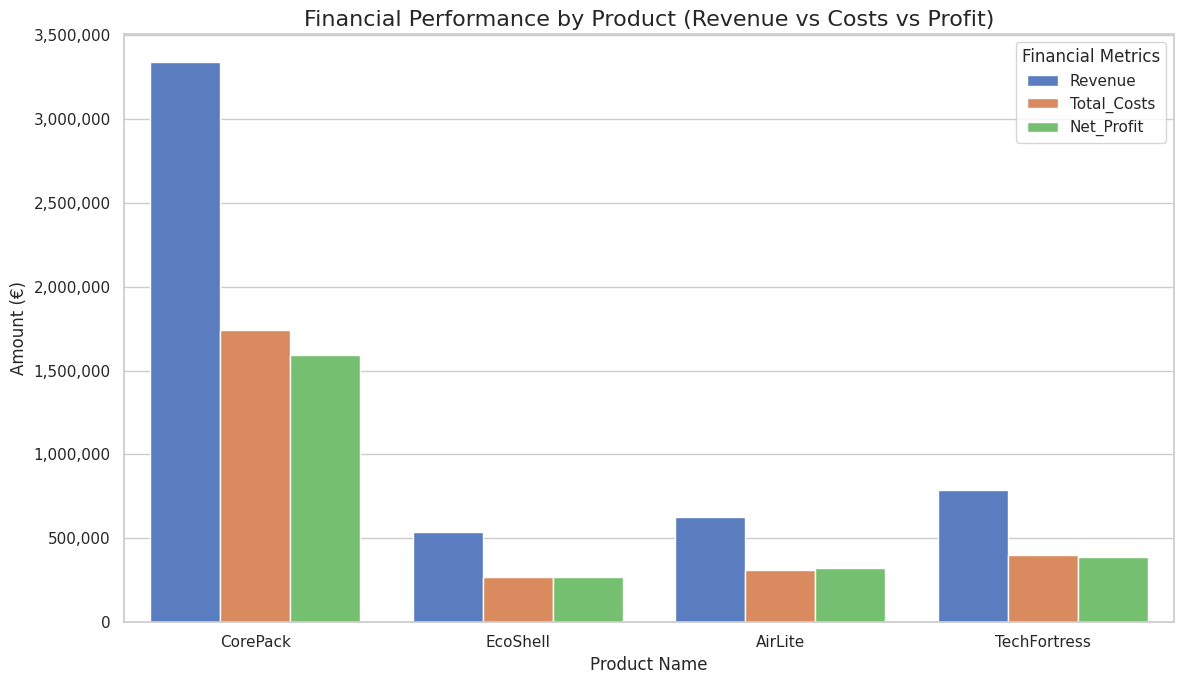

/tmp/ipykernel_12339/2539181776.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=product_fin_stats, x="product_name", y="Units_Sold", palette="viridis")


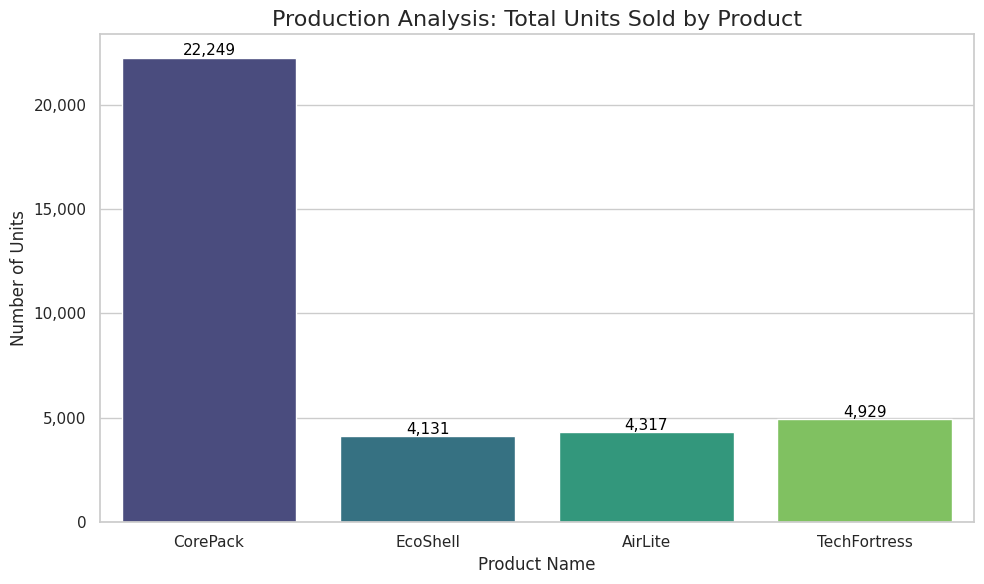

In [ ]:
# Set style
sns.set_theme(style="whitegrid")
import matplotlib.ticker as ticker

# 1. Financial Analysis Chart
# Reshape data for plotting (melt)
df_melted = product_fin_stats.melt(id_vars="product_name",
                                   value_vars=["Revenue", "Total_Costs", "Net_Profit"],
                                   var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 7))
ax1 = sns.barplot(data=df_melted, x="product_name", y="Value", hue="Metric", palette="muted")

# --- FIX: Format Y-Axis to plain decimals with commas ---
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Financial Performance by Product (Revenue vs Costs vs Profit)", fontsize=16)
plt.ylabel("Amount (€)", fontsize=12)
plt.xlabel("Product Name", fontsize=12)
plt.legend(title="Financial Metrics")
plt.tight_layout()
plt.show()

# 2. Production Analysis Chart
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=product_fin_stats, x="product_name", y="Units_Sold", palette="viridis")

# --- FIX: Format Y-Axis for production chart as well ---
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Production Analysis: Total Units Sold by Product", fontsize=16)
plt.ylabel("Number of Units", fontsize=12)
plt.xlabel("Product Name", fontsize=12)

# Add count labels on top of bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Website Conversion Funnel Analysis**

This visualization identifies where users are dropping off in the purchasing process. We track sessions from landing to product view, checkout entry, and finally successful purchase.

In [ ]:
from pyspark.sql import functions as F
import pandas as pd

print(">>> Calculating Comprehensive Funnel Stages...")

# Note: We use df_raw_pageviews because it contains the cart/shipping/billing pages
# that were filtered out of the main model dataset.

# 1. Landing Stage (Home or Landers)
landing_urls = ['/home', '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5']
count_landing = df_raw_pageviews.filter(F.col("pageview_url").isin(landing_urls)) \
                                .select("website_session_id").distinct().count()

# 2. Catalog Stage (/products)
count_catalog = df_raw_pageviews.filter(F.col("pageview_url") == "/products") \
                                .select("website_session_id").distinct().count()

# 3. Product Discovery (Specific Backpack Pages)
product_pages = ['/the-ecoshell', '/the-techfortress', '/the-corepack', '/the-airlite']
count_product = df_raw_pageviews.filter(F.col("pageview_url").isin(product_pages)) \
                                .select("website_session_id").distinct().count()

# 4. Intent Stage (/cart)
count_cart = df_raw_pageviews.filter(F.col("pageview_url") == "/cart") \
                             .select("website_session_id").distinct().count()

# 5. Checkout Stage (/shipping or /billing)
checkout_urls = ['/shipping', '/billing']
count_checkout = df_raw_pageviews.filter(F.col("pageview_url").isin(checkout_urls)) \
                                 .select("website_session_id").distinct().count()

# 6. Conversion Stage (From Orders Table)
count_purchase = Orders.count()

funnel_data = pd.DataFrame({
    'Stage': [
        '1. Landing (Home/Lander)',
        '2. Catalog (/products)',
        '3. Product Page (Backpacks)',
        '4. Add to Cart (/cart)',
        '5. Checkout (Ship/Bill)',
        '6. Purchase Made'
    ],
    'Count': [count_landing, count_catalog, count_product, count_cart, count_checkout, count_purchase]
})

# Calculate conversion rates relative to the Landing stage
funnel_data['Conversion (%)'] = (funnel_data['Count'] / count_landing * 100).round(2)

print("✅ Comprehensive funnel calculation complete.")
funnel_data

>>> Calculating Comprehensive Funnel Stages...
✅ Comprehensive funnel calculation complete.


,Stage,Count,Conversion (%)
0,1. Landing (Home/Lander),434008,100.00
1,2. Catalog (/products),237835,54.80
2,3. Product Page (Backpacks),190303,43.85
3,4. Add to Cart (/cart),85443,19.69
4,5. Checkout (Ship/Bill),58058,13.38
5,6. Purchase Made,28991,6.68


/tmp/ipykernel_12339/2482040208.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=funnel_data, x='Count', y='Stage', palette='Blues_r')


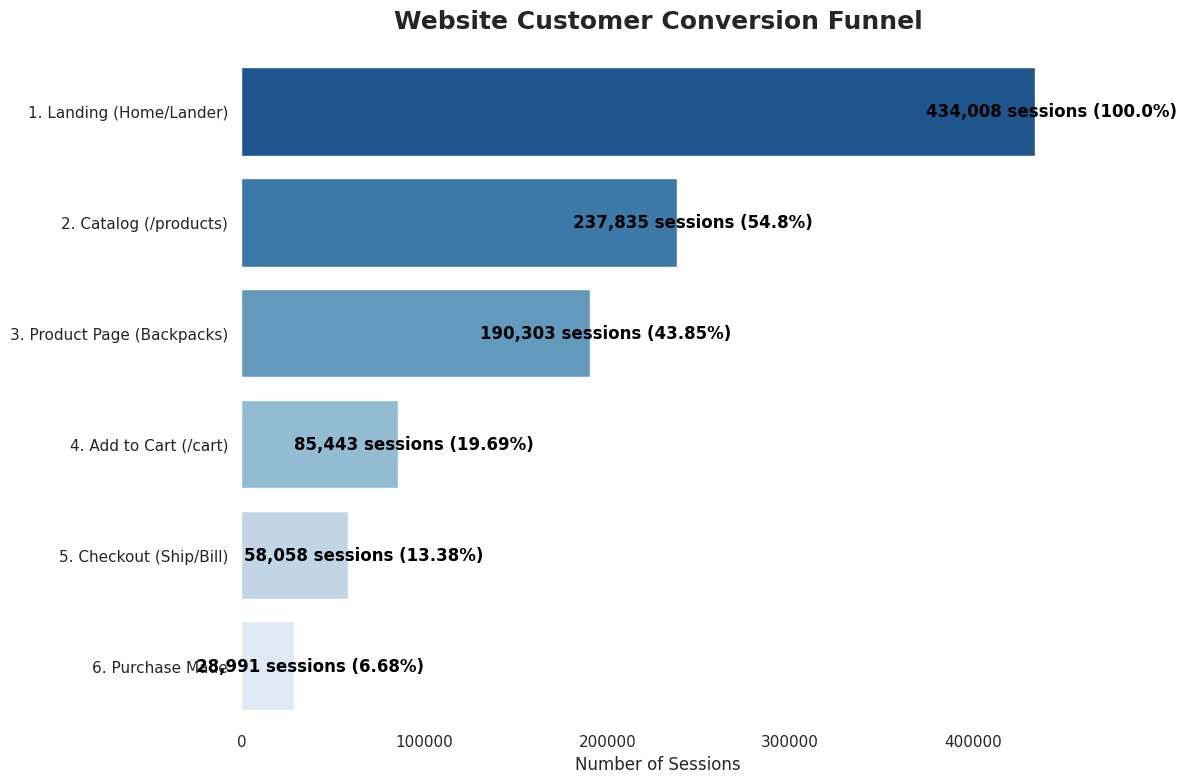

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# Create a horizontal bar chart that mimics a funnel
ax = sns.barplot(data=funnel_data, x='Count', y='Stage', palette='Blues_r')

plt.title('Website Customer Conversion Funnel', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Sessions', fontsize=12)
plt.ylabel('')

# Add text labels: Count and Conversion Rate
for i, p in enumerate(ax.patches):
    width = p.get_width()
    percent = funnel_data.iloc[i]['Conversion (%)']
    ax.text(width + (funnel_data['Count'].max() * 0.02), p.get_y() + p.get_height()/2,
            f'{int(width):,} sessions ({percent}%)',
            ha='center', va='center', fontsize=12, fontweight='bold', color='black')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# **Step 2: Create Target Variable**

In [ ]:
from pyspark.sql.functions import col, count, first, when, row_number
from pyspark.sql.window import Window

# Process Website_pageviews to extract behavioral features ---
# Sort by timestamp to determine the sequence of page views
windowSpec = Window.partitionBy("website_session_id").orderBy("created_at")

df_pageviews_clean = Website_pageviews.withColumn("rn", row_number().over(windowSpec))

# Get the Landing Page and the Total number of pageviews.
df_session_behavior = df_pageviews_clean.groupBy("website_session_id") \
    .agg(
        count("website_pageview_id").alias("total_pages_viewed"),
        first(when(col("rn") == 1, col("pageview_url")), ignorenulls=True).alias("landing_page")
    )

In [ ]:
df_session_behavior.select('landing_page').distinct().show()

+------------+
|landing_page|
+------------+
|       /home|
|   /lander-3|
|   /lander-2|
|   /lander-1|
|   /lander-4|
|   /lander-5|
+------------+



In [ ]:
df_session_behavior.select('landing_page').distinct().show()

+------------+
|landing_page|
+------------+
|       /home|
|   /lander-3|
|   /lander-2|
|   /lander-1|
|   /lander-4|
|   /lander-5|
+------------+



##Base table

In [ ]:
# Start with the Sessions table as the base
df_base = Website_sessions.alias("sess") \
    .join(df_session_behavior.alias("beh"), on="website_session_id", how="left") \
    .join(Orders.alias("ord"), on="website_session_id", how="left") \
    .join(Products.alias("prod"), on=col("ord.primary_product_id") == col("prod.product_id"), how="left")

In [ ]:
df_base.show()

+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+------------------+------------+--------+-------------------+-------+------------------+---------------+----------+---------+----------+-------------------+------------+
|website_session_id|         created_at|user_id|is_repeat_session|utm_source|utm_campaign|utm_content|device_type|        http_referer|traffic_source|total_pages_viewed|landing_page|order_id|         created_at|user_id|primary_product_id|items_purchased|price_euro|cogs_euro|product_id|         created_at|product_name|
+------------------+-------------------+-------+-----------------+----------+------------+-----------+-----------+--------------------+--------------+------------------+------------+--------+-------------------+-------+------------------+---------------+----------+---------+----------+-------------------+------------+
|                 1|2022-03-19 08:04:16|

In [ ]:
df_base.printSchema()

root
 |-- website_session_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_repeat_session: integer (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- utm_content: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- http_referer: string (nullable = true)
 |-- traffic_source: string (nullable = true)
 |-- total_pages_viewed: long (nullable = true)
 |-- landing_page: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- primary_product_id: integer (nullable = true)
 |-- items_purchased: integer (nullable = true)
 |-- price_euro: double (nullable = true)
 |-- cogs_euro: double (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- product_name: string (nullable = true)



## Create Target Variable

In [ ]:
# Create Target Variable
# Logic: If order_id exists, target is 1 (ordered); otherwise, 0 (no order)
df_final_basetable = df_base.select(
    col("sess.website_session_id"),
    col("sess.user_id"),
    col("sess.is_repeat_session"),
    col("sess.created_at").alias("session_start_time"),
    col("sess.utm_source"),
    col("sess.utm_campaign"),
    col("sess.device_type"),
    col("beh.total_pages_viewed"),
    col("beh.landing_page"), # Crucial feature for comparing lander-1 vs home performance
    # Retrieve product info (if purchased) for analysis or the bonus multi-class task
    col("prod.product_name").alias("purchased_product_name"),
    col("ord.price_euro").alias("order_value"),
    # Create the prediction label (Target)
    when(col("ord.order_id").isNotNull(), 1).otherwise(0).alias("is_ordered"),
)

In [ ]:
df_final_basetable.show()

+------------------+-------+-----------------+-------------------+----------+------------+-----------+------------------+------------+----------------------+-----------+----------+
|website_session_id|user_id|is_repeat_session| session_start_time|utm_source|utm_campaign|device_type|total_pages_viewed|landing_page|purchased_product_name|order_value|is_ordered|
+------------------+-------+-----------------+-------------------+----------+------------+-----------+------------------+------------+----------------------+-----------+----------+
|                 1|      1|                0|2022-03-19 08:04:16|   gsearch|    nonbrand|     mobile|                 1|       /home|                  NULL|       NULL|         0|
|                 3|      3|                0|2022-03-19 08:26:55|   gsearch|    nonbrand|    desktop|                 1|       /home|                  NULL|       NULL|         0|
|                 5|      5|                0|2022-03-19 09:00:55|   gsearch|    nonbrand|     

# **Step 3: Feature Engeneering**

### Feature - `hour`

For each session, we extract the hour of the day when the user initiated their visit. This represents the specific time block (0–23) during which the interaction occurred.

**Logic**  
1. Identify the timestamp of the first event (e.g., page view) in the current session.
1. Extract the hour component from the datetime object (ranging from 0 for midnight to 23 for 11:00 PM).
1. Assign the resulting integer to the session record.


In [ ]:
from pyspark.sql import functions as F

def add_hour_feature(df, input_col="session_start_time", output_col="hour"):
    print(f"--- Generating feature '{output_col}' from '{input_col}' ---")
    # Extract the hour directly
    return df.withColumn(output_col, F.hour(F.col(input_col)))

In [ ]:
df_final_basetable = add_hour_feature(df_final_basetable)

--- Generating feature 'hour' from 'session_start_time' ---


### Feature - `day_of_week`

For each session, we determine the specific day of the week (e.g., Monday through Sunday) on which the user activity occurred.

**Logic**  
1. Extract the date from the session's start timestamp.
1. Convert the date into an integer representation (typically 0 for Monday through 6 for Sunday).
1. Assign the resulting integer to the session record.


In [ ]:
from pyspark.sql import functions as F

def add_day_of_week_feature(df, input_col="session_start_time", output_col="day_of_week"):
    print(f"--- Generating feature '{output_col}' from '{input_col}' ---")
    # Extract day of week (returns integer: 1=Sun, 2=Mon... 7=Sat)
    return df.withColumn(output_col, F.dayofweek(F.col(input_col)))

In [ ]:
df_final_basetable = add_day_of_week_feature(df_final_basetable)

--- Generating feature 'day_of_week' from 'session_start_time' ---


### Feature - `month`

For each session, we extract the month of the year (1–12) to identify broader seasonal trends.

**Logic**  
1. Identify the month from the session's initial event date.
1. Assign an integer value between 1 (January) and 12 (December).
1. Assign the resulting integer to the feature set.


In [ ]:
from pyspark.sql import functions as F

def add_month_feature(df, input_col="session_start_time", output_col="month"):
    print(f"--- Generating feature '{output_col}' from '{input_col}' ---")
    # Extract month (returns integer: 1 to 12)
    return df.withColumn(output_col, F.month(F.col(input_col)))

In [ ]:
df_final_basetable = add_month_feature(df_final_basetable)

--- Generating feature 'month' from 'session_start_time' ---


### Feature - `is_night`

For each session, we flag whether the interaction took place during late-night or early-morning hours (typically between 11:00 PM and 5:00 AM).

**Logic**  
1. Reference the hour feature previously extracted from the session timestamp.
1. Define a "night" window (e.g., where hour >= 23 or hour < 5).
1. Assign a binary flag: 1 if the session start time falls within this window, and 0 otherwise.


In [ ]:
from pyspark.sql import functions as F

def add_is_night_feature(df, input_col="session_start_time", output_col="is_night"):
    print(f"--- Generating feature '{output_col}' from '{input_col}' ---")
    # Extract hour first to check the condition
    # Logic: If hour <= 6 (Early morning) OR hour >= 23 (Late night) -> 1, else 0
    return df.withColumn(
        output_col,
        F.when((F.hour(F.col(input_col)) <= 6) | (F.hour(F.col(input_col)) >= 23), 1)
         .otherwise(0)
    )

In [ ]:
df_final_basetable = add_is_night_feature(df_final_basetable)

--- Generating feature 'is_night' from 'session_start_time' ---


### Feature - `is_holiday`

For each session, we determine whether the interaction occurred on a public holiday based on the user's geographical location and the session date.

**Logic**  
1. Identify the date of the session from the initial event timestamp.

1. Cross-reference the date with a standardized calendar of public holidays (national or regional, depending on the data scope).

1. Assign a boolean value: 1 if the date falls on a recognized holiday, and 0 otherwise.

In [ ]:
pip install holidays

In [ ]:
import holidays
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

def add_is_holiday_feature(df, input_col="session_start_time", output_col="is_holiday", country_code="FR"):
    print(f"--- Generating feature '{output_col}' (Country: {country_code}) ---")

    # 1. Define the Python function to check holidays
    def check_holiday_logic(date_val):
        if date_val is None:
            return 0
        # Check if the date exists in the country's holiday calendar
        # Corrected: Use holidays.country_holidays instead of holidays.Country
        country_holidays = holidays.country_holidays(country_code)
        return 1 if date_val in country_holidays else 0

    # 2. Register as Spark UDF
    holiday_udf = F.udf(check_holiday_logic, IntegerType())

    # 3. Apply UDF (Convert timestamp to date first)
    return df.withColumn(output_col, holiday_udf(F.to_date(F.col(input_col))))

In [ ]:
df_final_basetable = add_is_holiday_feature(df_final_basetable, country_code="FR")

--- Generating feature 'is_holiday' (Country: FR) ---


### Feature - `is_weekend`

For each session, we identify if the visit took place on a Saturday or Sunday.

**Logic**  
1. Extract the day of the week from the session's start date.
1. Check if the day corresponds to Saturday or Sunday.
1. Assign a binary flag: 1 for weekend sessions and 0 for weekday sessions (Monday through Friday).

In [ ]:
from pyspark.sql import functions as F

def add_is_weekend_feature(df, input_col="session_start_time", output_col="is_weekend"):
    print(f"--- Generating feature '{output_col}' from '{input_col}' ---")

    # PySpark dayofweek returns: 1=Sunday, 2=Monday, ..., 7=Saturday
    # So we check if the value is in [1, 7]
    return df.withColumn(
        output_col,
        F.when(F.dayofweek(F.col(input_col)).isin([1, 7]), 1)
         .otherwise(0)
    )

In [ ]:
df_final_basetable = add_is_weekend_feature(df_final_basetable)

--- Generating feature 'is_weekend' from 'session_start_time' ---


### Feature - `duration_seconds`

For each session, we calculate the total elapsed time in seconds from the beginning of the user's visit to their final recorded interaction.

**Logic**  
1. Identify the min(timestamp) and max(timestamp) for all events within a unique session.

2. Calculate the difference between the maximum and minimum timestamps in seconds.

3. For sessions consisting of only a single page view, assign a duration of 0.

4. If a session exceeds a predefined "timeout" (e.g., 1800 seconds of inactivity), ensure the duration is capped or split to prevent data skew from "idle" tabs.


In [ ]:
from pyspark.sql import functions as F

def add_duration_seconds_feature(df_basetable, df_pageviews, session_id_col="website_session_id", time_col="created_at"):

    # 1. Handle the default pageviews table selection
    if df_pageviews is None:
        # Attempts to use the global variable 'Website_pageviews'
        try:
            df_pageviews = Website_pageviews
            print("ℹ️ Using the default global 'Website_pageviews' table.")
        except NameError:
            print("❌ Error: Global variable 'Website_pageviews' not found. Please provide the dataframe explicitly.")
            return df_basetable
    else:
        print("ℹ️ Using the provided 'df_pageviews' table.")

    print("--- Computing feature 'duration_seconds' ---")

    # 2. Compute Duration (Max timestamp - Min timestamp)
    # We group by session ID to find the start and end of the session
    df_duration = df_pageviews.groupBy(session_id_col).agg(
        (F.unix_timestamp(F.max(time_col)) - F.unix_timestamp(F.min(time_col))).alias("duration_seconds")
    )

    # 3. Join with Base Table
    # Use Left Join to ensure no sessions from the base table are lost
    df_joined = df_basetable.join(df_duration, on=session_id_col, how="left")

    # 4. Handle Nulls
    # Sessions with only 1 pageview (or missing logs) result in Null duration.
    # We fill these with 0.
    return df_joined.fillna(0, subset=["duration_seconds"])

In [ ]:
df_final_basetable = add_duration_seconds_feature(df_final_basetable, Website_pageviews)

ℹ️ Using the provided 'df_pageviews' table.
--- Computing feature 'duration_seconds' ---


### Feature - `avg_time_per_page`

The average duration a user spends on a single page.

**Logic**  
1. Low (< 10s): Indicates low intent, "window shopping," or bot activity.
1. Optimal (30s – 90s): Indicates high intent (reading specs, comparing prices) $\rightarrow$ Highest conversion probability.
1. High (> 300s): Indicates the user is idle or distracted (tabs left open).


In [ ]:
from pyspark.sql import functions as F

def add_avg_time_per_page_feature(df, duration_col="duration_seconds", pages_col="total_pages_viewed", output_col="avg_time_per_page"):

    print(f"--- Computing feature '{output_col}' ---")

    # 1. Calculate Ratio (handling division by zero)
    # We add 0.01 to the denominator so if pages=0, it doesn't crash.
    df_calc = df.withColumn(
        output_col,
        F.col(duration_col) / (F.col(pages_col) + 0.01)
    )

    # 2. Handle Outliers (Clipping)
    # If value > 1800, force it to 1800. Otherwise, keep calculated value.
    return df_calc.withColumn(
        output_col,
        F.when(F.col(output_col) > 1800, 1800)
         .otherwise(F.col(output_col))
    )

In [ ]:
df_final_basetable = add_avg_time_per_page_feature(df_final_basetable)

--- Computing feature 'avg_time_per_page' ---


### Feature - `pages_per_minute`

For each session, we compute the average frequency of page transitions per minute of activity.

**Logic**  
1. Retrieve the total number of pages viewed during the session.
1. Retrieve the duration_seconds and convert it to1.  minutes by dividing by 60.Divide the total page count by the duration in minutes ($pages / (duration\_seconds / 60)$).
1. If the duration is 0 (single-page session), assign a default value of 0 or 1 to avoid division by zero errors.
1. If the resulting value is an extreme outlier, cap the value at a reasonable threshold (e.g., 20 pages per minute).


In [ ]:
from pyspark.sql import functions as F

def add_pages_per_minute_feature(df, duration_col="duration_seconds", pages_col="total_pages_viewed", output_col="pages_per_minute"):
    print(f"--- Computing feature '{output_col}' ---")

    # 1. Calculate the raw ratio
    # We use F.when() to handle the case where duration is 0
    df_calc = df.withColumn(
        output_col,
        F.when(F.col(duration_col) == 0, 0.0) # Avoid Division by Zero
         .otherwise(F.col(pages_col) / (F.col(duration_col) / 60))
    )

    # 2. Handle Outliers (Clipping at 20)
    return df_calc.withColumn(
        output_col,
        F.when(F.col(output_col) > 20, 20.0)
         .otherwise(F.col(output_col))
    )

In [ ]:
df_final_basetable = add_pages_per_minute_feature(df_final_basetable)

--- Computing feature 'pages_per_minute' ---


### Feature - `reading_depth`

For each session, we compute the logarithmic transformation of the average time spent per page. This feature aims to measure the intensity of user engagement while normalizing the data distribution.

**Logic**  
1. Retrieve the duration_seconds (total time) and total_pages_viewed (total pages) for the session.
1. Calculate the raw average time per page: duration_seconds / total_pages_viewed.
1. Add 1 to the result to handle cases where duration might be 0 and to ensure mathematical stability for the logarithm (Log(1) = 0).
1. Apply the natural logarithm (log1p) to the value: $\ln(1 + \frac{duration\_seconds}{total\_pages\_viewed})$.


In [ ]:
from pyspark.sql import functions as F

def add_reading_depth_feature(df, duration_col="duration_seconds", pages_col="total_pages_viewed", output_col="reading_depth"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.log1p(F.col(duration_col) / (F.col(pages_col) + 1))
    )

In [ ]:
df_final_basetable = add_reading_depth_feature(df_final_basetable)

--- Computing feature 'reading_depth' ---


### Feature - `user_velocity_type`

For each session, we categorize the user's interaction speed based on their navigation patterns. This is a qualitative classification derived from their pages_per_minute and duration_seconds.

**Logic**  
1. Retrieve the calculated pages_per_minute for the session.
2. Define velocity thresholds based on the distribution of all sessions (e.g., using quartiles):
- Scanner: Top 25% of pages per minute (high speed).
- Browser: Middle 50% of pages per minute (average speed).
- Focused: Bottom 25% of pages per minute (slow, deliberate speed).
3. Assign the corresponding categorical label to the session.

In [ ]:
from pyspark.sql import functions as F

def add_user_velocity_type_feature(df, duration_col="duration_seconds", pages_col="total_pages_viewed", output_col="user_velocity_type"):
    print(f"--- Computing feature '{output_col}' ---")

    # 1. Define the calculation logic (Ratio)
    # We calculate it inside the condition to be self-contained
    avg_time = F.col(duration_col) / (F.col(pages_col) + 0.01)

    # 2. Apply Conditions (Case When)
    return df.withColumn(
        output_col,
        F.when(avg_time < 10, "Fast_Skimmer")
         .when(avg_time > 45, "Serious_Reader")
         .otherwise("Normal_Browser")
    )

In [ ]:
df_final_basetable = add_user_velocity_type_feature(df_final_basetable)

--- Computing feature 'user_velocity_type' ---


### Feature - `commitment_score`

For each session, we calculate a composite interaction score that multiplies the breadth of exploration (total pages) by the depth of engagement (log-transformed duration). This feature aims to isolate "High-Value" users who are both exploring widely and spending significant time on the site. It effectively penalizes "Scanners" (high pages, near-zero time) and "Idlers" (one page, huge time), rewarding only those who demonstrate active and sustained interest.

**Logic**  
1. Retrieve the total_pages_viewed and duration_seconds for the session.
2. Apply a natural logarithm to the duration: $\ln(1 + duration\_seconds)$. This compresses the time scale to prevent time outliers from dominating the score.
3. Multiply the total_pages_viewed by this log-transformed duration ($Pages \times \ln(1 + Duration)$).

In [ ]:
from pyspark.sql import functions as F

def add_commitment_score_feature(df_basetable, df_pageviews=None, session_id_col="website_session_id", page_url_col="pageview_url"):
    # 1. Handle default pageviews table selection
    if df_pageviews is None:
        try:
            df_pageviews = Website_pageviews
            print("ℹ️ Using the default global 'Website_pageviews' table.")
        except NameError:
            print("❌ Error: Global variable 'Website_pageviews' not found. Please provide it explicitly.")
            return df_basetable

    print("--- Computing feature 'commitment_score' (Updated with Product List) ---")

    # 2. Define the list of specific product pages based on your data
    product_pages = [
        '/products',
        '/the-ecoshell',
        '/the-techfortress',
        '/the-corepack',
        '/the-airlite'
    ]

    # 3. Apply Scoring Logic
    df_scored_hits = df_pageviews.withColumn(
        "page_score",
        F.when(F.col(page_url_col) == "/billing", 10)       # Payment Step
         .when(F.col(page_url_col) == "/shipping", 7)       # Shipping Step
         .when(F.col(page_url_col) == "/cart", 5)           # Cart Step
         .when(F.col(page_url_col).isin(product_pages), 3)  # Product Interest
         .otherwise(1)                                      # General Browsing (Home/Landers)
    )

    # 4. Aggregate Score per Session (Summing points)
    df_session_score = df_scored_hits.groupBy(session_id_col).agg(
        F.sum("page_score").alias("commitment_score")
    )

    # 5. Join back to Base Table
    df_joined = df_basetable.join(df_session_score, on=session_id_col, how="left")

    # 6. Handle Nulls (Sessions with no matching pageviews get 0 score)
    return df_joined.fillna(0, subset=["commitment_score"])

In [ ]:
df_final_basetable = add_commitment_score_feature(df_final_basetable)

ℹ️ Using the default global 'Website_pageviews' table.
--- Computing feature 'commitment_score' (Updated with Product List) ---


### Feature - `past_order_count`

For each session, we count the total number of distinct purchase orders successfully completed by the user strictly prior to the current session's start time.

**Logic**  
1. Group data by user_id.
2. Filter for records where is_ordered = 1.
3. Count the number of orders where created_at < current_session_created_at.
4. If no history exists, assign a value of 0.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_past_order_count_feature(df, user_col="user_id", time_col="session_start_time", order_col="is_ordered", output_col="past_order_count"):
    print(f"--- Computing feature '{output_col}' (History Feature) ---")

    # 1. Define the Window
    # We look at all previous rows (UnboundedPreceding) up to the ONE BEFORE current (-1)
    # This prevents Data Leakage (we don't count the current session's potential order)
    window_spec = Window.partitionBy(user_col)\
                        .orderBy(time_col)\
                        .rowsBetween(Window.unboundedPreceding, -1)

    # 2. Calculate Cumulative Sum
    df_calc = df.withColumn(
        output_col,
        F.sum(F.col(order_col)).over(window_spec)
    )

    # 3. Handle Nulls (First session for every user will be Null -> set to 0)
    return df_calc.fillna(0, subset=[output_col])

In [ ]:
df_final_basetable = add_past_order_count_feature(df_final_basetable)

--- Computing feature 'past_order_count' (History Feature) ---


### Feature - `past_total_spent`

For each session, we calculate the cumulative monetary value (in USD/EUR) of all confirmed purchases made by the user prior to the current visit.

**Logic**  
1. Group data by user_id.
2. Sum the price_usd (or order_value) column for all transactions where created_at < current_session_created_at and is_ordered = 1.


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_past_total_spent_feature(df, user_col="user_id", time_col="session_start_time", amount_col="order_value", output_col="past_total_spent"):
    print(f"--- Computing feature '{output_col}' (History Feature) ---")

    # 1. Define the Window (Look back at all previous rows, excluding current)
    window_spec = Window.partitionBy(user_col)\
                        .orderBy(time_col)\
                        .rowsBetween(Window.unboundedPreceding, -1)

    # 2. Calculate Cumulative Sum
    # Note: We assume 'price_usd' is 0 or Null for non-orders.
    # If it is Null, Spark handles it gracefully in Sum (treats as 0).
    df_calc = df.withColumn(
        output_col,
        F.sum(F.col(amount_col)).over(window_spec)
    )

    # 3. Handle Nulls (First session = 0 spent)
    return df_calc.fillna(0, subset=[output_col])

In [ ]:
df_final_basetable = add_past_total_spent_feature(df_final_basetable)

--- Computing feature 'past_total_spent' (History Feature) ---


### Feature - `past_session_count`

For each session, we tally the total number of browsing sessions initiated by the user prior to the current visit.

**Logic**  
1. Group data by user_id.
2. Count the number of unique website_session_ids where created_at < current_session_created_at.


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_past_session_count_feature(df, user_col="user_id", time_col="session_start_time", output_col="past_session_count"):
    print(f"--- Computing feature '{output_col}' (History Feature) ---")

    # 1. Define the Window
    window_spec = Window.partitionBy(user_col).orderBy(time_col)

    # 2. Calculate Rank (1, 2, 3...) and subtract 1
    # Row 1 -> 0 past sessions
    # Row 2 -> 1 past session
    df_calc = df.withColumn(
        output_col,
        F.row_number().over(window_spec) - 1
    )

    return df_calc

In [ ]:
df_final_basetable = add_past_session_count_feature(df_final_basetable)

--- Computing feature 'past_session_count' (History Feature) ---


### Feature - `is_paid_traffic`

A binary flag indicating whether the session originated from a paid advertising channel versus an organic or direct source.

**Logic**  
1. Inspect the utm_campaign and utm_source columns.
2. If utm_campaign is explicitly populated (e.g., "nonbrand", "brand", "pilot") OR utm_source indicates an ad platform (e.g., "gsearch", "socialbook"), assign 1.


In [ ]:
from pyspark.sql import functions as F

def add_is_paid_traffic_feature(df, campaign_col="utm_campaign", output_col="is_paid_traffic"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(campaign_col).isNotNull(), 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_is_paid_traffic_feature(df_final_basetable)

--- Computing feature 'is_paid_traffic' ---


### Feature - `is_brand_search`

A binary flag identifying sessions where the user searched specifically for the company's brand name to find the site.

**Logic**  
1. Check the utm_campaign column.
2. If the value contains the string "brand" (and strictly does NOT equal "nonbrand"), assign 1.


In [ ]:
def add_brand_search_feature(df, campaign_col="utm_campaign", output_col="is_brand_search"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(campaign_col) == "brand", 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_brand_search_feature(df_final_basetable)

--- Computing feature 'is_brand_search' ---


### Feature - `is_nonbrand_search`

A binary flag identifying sessions where the user arrived via a generic keyword search (e.g., "teddy bear", "gift for girlfriend") rather than a specific brand name.

**Logic**  
1. Check the utm_campaign column.
2. If the value explicitly equals "nonbrand" (or contains "generic" keywords depending on specific campaign naming conventions), assign 1.


In [ ]:
def add_nonbrand_search_feature(df, campaign_col="utm_campaign", output_col="is_nonbrand_search"):
    print(f"--- Computing feature '{output_col}' ---")

    target_values = ["nonbrand", "desktop_targeted"]

    return df.withColumn(
        output_col,
        F.when(F.col(campaign_col).isin(target_values), 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_nonbrand_search_feature(df_final_basetable)

--- Computing feature 'is_nonbrand_search' ---


### Feature - `source_category`

For each session, we map the granular traffic source into a high-level macro category (Search Engine, Social Media, or Direct).

**Logic**  
1. Inspect the utm_source column.
2. Apply a mapping function:
- If value is in ["gsearch", "bsearch"], map to "Search_Engine".
- If value is ["socialbook", "facebook", "twitter"], map to "Social_Media".
- If value is NULL or "direct", map to "Direct/Organic".


In [ ]:
from pyspark.sql import functions as F

def add_source_category_feature(df, source_col="utm_source", output_col="source_category"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(source_col).isin(["gsearch", "bsearch"]), "Search")
         .when(F.col(source_col) == "social", "Social")
         .otherwise("Direct") # Handles NULL and any unidentified sources
    )

In [ ]:
df_final_basetable = add_source_category_feature(df_final_basetable)

--- Computing feature 'source_category' ---


### Feature - `is_social_traffic`

A binary flag indicating whether the session originated from a social media platform (e.g., Socialbook, Facebook).

**Logic**  
1. Inspect the utm_source column.
2. If the value contains keywords like "social", "facebook", "instagram", or "twitter", assign 1.
3. Otherwise, assign 0.


In [ ]:
from pyspark.sql import functions as F

def add_is_social_traffic_feature(df, source_col="utm_source", output_col="is_social_traffic"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(source_col) == "social", 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_is_social_traffic_feature(df_final_basetable)

--- Computing feature 'is_social_traffic' ---


### Feature - `is_pilot_campaign`

A binary flag identifying sessions that belong to experimental or "beta" marketing campaigns.

**Logic**  
1. Inspect the utm_campaign column.
2. If the value contains keywords such as "pilot", "test", "experiment", or "launch_trial", assign 1.
3. Otherwise, assign 0.


In [ ]:
def add_pilot_campaign_feature(df, campaign_col="utm_campaign", output_col="is_pilot_campaign"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(campaign_col) == "pilot", 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_pilot_campaign_feature(df_final_basetable)

--- Computing feature 'is_pilot_campaign' ---


### Feature - `channel_efficiency_score`

For each session, we assign a numerical score representing the historical conversion rate of its specific traffic source and campaign combination.

**Logic**  
1. Group historical data by utm_source and utm_campaign. Calculate the mean of is_ordered (Conversion Rate) for each group.
2. Map this historical rate to the current session based on its source/campaign.
3. If a session comes from a new or unknown campaign with no history, fill the score with the global average conversion rate to prevent null errors.

In [ ]:
from pyspark.sql import functions as F

def add_channel_efficiency_score_feature(df, source_col="utm_source", campaign_col="utm_campaign", output_col="channel_efficiency_score"):
    print(f"--- Computing feature '{output_col}' ---")

    # Define campaigns that fall under "Generic Search"
    generic_search = ["nonbrand", "desktop_targeted"]

    return df.withColumn(
        output_col,
        # 1. Top Priority: Explicit Brand Search
        F.when(F.col(campaign_col) == "brand", 10)

        # 2. Direct/Organic Traffic (Usually indicates high loyalty)
        # Note: In this dataset, Organic/Direct sources appear as NULL.
         .when(F.col(source_col).isNull(), 8)

        # 3. Generic Search (High volume, but user is still comparing options)
         .when(F.col(campaign_col).isin(generic_search), 5)

        # 4. Social Media (Passive discovery, usually lower conversion rates)
         .when(F.col(source_col) == "social", 2)

        # 5. Fallback for others (Pilot campaigns, experiments, etc.)
         .otherwise(4)
    )

In [ ]:
df_final_basetable = add_channel_efficiency_score_feature(df_final_basetable)

--- Computing feature 'channel_efficiency_score' ---


### Feature - `target_device_group`

For each session, we categorize the hardware platform used by the visitor into distinct groups, such as Mobile, Desktop, or Tablet.

**Logic**  
1. Inspect the utm_campaign column to identify campaigns with explicit device targeting keywords.
2. If the campaign is 'desktop_targeted', assign the label 'Desktop_Only'.
3. For all other campaigns (including 'brand', 'nonbrand', 'pilot', and NULLs), assign the label 'All_Devices', assuming a standard distribution across both Mobile and Desktop traffic.

In [ ]:
from pyspark.sql import functions as F

def add_target_device_group_feature(df, campaign_col="utm_campaign", output_col="target_device_group"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(F.col(campaign_col) == "desktop_targeted", "Desktop_Only") \
         .otherwise("All_Devices")
    )

In [ ]:
df_final_basetable = add_target_device_group_feature(df_final_basetable)

--- Computing feature 'target_device_group' ---


### Feature - `is_impulse_buyer`

For each user, we create a binary flag indicating if they have a history of making quick purchase decisions (Impulse Buying) in their previous sessions.

**Logic**  
1. Analyze the user's successful orders (is_ordered = 1) prior to the current session.
2. Calculate the decision_time_seconds (Time from Session Start to Order) for those past orders.
3. If the user has at least one past order with a decision time of < 10 minutes (600 seconds), assign 1 (True). Otherwise (or if the user is new/no past orders), assign 0 (False).

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_is_impulse_buyer_feature(df, user_col="user_id", time_col="session_start_time", order_col="is_ordered", duration_col="duration_seconds"):
    print("--- Computing feature 'is_impulse_buyer' (History Feature) ---")

    # 1. Define Window: Look at all previous rows up to the one before current (-1)
    # This prevents the current session's duration from influencing the feature.
    window_spec = Window.partitionBy(user_col)\
                        .orderBy(time_col)\
                        .rowsBetween(Window.unboundedPreceding, -1)

    # 2. Logic: Find the MINIMUM duration of any PAST successful order.
    # F.when(order=1, duration) filters for only purchase sessions.
    min_past_decision_time = F.min(
        F.when(F.col(order_col) == 1, F.col(duration_col))
    ).over(window_spec)

    # 3. Thresholding: If their fastest past buy was < 10 mins (600s), they are an impulse buyer.
    return df.withColumn(
        "is_impulse_buyer",
        F.when(min_past_decision_time < 600, 1).otherwise(0)
    )

In [ ]:
df_final_basetable = add_is_impulse_buyer_feature(df_final_basetable)

--- Computing feature 'is_impulse_buyer' (History Feature) ---


### Feature - `pageviews_per_session`

For each session, we compute the number of pages viewed during that session.
This feature captures the depth of engagement within a single visit, indicating how extensively a user interacted with the website before exiting.

**Logic**

1. Group the pageview data by `website_session_id`.
2. Count the total number of pageview events associated with each session.
3. Assign this count as the pageviews per session value for the corresponding session record.

In [ ]:
from pyspark.sql import functions as F

def add_pageviews_per_session_feature(df_pageviews, df_base, output_col="pageviews_per_session"):
    # 1. Group & Count from Pageviews Table
    session_counts = (
        df_pageviews
        .groupBy("website_session_id")
        .count()
        .withColumnRenamed("count", output_col)
    )

    # 2. Join back to Base Table
    # We use 'left' join to keep all sessions from df_base.
    # fillna(1): If a session exists in df_base, it must have at least 1 pageview (the entry page).
    return df_base.join(session_counts, "website_session_id", "left").fillna({output_col: 1})

# --- Usage Example ---
# df_basetable = add_pageviews_per_session_feature(df_pageviews, df_basetable)


In [ ]:
df_final_basetable = add_pageviews_per_session_feature(
    Website_pageviews,
    df_final_basetable
)

### Feature - `session_depth_ratio`

For each session, we compute the ratio between the number of pages viewed in the current session and the user’s average pages per session. This feature captures whether the current session is shallower or deeper than the user’s normal behavior.

**Logic**

1. Use the previously computed `avg_pages_per_session` as the user’s baseline engagement.
2. For each session, divide `total_pages_viewed` by `avg_pages_per_session`.
3. If `avg_pages_per_session` is zero or missing, assign the ratio as 0 to avoid invalid calculations.
4. Store the resulting value as `session_depth_ratio`.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_session_depth_ratio_feature(df, user_col="user_id", pages_col="total_pages_viewed", output_col="session_depth_ratio"):
    print(f"--- Computing feature '{output_col}' ---")

    # 1. Define Window partitioned by User
    # This captures the user's behavior across all their sessions available in the df.
    user_window = Window.partitionBy(user_col)

    # 2. Calculate the Baseline (User's Average Page Views)
    # We create a temporary column 'user_avg_pages'
    df = df.withColumn("user_avg_pages", F.avg(F.col(pages_col)).over(user_window))

    # 3. Calculate Ratio & Handle Edge Cases (Division by Zero/Null)
    df_result = df.withColumn(
        output_col,
        F.when(
            (F.col("user_avg_pages").isNotNull()) & (F.col("user_avg_pages") > 0),
            F.col(pages_col) / F.col("user_avg_pages")
        ).otherwise(0) # Assign 0 if average is invalid
    )

    return df_result

In [ ]:
df_final_basetable = add_session_depth_ratio_feature(df_final_basetable)

--- Computing feature 'session_depth_ratio' ---


### Feature - `flag_2_pages_same_category`

For each session, we create a binary indicator that captures whether the first two pages viewed belong to the same page category (e.g., product, checkout, other). This feature represents early session focus, indicating whether users start their visit with a clear intent or exploratory behavior.

**Logic**

1. Sort pageview events within each `website_session_id` by their timestamp.
2. Identify the first two pageviews of the session.
3. Map each pageview URL to a page category (e.g., product, checkout, other).
4. Count the number of distinct page categories among the first two pageviews:
    * If the count equals 1, assign `flag_2_pages_same_category` = 1.
    * Otherwise, assign `flag_2_pages_same_category` = 0.
5. Store the resulting flag at the session level.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window

def add_first_2_pages_same_category(df_pageviews, df_base, output_col="first_2_pages_same_category"):
    print(f"--- Computing feature '{output_col}' (Fixed Mapping & Logic) ---")

    # 1. DEFINE CATEGORIES (Based on actual data)
    product_pages = [
        '/products',          # General category page
        '/the-ecoshell',      # Specific product 1
        '/the-techfortress',  # Specific product 2
        '/the-corepack',      # Specific product 3
        '/the-airlite'        # Specific product 4
    ]

    checkout_pages = ['/cart', '/shipping', '/billing']

    # (Remaining pages like /home, /lander-x will automatically fall into "other")

    # 2. Filter for the first 2 pageviews
    w = Window.partitionBy("website_session_id").orderBy(F.col("created_at"))

    pv_categorized = (
        df_pageviews
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") <= 2) # Keep only the first 2 pages
        .withColumn(
            "page_category",
            F.when(F.col("pageview_url").isin(product_pages), "product")
             .when(F.col("pageview_url").isin(checkout_pages), "checkout")
             .otherwise("other") # Includes home, landers, etc.
        )
    )

    # 3. Compute the Flag
    # Logic: Must have exactly 2 pages (count=2) AND only 1 distinct category type (distinct=1)
    flag_df = (
        pv_categorized
        .groupBy("website_session_id")
        .agg(
            F.count("*").alias("page_count_check"),
            F.countDistinct("page_category").alias("distinct_cats")
        )
        .withColumn(
            output_col,
            F.when(
                (F.col("page_count_check") == 2) & (F.col("distinct_cats") == 1),
                1
            ).otherwise(0)
        )
        .select("website_session_id", output_col)
    )

    # 4. Join back to the Base Table
    # fillna(0) ensures sessions with fewer than 2 pages get a 0
    return df_base.join(flag_df, "website_session_id", "left").fillna({output_col: 0})

In [ ]:
df_final_basetable = add_first_2_pages_same_category(Website_pageviews, df_final_basetable)

--- Computing feature 'first_2_pages_same_category' (Fixed Mapping & Logic) ---


### Feature - `navigation_entropy`

For each session, we calculate the **Shannon Entropy** of the user's navigation path. This feature measures the **complexity and diversity** of the pages viewed. It quantifies whether a user's attention is focused on a repetitive set of pages (Low Entropy) or distributed across many different pages (High Entropy).

**Logic**
1.  **Count Page Frequency:** Group the raw pageview logs by `website_session_id` and `pageview_url` to count how many times each specific URL was visited within the session ($count_i$).
2.  **Calculate Total Views:** Sum the total number of pageviews ($N$) for the session.
3.  **Compute Probability ($p$):** For each unique URL in the session, calculate its relative frequency:
    $$p_i = \frac{count_i}{N}$$
4.  **Calculate Entropy:** Apply the Shannon Entropy formula for the session:
    $$H = - \sum (p_i \times \log_2(p_i))$$
5.  **Handle Missing Values:** If a session has no pageviews or the calculation results in null, assign 0.


In [ ]:
def add_navigation_entropy(df_pageviews, df_base, output_col="navigation_entropy"):
    print(f"--- Computing feature '{output_col}' ---")
    counts = (
        df_pageviews
        .groupBy("website_session_id", "pageview_url")
        .count()
    )

    total = counts.groupBy("website_session_id") \
        .agg(F.sum("count").alias("total"))

    probs = counts.join(total, "website_session_id") \
        .withColumn("p", F.col("count") / F.col("total"))

    entropy = probs.groupBy("website_session_id") \
        .agg(
            (-F.sum(F.col("p") * F.log2(F.col("p")))).alias("navigation_entropy")
        )

    return (
        df_base
        .join(entropy, "website_session_id", "left")
        .fillna({"navigation_entropy": 0})
    )

In [ ]:
df_final_basetable = add_navigation_entropy(Website_pageviews, df_final_basetable)

--- Computing feature 'navigation_entropy' ---


### Feature - `page_revisit_count`

For each website session, this feature measures how many times a user revisits the same page during a single visit. It captures whether the user navigates back and forth instead of moving forward smoothly.

**Logic**

1. Identify all page views belonging to the same `website_session_id`.
2. Count how many times each individual page (`pageview_url`) is visited within that session.
3. If a page is visited more than once:
    * Subtract 1 to exclude the first (initial) visit.
    * Sum all such revisits across pages within the session.
4. If no page is revisited, assign the value 0.

In [ ]:
#page_revisit_count
def add_page_revisit_count(df_pageviews, df_base, output_col="page_revisit_count"):
    print(f"--- Computing feature '{output_col}' ---")
    page_counts = (
        df_pageviews
        .groupBy("website_session_id", "pageview_url")
        .count()
    )

    revisits = (
        page_counts
        .filter(F.col("count") > 1)
        .withColumn("revisit_count", F.col("count") - 1)
        .groupBy("website_session_id")
        .agg(F.sum("revisit_count").alias("page_revisit_count"))
    )

    return (
        df_base
        .join(revisits, "website_session_id", "left")
        .fillna({"page_revisit_count": 0})
    )

In [ ]:
df_final_basetable = add_page_revisit_count(Website_pageviews, df_final_basetable)

--- Computing feature 'page_revisit_count' ---


### Feature - `exit_page_type`

For each session, this feature identifies the type of page where the user ended their session (e.g., product page, checkout page, or other).

**Logic**

1. Order pageviews within a session by timestamp.
2. Select the last pageview.
3. Classify the page URL into categories (product, checkout, other).
4. Assign the category as `exit_page_type`.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window

def add_exit_page_type(df_pageviews, df_base, output_col="exit_page_type"):
    print(f"--- Computing feature '{output_col}' (Fixed Logic) ---")

    # 1. DEFINE CATEGORY LISTS (Accurate hard-coded lists)
    # Based on actual data patterns:
    checkout_pages = ['/cart', '/shipping', '/billing']

    product_pages = [
        '/products',          # General category page
        '/the-ecoshell',      # Specific product 1
        '/the-techfortress',  # Specific product 2
        '/the-corepack',      # Specific product 3
        '/the-airlite'        # Specific product 4
    ]

    # 2. Identify Exit Page (Last Pageview in the session)
    # Sort descending by time -> take the 1st row
    w = Window.partitionBy("website_session_id").orderBy(F.col("created_at").desc())

    exit_pages = (
        df_pageviews
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") == 1) # Keep only the last pageview
        .select(
            "website_session_id",
            F.col("pageview_url").alias("exit_url")
        )
    )

    # 3. Classify Exit Page (Logic using isin)
    # Priority: Check checkout first, then product, otherwise categorize as 'other'
    classified_exit = exit_pages.withColumn(
        output_col,
        F.when(F.col("exit_url").isin(checkout_pages), "checkout")
         .when(F.col("exit_url").isin(product_pages), "product")
         .otherwise("other") # Includes /home, /lander-x, etc.
    ).drop("exit_url")

    # 4. Join back to the Base Table
    # fillna("unknown") covers rare cases where a session might be missing from pageviews
    return df_base.join(classified_exit, "website_session_id", "left").fillna({output_col: "unknown"})

In [ ]:
df_final_basetable = add_exit_page_type(Website_pageviews, df_final_basetable)

--- Computing feature 'exit_page_type' (Fixed Logic) ---


### Feature - `has_viewed_specific_product`

A binary indicator (0 or 1) representing whether a user visited a specific product detail page during their session. This feature distinguishes between users who only browsed general areas (Home, /products catalog) and those who showed interest in a specific item.

**Logic:**
1.  **Target Definition:** Identify URLs corresponding to specific items:
    * `['/the-ecoshell', '/the-techfortress', '/the-corepack', '/the-airlite']`
    * *Note:* The general `/products` page is explicitly **excluded** to distinguish specific interest from general browsing.
2.  **Scan:** Check the `pageviews` dataset for the presence of these URLs within a `website_session_id`.
3.  **Flagging:**
    * **1:** Session contains at least one specific product view.
    * **0:** Session contains no specific product views.

In [ ]:
from pyspark.sql import functions as F

def add_has_viewed_specific_product(df_pageviews, df_base, output_col="has_viewed_specific_product"):
    print(f"--- Computing feature '{output_col}' (Safe replacement for Checkout Abandon) ---")

    # List of specific product pages (High Intent Pages)
    # Excludes /products (general category page)
    specific_products = [
        '/the-ecoshell',
        '/the-techfortress',
        '/the-corepack',
        '/the-airlite'
    ]

    # Check if the user visited any page in the list above
    product_viewers = (
        df_pageviews
        .filter(F.col("pageview_url").isin(specific_products))
        .select("website_session_id")
        .distinct()
        .withColumn(output_col, F.lit(1)) # Assign flag 1
    )

    # Join back to the base table
    # fillna(0) ensures sessions that did not view specific products get a 0
    return df_base.join(product_viewers, "website_session_id", "left").fillna({output_col: 0})

In [ ]:
df_final_basetable = add_has_viewed_specific_product(Website_pageviews, df_final_basetable)

--- Computing feature 'has_viewed_specific_product' (Safe replacement for Checkout Abandon) ---


### Feature - `decision_latency_seconds`

For each session, we calculate the time taken by the user to make a decision, measured as the number of seconds between the first page view and the last page view of the session.

This feature represents how long a user spent thinking / exploring before either leaving the website or completing an order.

**Logic**

1. Identify all pageviews belonging to the same `website_session_id`.
2. Extract:
    * The earliest timestamp → **session start time**
    * The latest timestamp → **session end time**
3. Compute the difference between these two timestamps in seconds.
4. Assign this value as `decision_latency_seconds` to the session.

In [ ]:
def add_decision_latency_seconds(df_pageviews, df_base, output_col="decision_latency_second"):
    print(f"--- Computing feature '{output_col}' ---")
    pv = df_pageviews.withColumn(
        "event_ts",
        F.to_timestamp("created_at")
    )

    times = pv.groupBy("website_session_id").agg(
        F.min("event_ts").alias("start_ts"),
        F.max("event_ts").alias("end_ts")
    )

    latency = times.withColumn(
        "decision_latency_seconds",
        F.unix_timestamp("end_ts") - F.unix_timestamp("start_ts")
    ).select("website_session_id", "decision_latency_seconds")

    return (
        df_base
        .join(latency, "website_session_id", "left")
        .fillna({"decision_latency_seconds": 0})
    )

In [ ]:
df_final_basetable = add_decision_latency_seconds(Website_pageviews, df_final_basetable)

df_final_basetable = df_final_basetable.withColumn(
    "decision_latency_seconds",
    col("decision_latency_seconds").cast("long")
)
df_final_basetable = df_final_basetable.fillna(
    {"decision_latency_seconds": 0}
)

df_final_basetable = df_final_basetable.withColumn(
    "decision_latency_bucket",
    when(col("decision_latency_seconds") == 0, "no_engagement")
    .when(col("decision_latency_seconds") <= 120, "low_engagement")
    .when(col("decision_latency_seconds") <= 600, "medium_engagement")
    .otherwise("high_engagement")
)

--- Computing feature 'decision_latency_second' ---


### Feature - `cart_building_pattern`

For each session, we identify the user’s cart-building behavior based on how many product pages they viewed and how much time they spent between the first and last product interaction. This feature captures whether the user adds products thoughtfully over time, quickly, or does not engage with products at all.

**Logic**

1. Identify all pageview events corresponding to product pages (URLs starting with `/product`) within each session.
2. For each session:
    * Count the total number of product page views.
    * Extract the timestamp of the first and last product page interaction.
    * Calculate the time difference (in seconds) between these two events.
3. Classify the session into one of the following categories:
    * **no_cart**: No product page views in the session.
    * **slow_cart_builder**: Multiple product pages viewed with a large time gap, indicating careful evaluation.
    * **fast_cart_builder**: Multiple product pages viewed in a short time, indicating strong purchase intent.

In [ ]:
def add_cart_building_pattern(df, output_col="decision_latency_second"):
    print(f"--- Computing feature '{output_col}' ---")
    return df.withColumn(
        "cart_building_pattern",
        F.when(F.col("page_revisit_count") > 0, "iterative")
         .otherwise("direct")
    )

In [ ]:
df_final_basetable = add_cart_building_pattern(df_final_basetable)

--- Computing feature 'decision_latency_second' ---


### Feature - `conversion_pressure_score`

For each session, this feature measures the intensity and urgency of user behavior by combining how many pages the user viewed and how quickly they interacted with the website. It reflects how much “pressure” or intent a user shows towards conversion within a session.

In simple terms, it captures whether a user is browsing casually or actively pushing towards a purchase.

**Logic**

1. For each session, retrieve:
    * `total_pages_viewed` (number of pages visited in the session)
    * `decision_latency_seconds` (total time spent in the session)
2. Compute the conversion pressure score as:
$$conversion\_pressure\_score = \frac{total\_pages\_viewed}{decision\_latency\_seconds}$$
3. If `decision_latency_seconds` = 0, assign the score as 0 to avoid division errors.
4. **Interpretation:** Higher values indicate more actions in less time, signaling stronger purchase urgency.

In [ ]:
from pyspark.sql import functions as F

def add_conversion_pressure_score(df, page_col="total_pages_viewed", time_col="decision_latency_seconds", output_col="conversion_pressure_score"):
    print(f"--- Computing feature '{output_col}' ---")

    return df.withColumn(
        output_col,
        F.when(
            (F.col(time_col).isNotNull()) & (F.col(time_col) > 0),
            F.col(page_col) / F.col(time_col)
        ).otherwise(0)
    )

In [ ]:
df_final_basetable = add_conversion_pressure_score(df_final_basetable)

--- Computing feature 'conversion_pressure_score' ---


### Feature Card - `is_comparison_shopper`

A binary indicator representing whether a user viewed **more than one distinct specific product** during a single session. This serves as a proxy for "Evaluation Behavior."

**Logic**
1.  **Filter:** Isolate pageviews corresponding to specific product detail pages (`/the-ecoshell`, `/the-techfortress`, etc.).
2.  **Aggregate:** Group by `website_session_id` and calculate the `countDistinct` of `pageview_url`.
3.  **Flagging:**
    * **1:** `distinct_products_viewed > 1` (User viewed 2 or more different products).
    * **0:** `distinct_products_viewed <= 1` (User viewed 0 or only 1 product).

In [ ]:
from pyspark.sql import functions as F

def add_is_comparison_shopper(df_pageviews, df_base, output_col="is_comparison_shopper"):
    print(f"--- Computing feature '{output_col}' (Replacing reached_checkout) ---")

    # 1. DEFINE SPECIFIC PRODUCTS (High Intent Pages)
    specific_products = [
        '/the-ecoshell',
        '/the-techfortress',
        '/the-corepack',
        '/the-airlite'
    ]

    # 2. Calculate the number of DISTINCT products viewed by the user
    comparison_check = (
        df_pageviews
        .filter(F.col("pageview_url").isin(specific_products)) # Filter for specific product pages only
        .groupBy("website_session_id")
        .agg(F.countDistinct("pageview_url").alias("distinct_products_viewed")) # Count unique product URLs
        .withColumn(
            output_col,
            F.when(F.col("distinct_products_viewed") > 1, 1).otherwise(0) # Logic: If viewed > 1 distinct product -> Comparison Shopper
        )
        .select("website_session_id", output_col)
    )

    # 3. Join back to the Base Table
    # Fillna(0) ensures sessions with 0 or 1 product views get a 0
    return df_base.join(comparison_check, "website_session_id", "left").fillna({output_col: 0})

In [ ]:
df_final_basetable = add_is_comparison_shopper(Website_pageviews, df_final_basetable)

--- Computing feature 'is_comparison_shopper' (Replacing reached_checkout) ---


### Feature Card - `pre_checkout_engagement_score`

**Description**
For each session, we calculate a score representing the user's engagement with product pages. This feature acts as a proxy for **Shopping Intensity**. It answers: *"Did the user casually glance at one item, or did they heavily research multiple products?"*

**Logic**
1.  **Filter Product Views:** Isolate pageview events within the session where the `pageview_url` starts with `/product`. These are considered "high-value" interactions.
2.  **Count Interactions:** Count the total number of these product pageviews for each session.
3.  **Score Assignment:**
    * The **`pre_checkout_engagement_score`** is equal to this count.
    * If no product pages were viewed (e.g., user only visited Home or Account pages), the score is **0**.
4.  **Store:** Save the value at the session level.


In [ ]:
from pyspark.sql import functions as F

def add_pre_checkout_engagement_score(df_pageviews, df_base, output_col="pre_checkout_engagement_score"):
    print(f"--- Computing feature '{output_col}' (Fixed Logic) ---")

    # 1. DEFINE TARGET PRODUCT PAGES (Hard-coded list)
    # These pages are considered "High-value interactions"
    target_product_pages = [
        '/products',          # General category page
        '/the-ecoshell',      # Specific product 1
        '/the-techfortress',  # Specific product 2
        '/the-corepack',      # Specific product 3
        '/the-airlite'        # Specific product 4
    ]

    # 2. Filter & Count
    # Instead of using startswith, we use isin to accurately capture specific product pages
    product_engagement = (
        df_pageviews
        .filter(F.col("pageview_url").isin(target_product_pages))
        .groupBy("website_session_id")
        .count()
        .withColumnRenamed("count", output_col)
    )

    # 3. Join back to Base Table
    # Sessions that viewed no products (not in product_engagement) will be Null -> Fill with 0
    return df_base.join(product_engagement, "website_session_id", "left").fillna({output_col: 0})

In [ ]:
df_final_basetable = add_pre_checkout_engagement_score(Website_pageviews, df_final_basetable)

--- Computing feature 'pre_checkout_engagement_score' (Fixed Logic) ---


In [ ]:
df_final_basetable.printSchema()

root
 |-- website_session_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_repeat_session: integer (nullable = true)
 |-- session_start_time: timestamp (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- total_pages_viewed: long (nullable = true)
 |-- landing_page: string (nullable = true)
 |-- purchased_product_name: string (nullable = true)
 |-- order_value: double (nullable = true)
 |-- is_ordered: integer (nullable = false)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_night: integer (nullable = false)
 |-- is_holiday: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- duration_seconds: long (nullable = true)
 |-- avg_time_per_page: double (nullable = true)
 |-- pages_per_minute: double (nullable = true)
 |-- reading_depth: double (nullable = true)
 |-

# **Step 4: Final Feature Selection**



In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# --- 1. Define feature groups ---
# Identify categorical columns that need numeric transformation
categorical_cols = [
    'utm_source',
    'utm_campaign',
    'device_type',
    'landing_page',
    'user_velocity_type',
    'source_category',
    'target_device_group',
    'exit_page_type',
    'decision_latency_bucket',
    'cart_building_pattern'
]

# List all numerical features generated during the Feature Engineering phase
numerical_cols = [
    'is_repeat_session',
    'total_pages_viewed',
    'hour',
    'day_of_week',
    'month',
    'is_night',
    'is_holiday',
    'is_weekend',
    'duration_seconds',
    'avg_time_per_page',
    'pages_per_minute',
    'reading_depth',
    'commitment_score',
    'past_order_count',
    'past_total_spent',
    'past_session_count',
    'is_paid_traffic',
    'is_brand_search',
    'is_nonbrand_search',
    'is_social_traffic',
    'is_pilot_campaign',
    'channel_efficiency_score',
    'is_impulse_buyer',
    'pageviews_per_session',
    'user_avg_pages',
    'session_depth_ratio',
    'first_2_pages_same_category',
    'navigation_entropy',
    'page_revisit_count',
    'has_viewed_specific_product',
    'decision_latency_seconds',
    'conversion_pressure_score',
    'is_comparison_shopper',
    'pre_checkout_engagement_score'
]


In [ ]:
# Fill null values in relevant numerical columns before pipeline transformation
columns_to_fill_nulls = ['hour', 'day_of_week', 'month', 'user_avg_pages']
df_final_basetable = df_final_basetable.fillna(0, subset=columns_to_fill_nulls)

In [ ]:
# --- 2. Build StringIndexer stages ---
# Map string labels to a column of label indices (0, 1, 2...)
# handleInvalid="keep" ensures that new or NULL values during testing don't crash the model
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index", handleInvalid="keep") for col in categorical_cols]

In [ ]:
# --- 3. Build OneHotEncoder stage ---
# Convert indexed categories into binary vectors to avoid implicit ordering/ranking issues
encoder = OneHotEncoder(
    inputCols=[col+"_index" for col in categorical_cols],
    outputCols=[col+"_vec" for col in categorical_cols]
)

In [ ]:
# --- 4. Assemble all features into a single vector ---
# Combine both processed categorical vectors and original numerical columns
# This 'features' vector is the required input format for Spark ML algorithms
assembler_inputs = numerical_cols + [col+"_vec" for col in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

In [ ]:
# --- 5. Execute the transformation Pipeline ---
# Sequence the stages: Indexing -> Encoding -> Assembling
pipeline = Pipeline(stages=indexers + [encoder, assembler])
pipeline_model = pipeline.fit(df_final_basetable)
df_transformed = pipeline_model.transform(df_final_basetable)

In [ ]:
# Display the final 'features' vector and the target label
df_transformed.select("features", "is_ordered").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|features                                                                                                                                                                                                                                                                                                |is_ordered|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|(66,[1,2,3,4,7,12,16,18,21,23,24,25,34,38,44,46,52,54,57,60,62,65],[1

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Initialize the Random Forest Model ---
# We use Random Forest to estimate the importance of each feature
# featuresCol: the vector we created in the previous step
# labelCol: the target variable 'is_ordered'
rf = RandomForestClassifier(featuresCol="features", labelCol="is_ordered", numTrees=100, seed=42)

In [ ]:
# --- 2. Train the model to calculate importance scores ---
rf_model = rf.fit(df_transformed)

# --- 3. Extract Feature Importance Scores ---
importances = rf_model.featureImportances.toArray()

In [ ]:
# --- 4. Map scores back to their original column names ---
# We use the list of inputs we fed into the VectorAssembler
feature_list = numerical_cols + [col+"_vec" for col in categorical_cols]
feature_importance_data = []

for i, column in enumerate(feature_list):
    feature_importance_data.append((column, float(importances[i])))

In [ ]:
# --- 5. Convert to Pandas for easier sorting and visualization ---
importance_df = pd.DataFrame(feature_importance_data, columns=['Feature', 'Importance Score'])
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)

In [ ]:
# --- 6. Display the top features ---
print("--- Top Features Selected by Random Forest ---")
print(importance_df.head(15))

--- Top Features Selected by Random Forest ---
                          Feature  Importance Score
23          pageviews_per_session          0.155935
27             navigation_entropy          0.147239
33  pre_checkout_engagement_score          0.115350
12               commitment_score          0.089191
29    has_viewed_specific_product          0.077782
1              total_pages_viewed          0.067741
8                duration_seconds          0.065860
24                 user_avg_pages          0.064930
30       decision_latency_seconds          0.053268
11                  reading_depth          0.035559
31      conversion_pressure_score          0.016531
25            session_depth_ratio          0.016322
43      cart_building_pattern_vec          0.014801
10               pages_per_minute          0.000362
2                            hour          0.000124


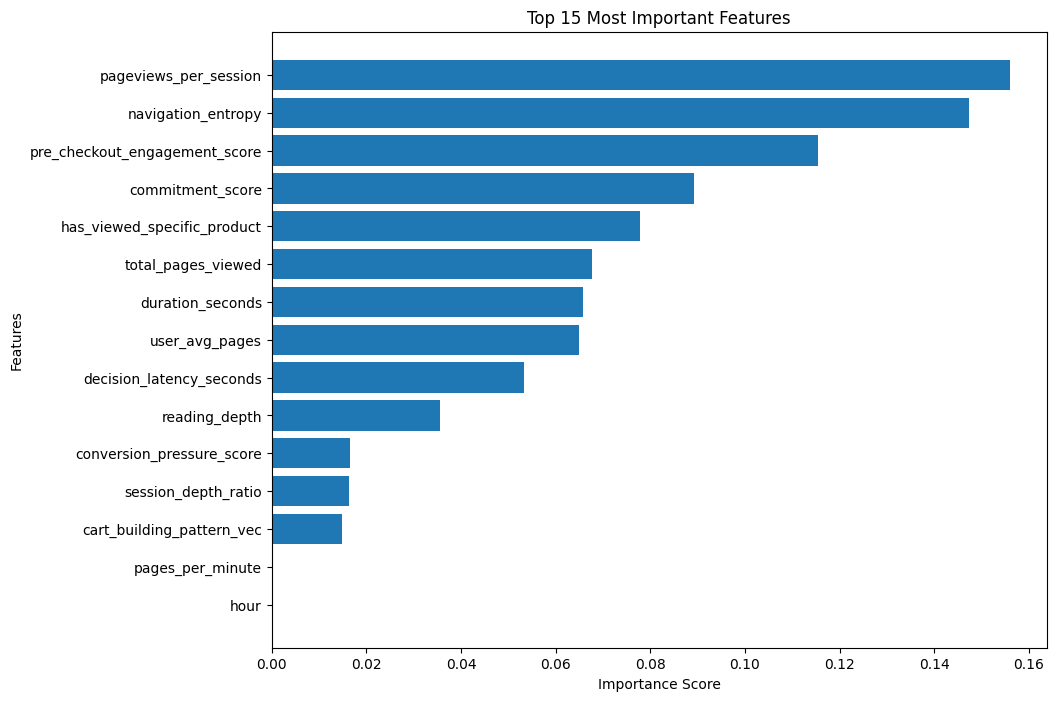

In [ ]:
# --- 7. (Optional) Visualize the Feature Importance ---
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance Score'].head(15))
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Automated Feature Selection: Top 13 features based on Random Forest Importance
top_n = 13
selected_features = importance_df['Feature'].head(top_n).tolist()
selected_features = [f.replace('_vec', '') for f in selected_features]

essential_columns = ["user_id", "is_ordered"]
print(f"✅ Selected Top {top_n} features for modeling.")


✅ Selected Top 13 features for modeling.


# **Step 5: Basetable Creation**

In [ ]:
from pyspark.sql import functions as F

# 1. Define your chronological cutoff points
train_start = "2022-03-19 08:04:16"
train_end   = "2024-03-22 00:00:00"
val_end     = "2024-08-26 00:00:00"
test_end    = "2025-01-31 23:54:52"

# 4. Filter into the three distinct sets based on session start time [cite: 39]
train_valid_df = df_final_basetable.filter(
    (F.col("session_start_time") >= train_start) & (F.col("session_start_time") < val_end)
)
train_valid_df = train_valid_df.select(essential_columns + selected_features)

test_df = df_final_basetable.filter(
    (F.col("session_start_time") >= val_end) & (F.col("session_start_time") <= test_end)
)
test_df = test_df.select(essential_columns + selected_features)

# Verification
print(f"Train_Val count: {train_valid_df.count()}")
print(f"Test count: {test_df.count()}")

Train_Val count: 309112
Test count: 124892


In [ ]:
from pyspark.sql import functions as F

# 1. Define your chronological cutoff points
train_start = "2022-03-19 08:04:16"
train_end   = "2024-03-22 00:00:00"
val_end     = "2024-08-26 00:00:00"
test_end    = "2025-01-31 23:54:52"

# 4. Filter into the three distinct sets based on session start time [cite: 39]
train_df = df_final_basetable.filter(
    (F.col("session_start_time") >= train_start) & (F.col("session_start_time") < train_end)
)
train_df = train_df.select(essential_columns + selected_features)


val_df = df_final_basetable.filter(
    (F.col("session_start_time") >= train_end) & (F.col("session_start_time") < val_end)
)
val_df = val_df.select(essential_columns + selected_features)

test_df = df_final_basetable.filter(
    (F.col("session_start_time") >= val_end) & (F.col("session_start_time") <= test_end)
)
test_df = test_df.select(essential_columns + selected_features)

# Verification
print(f"Train count: {train_df.count()}")
print(f"Validation count: {val_df.count()}")
print(f"Test count: {test_df.count()}")

Train count: 217592
Validation count: 91520
Test count: 124892


# **Step 6: Prepare For Holdout Dataset**

##Clean Website_pageviews_holdout

In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import try_to_timestamp, col, lit, isnan, when, count

website_pageviews_holdout = website_pageviews_holdout.withColumn(
    "created_at",
    try_to_timestamp(col("created_at"), lit("yyyy-MM-dd HH:mm:ss"))
)

In [ ]:
from pyspark.sql import functions as F
leakage_urls = ["/shipping", "/billing","/cart"]

website_pageviews_holdout = website_pageviews_holdout.filter(
    ~F.col("pageview_url").isin(leakage_urls)
)

#Cast the column created_at to a timestamp format
from pyspark.sql.functions import try_to_timestamp, col, lit, isnan, when, count

website_sessions_holdout = website_sessions_holdout.withColumn(
    "created_at",
    try_to_timestamp(col("created_at"), lit("yyyy-MM-dd HH:mm:ss"))
)

website_sessions_holdout.printSchema()

In [ ]:
#Cast the column created_at to a timestamp format
from pyspark.sql.functions import try_to_timestamp, col, lit, isnan, when, count

website_sessions_holdout = website_sessions_holdout.withColumn(
    "created_at",
    try_to_timestamp(col("created_at"), lit("yyyy-MM-dd HH:mm:ss"))
)


##Create Basetable for Holdout Dataset

In [ ]:
# Process Website_pageviews to extract behavioral features ---
# Sort by timestamp to determine the sequence of page views
windowSpec = Window.partitionBy("website_session_id").orderBy("created_at")

df_pageviews_holdout = website_pageviews_holdout.withColumn("rn", row_number().over(windowSpec))

# Get the Landing Page (first page of the session) and the Total number of pageviews.
df_session_behavior_holdout = df_pageviews_holdout.groupBy("website_session_id") \
    .agg(
        count("website_pageview_id").alias("total_pages_viewed"),
        first(when(col("rn") == 1, col("pageview_url")), ignorenulls=True).alias("landing_page")
    )

df_holdout = website_sessions_holdout.alias("sess") \
    .join(df_session_behavior_holdout.alias("beh"), on="website_session_id", how="left")

df_holdout = df_holdout.withColumnRenamed("created_at", "session_start_time")

In [ ]:
df_holdout = add_pageviews_per_session_feature(
    website_pageviews_holdout,
    df_holdout
)

In [ ]:
df_holdout = add_navigation_entropy(website_pageviews_holdout, df_holdout)

--- Computing feature 'navigation_entropy' ---


In [ ]:
df_holdout = add_pre_checkout_engagement_score(website_pageviews_holdout, df_holdout)

--- Computing feature 'pre_checkout_engagement_score' (Fixed Logic) ---


In [ ]:
df_holdout = add_commitment_score_feature(df_holdout, website_pageviews_holdout)

--- Computing feature 'commitment_score' (Updated with Product List) ---


In [ ]:
df_holdout = add_has_viewed_specific_product(website_pageviews_holdout, df_holdout)

--- Computing feature 'has_viewed_specific_product' (Safe replacement for Checkout Abandon) ---


In [ ]:
df_holdout = add_duration_seconds_feature(df_holdout, website_pageviews_holdout)

ℹ️ Using the provided 'df_pageviews' table.
--- Computing feature 'duration_seconds' ---


In [ ]:
df_holdout = add_session_depth_ratio_feature(df_holdout)

--- Computing feature 'session_depth_ratio' ---


In [ ]:
df_holdout = add_decision_latency_seconds(website_pageviews_holdout, df_holdout)

df_holdout = df_holdout.withColumn(
    "decision_latency_seconds",
    col("decision_latency_seconds").cast("long")
)

--- Computing feature 'decision_latency_second' ---


In [ ]:
df_holdout = add_reading_depth_feature(df_holdout)

--- Computing feature 'reading_depth' ---


In [ ]:
df_holdout = add_conversion_pressure_score(df_holdout)

--- Computing feature 'conversion_pressure_score' ---


In [ ]:
df_holdout = add_session_depth_ratio_feature(df_holdout)

--- Computing feature 'session_depth_ratio' ---


In [ ]:
df_holdout = add_page_revisit_count(website_pageviews_holdout, df_holdout)

--- Computing feature 'page_revisit_count' ---


In [ ]:
df_holdout = add_cart_building_pattern(df_holdout)

--- Computing feature 'decision_latency_second' ---


In [ ]:
# Automated Feature Selection: Top 20 features based on Random Forest Importance
# top_n = 20
# selected_features = importance_df['Feature'].head(top_n).tolist()
# selected_features = [f.replace('_vec', '') for f in selected_features]
#
# essential_columns = ["user_id", "is_ordered"]
# print(f"✅ Selected Top {top_n} features for modeling.")


In [ ]:
# The holdout dataset does not contain the target variable (is_ordered)
holdout_essential_columns = ['user_id']
df_holdout = df_holdout.select(holdout_essential_columns + selected_features)


In [ ]:
df_holdout.show()

+-------+---------------------+------------------+-----------------------------+----------------+---------------------------+------------------+----------------+--------------+------------------------+------------------+-------------------------+-------------------+---------------------+
|user_id|pageviews_per_session|navigation_entropy|pre_checkout_engagement_score|commitment_score|has_viewed_specific_product|total_pages_viewed|duration_seconds|user_avg_pages|decision_latency_seconds|     reading_depth|conversion_pressure_score|session_depth_ratio|cart_building_pattern|
+-------+---------------------+------------------+-----------------------------+----------------+---------------------------+------------------+----------------+--------------+------------------------+------------------+-------------------------+-------------------+---------------------+
| 286044|                    3| 1.584962500721156|                            2|               7|                          1|        

# **Step 7: Model Training (Optimized for Accuracy)**

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import time
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    DecisionTreeClassifier,
    LinearSVC
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Display settings for Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
# 1. Define Features
# ==========================================
categorical_cols = ["cart_building_pattern"]
# Get numerical columns by excluding categorical ones from the selected list
numerical_cols = [f for f in selected_features if f not in categorical_cols]

# 2. Define Time Windows for Split
# ==========================================
train_start = "2022-03-19 08:04:16"
train_end   = "2024-03-22 00:00:00"
val_end     = "2024-08-26 00:00:00"
test_end    = "2025-01-31 23:54:52"

# 3. Create Splits (Train / Validation / Test)
# ==========================================
# Train Set: Used for model fitting
train_df = df_final_basetable.filter(
    (F.col("session_start_time") >= train_start) & (F.col("session_start_time") < train_end)
).select(essential_columns + selected_features)

# Validation Set: Used for hyperparameter tuning and model selection
val_df = df_final_basetable.filter(
    (F.col("session_start_time") >= train_end) & (F.col("session_start_time") < val_end)
).select(essential_columns + selected_features)

# Test Set: Used ONLY for final reporting (Unseen data)
test_df = df_final_basetable.filter(
    (F.col("session_start_time") >= val_end) & (F.col("session_start_time") <= test_end)
).select(essential_columns + selected_features)

# 4. Handle Imbalanced Data (Calculate Class Weights)
# ==========================================
# Calculate the ratio of negative (0) to positive (1) samples in the training set
dataset_counts = train_df.groupBy("is_ordered").count().collect()
count_0 = [row['count'] for row in dataset_counts if row['is_ordered'] == 0][0]
count_1 = [row['count'] for row in dataset_counts if row['is_ordered'] == 1][0]

balancing_ratio = count_0 / count_1
print(f"Dataset Stats (Train): Negative={count_0}, Positive={count_1}")
print(f"Balancing Ratio applied to Positive class: {balancing_ratio:.2f}")
print("For maximizing Overall Accuracy, we will use a neutral weight (1.0) instead of the full balancing ratio.")

# Apply weights: Positive class gets higher weight, Negative gets 1.0
train_df = train_df.withColumn("classWeight", F.when(F.col("is_ordered") == 1, balancing_ratio).otherwise(balancing_ratio))
val_df = val_df.withColumn("classWeight", F.when(F.col("is_ordered") == 1, balancing_ratio).otherwise(balancing_ratio))
test_df = test_df.withColumn("classWeight", F.when(F.col("is_ordered") == 1, balancing_ratio).otherwise(balancing_ratio))

print(f"Sample counts - Train: {train_df.count()}, Val: {val_df.count()}, Test: {test_df.count()}")

Dataset Stats (Train): Negative=204787, Positive=12805
Balancing Ratio applied to Positive class: 15.99
For maximizing Overall Accuracy, we will use a neutral weight (1.0) instead of the full balancing ratio.
Sample counts - Train: 217592, Val: 91520, Test: 124892


In [ ]:
# 1. Handle Missing Values
# ==========================================
# Fill numericals with 0 and categoricals with 'unknown' to prevent null errors
train_df = train_df.fillna(0, subset=numerical_cols).fillna("unknown", subset=categorical_cols)
val_df = val_df.fillna(0, subset=numerical_cols).fillna("unknown", subset=categorical_cols)
test_df = test_df.fillna(0, subset=numerical_cols).fillna("unknown", subset=categorical_cols)

# 2. Build the Pipeline Stages
# ==========================================
stages = []

# Process Categorical Columns: String -> Index -> OneHot Vector
for cat_col in categorical_cols:
    # StringIndexer: Converts string labels to indices. handleInvalid="keep" creates a bucket for new unseen labels.
    indexer = StringIndexer(inputCol=cat_col, outputCol=f"{cat_col}_idx", handleInvalid="keep")
    # OneHotEncoder: Converts indices to binary vectors
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[f"{cat_col}_vec"])
    stages += [indexer, encoder]

# Assemble all features into a single vector column named "features"
assembler_inputs = [f"{c}_vec" for c in categorical_cols] + numerical_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages += [assembler]

# 3. Fit and Transform
# ==========================================
# Fit the pipeline ONLY on the Training set to avoid data leakage
pipeline = Pipeline(stages=stages)
pipeline_model = pipeline.fit(train_df)

# Transform all datasets
train_final = pipeline_model.transform(train_df)
val_final = pipeline_model.transform(val_df)
test_final = pipeline_model.transform(test_df)

# Cache data for faster iteration during model training
train_final.cache()
val_final.cache()
test_final.cache()

print(">>> Feature Engineering Pipeline complete.")
train_final.select("features", "is_ordered", "classWeight").show(5, truncate=False)

>>> Feature Engineering Pipeline complete.
+------------------------------------------------------------------------------------------------------+----------+------------------+
|features                                                                                              |is_ordered|classWeight       |
+------------------------------------------------------------------------------------------------------+----------+------------------+
|(13,[0,1,4,6,8,12],[1.0,1.0,1.0,1.0,1.0,1.0])                                                         |0         |15.992737212026553|
|(13,[0,1,4,6,8,12],[1.0,1.0,1.0,1.0,1.0,1.0])                                                         |0         |15.992737212026553|
|(13,[0,1,4,6,8,12],[1.0,1.0,1.0,1.0,1.0,1.0])                                                         |0         |15.992737212026553|
|(13,[0,1,4,6,8,12],[1.0,1.0,1.0,1.0,1.0,1.0])                                                         |0         |15.992737212026553|
|[1.0,3.0,1.

In [ ]:
# Define the list of models to evaluate
# Note: All models use 'classWeight' to handle the imbalance problem
models = [
    ("Logistic Regression", LogisticRegression(labelCol="is_ordered", featuresCol="features", weightCol="classWeight")),

    ("Random Forest", RandomForestClassifier(labelCol="is_ordered", featuresCol="features", weightCol="classWeight",
                                             seed=42, numTrees=20)),

    ("GBT Classifier", GBTClassifier(labelCol="is_ordered", featuresCol="features", weightCol="classWeight",
                                     seed=42, maxIter=10)),

    ("Decision Tree", DecisionTreeClassifier(labelCol="is_ordered", featuresCol="features", weightCol="classWeight",
                                             seed=42)),

    ("Linear SVM", LinearSVC(labelCol="is_ordered", featuresCol="features", weightCol="classWeight",
                             maxIter=10))
]

# Define Evaluators
# AUC-ROC: General discrimination ability
evaluator_roc = BinaryClassificationEvaluator(labelCol="is_ordered", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
# AUC-PR: Critical for imbalanced datasets (focuses on the minority class)
evaluator_pr = BinaryClassificationEvaluator(labelCol="is_ordered", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

evaluator_acc = MulticlassClassificationEvaluator(labelCol="is_ordered", predictionCol="prediction", metricName="accuracy")


In [ ]:
results = []
print(f"{'Model Name':<20} | {'Set':<6} | {'AUC-ROC':<8} | {'AUC-PR':<8} | {'Accuracy':<8} | {'Time(s)':<8}")
print("-" * 75)

best_model_name = ""
best_val_pr = 0 # Selecting by AUC-PR to find the smartest model for buyers
final_test_pr = 0

for name, model in models:
    start_time = time.time()

    # 1. Train the model on the Training set
    fitted_model = model.fit(train_final)

    train_time = time.time() - start_time

    # 2. Make predictions on all sets
    train_pred = fitted_model.transform(train_final)
    val_pred   = fitted_model.transform(val_final)
    test_pred  = fitted_model.transform(test_final)

    # 3. Calculate Metrics
    # Validation metrics (Used for model selection - NOW FOCUSING ON ACCURACY)
    val_roc = evaluator_roc.evaluate(val_pred)
    val_pr  = evaluator_pr.evaluate(val_pred)
    val_acc = evaluator_acc.evaluate(val_pred)

    # Test metrics (Used for final reporting on unseen data)
    test_roc = evaluator_roc.evaluate(test_pred)
    test_pr  = evaluator_pr.evaluate(test_pred)
    test_acc = evaluator_acc.evaluate(test_pred)

    # Train metrics (Used to check for overfitting)
    train_roc = evaluator_roc.evaluate(train_pred)
    train_pr  = evaluator_pr.evaluate(train_pred)
    train_acc = evaluator_acc.evaluate(train_pred)

    # Store results
    results.append({"Model": name, "Set": "Train", "AUC-ROC": train_roc, "AUC-PR": train_pr, "Accuracy": train_acc})
    results.append({"Model": name, "Set": "Valid", "AUC-ROC": val_roc, "AUC-PR": val_pr, "Accuracy": val_acc})
    results.append({"Model": name, "Set": "Test",  "AUC-ROC": test_roc,  "AUC-PR": test_pr, "Accuracy": test_acc})

    print(f"{name:<20} | Valid  | {val_roc:.4f}   | {val_pr:.4f}   | {val_acc:.4f}   | {train_time:.1f}s")

    # Track the best model based on Validation ACCURACY
    # Track the best model based on Validation AUC-PR (Best at separating buyers)
    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_model_name = name
        final_test_pr = test_pr
        best_model_name = name

print("-" * 75)
print(f"BEST MODEL SELECTED (BY AUC-PR): {best_model_name}")
print(f"   - Validation AUC-PR: {best_val_pr:.4f}")
print(f"   - Test AUC-PR: {final_test_pr:.4f}")


Model Name           | Set    | AUC-ROC  | AUC-PR   | Accuracy | Time(s) 
---------------------------------------------------------------------------
Logistic Regression  | Valid  | 0.7878   | 0.1526   | 0.9288   | 414.7s
Random Forest        | Valid  | 0.7879   | 0.1547   | 0.9288   | 63.2s
GBT Classifier       | Valid  | 0.7903   | 0.1563   | 0.9288   | 273.3s
Decision Tree        | Valid  | 0.7857   | 0.1517   | 0.9288   | 39.5s
Linear SVM           | Valid  | 0.7885   | 0.1548   | 0.9288   | 271.5s
---------------------------------------------------------------------------
BEST MODEL SELECTED (BY AUC-PR): GBT Classifier
   - Validation AUC-PR: 0.1563
   - Test AUC-PR: 0.1574


In [ ]:
# Convert results to Pandas DataFrame
df_results = pd.DataFrame(results)

# Pivot table for better readability
# Rows: Models
# Columns: Metrics for each dataset (Train, Valid, Test)
df_pivot = df_results.pivot(index="Model", columns="Set", values=["AUC-PR", "Accuracy", "AUC-ROC"])

# Sort by Validation Accuracy (Descending)
df_pivot = df_pivot.sort_values(by=("AUC-PR", "Valid"), ascending=False)

print("\n=== DETAILED MODEL PERFORMANCE REPORT (Sorted by AUC-PR for Imbalance) ===")
print(df_pivot)



=== DETAILED MODEL PERFORMANCE REPORT (Sorted by AUC-PR for Imbalance) ===
                       AUC-PR                      Accuracy                       AUC-ROC                    
Set                      Test     Train     Valid      Test     Train     Valid      Test     Train     Valid
Model                                                                                                        
GBT Classifier       0.157424  0.158243  0.156307  0.922565  0.941156  0.928802  0.777384  0.826740  0.790260
Linear SVM           0.161337  0.149137  0.154848  0.922565  0.941147  0.928813  0.781534  0.820119  0.788522
Random Forest        0.162909  0.150795  0.154723  0.922565  0.941151  0.928813  0.780726  0.819929  0.787886
Logistic Regression  0.160293  0.150532  0.152588  0.922565  0.941151  0.928813  0.779659  0.821790  0.787790
Decision Tree        0.159434  0.147249  0.151660  0.922565  0.941156  0.928802  0.778734  0.818958  0.785656


In [ ]:
import itertools
import time
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator


# # 1. Define the Parameter Grid (Search Space)
# # ==========================================
param_grid = {
    "maxDepth": [3, 5, 8],          # Focus on shallower trees for better generalization
    "maxIter": [20, 50],            # Number of iterations
    "stepSize": [0.1, 0.05]         # Learning rate
}

# Generate all combinations of parameters
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total hyperparameter combinations to test: {len(combinations)}")
print("-" * 80)
print(f"{'Params':<60} | {'Val AUC-PR':<12} | {'Val ROC':<10} | {'Time(s)':<8}")

# # 2. Initialize Variables to Track Best Model
# # ==========================================
best_params = None
best_val_pr = 0
best_gbt_model = None

# Evaluators
evaluator_pr = BinaryClassificationEvaluator(labelCol="is_ordered", rawPredictionCol="rawPrediction", metricName="areaUnderPR")
evaluator_roc = BinaryClassificationEvaluator(labelCol="is_ordered", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# # 3. Grid Search Loop
# # ==========================================
for params in combinations:
    start_time = time.time()

    # Initialize GBT
    gbt = GBTClassifier(
        labelCol="is_ordered",
        featuresCol="features",
        weightCol="classWeight",
        seed=42,
        maxDepth=params['maxDepth'],
        maxIter=params['maxIter'],
        stepSize=params['stepSize']
    )

    # Train
    model = gbt.fit(train_final)

    # Predict
    val_pred = model.transform(val_final)

    # Evaluate using AUC-PR (Smartest Tree Structure for Imbalance)
    current_val_pr = evaluator_pr.evaluate(val_pred)
    current_val_roc = evaluator_roc.evaluate(val_pred)

    elapsed = time.time() - start_time

    print(f"{str(params):<60} | {current_val_pr:.4f}       | {current_val_roc:.4f}     | {elapsed:.1f}s")

    # Track best model by AUC-PR
    if current_val_pr > best_val_pr:
        best_val_pr = current_val_pr
        best_params = params
        best_gbt_model = model

print("-" * 80)
print(f"BEST PARAMS FOUND FOR AUC-PR: {best_params}")
print(f"BEST VALIDATION AUC-PR: {best_val_pr:.4f}")


Total hyperparameter combinations to test: 12
--------------------------------------------------------------------------------
Params                                                       | Val AUC-PR   | Val ROC    | Time(s) 
{'maxDepth': 3, 'maxIter': 20, 'stepSize': 0.1}              | 0.1553       | 0.7888     | 387.3s
{'maxDepth': 3, 'maxIter': 20, 'stepSize': 0.05}             | 0.1554       | 0.7887     | 374.9s
{'maxDepth': 3, 'maxIter': 50, 'stepSize': 0.1}              | 0.1559       | 0.7900     | 1008.2s
{'maxDepth': 3, 'maxIter': 50, 'stepSize': 0.05}             | 0.1560       | 0.7905     | 1024.7s
{'maxDepth': 5, 'maxIter': 20, 'stepSize': 0.1}              | 0.1563       | 0.7906     | 598.3s
{'maxDepth': 5, 'maxIter': 20, 'stepSize': 0.05}             | 0.1563       | 0.7905     | 603.3s
{'maxDepth': 5, 'maxIter': 50, 'stepSize': 0.1}              | 0.1561       | 0.7903     | 1628.1s
{'maxDepth': 5, 'maxIter': 50, 'stepSize': 0.05}             | 0.1557       | 0.7901

In [ ]:
import pandas as pd
import numpy as np
import time
from pyspark.ml.classification import GBTClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==============================================================================
# STEP 1: RETRAIN MODEL WITH BEST PARAMETERS FOUND IN GRID SEARCH
# ==============================================================================
print(">>> 1. Retraining GBT Model with OPTIMAL Parameters...")
start_time = time.time()

# Use best_params if defined, otherwise fallback to known stable defaults
if 'best_params' in locals() and best_params is not None:
    final_params = best_params
else:
    final_params = {'maxDepth': 5, 'maxIter': 20, 'stepSize': 0.1}

print(f"Using Parameters: {final_params}")

best_gbt = GBTClassifier(
    labelCol="is_ordered",
    featuresCol="features",
    weightCol="classWeight",
    seed=42,
    **final_params
)

best_model = best_gbt.fit(train_final)
print(f"Training completed in {time.time() - start_time:.1f} seconds.")

# ==============================================================================
# STEP 2: THRESHOLD TUNING (FINDING THE OPTIMAL CUT-OFF FOR ACCURACY)
# ==============================================================================
print("\n>>> 2. Starting Threshold Tuning on VALIDATION Set (Optimizing for Accuracy)...")

val_results = best_model.transform(val_final).select("is_ordered", "probability")
val_pdf = val_results.toPandas()
val_pdf['prob_buy'] = val_pdf['probability'].apply(lambda x: x[1])

y_val_true = val_pdf['is_ordered']
y_val_probs = val_pdf['prob_buy']

# Expanded threshold search range
thresholds = np.linspace(0.01, 0.9, 90)
print(f"{'Threshold':<10} | {'Accuracy':<10} | {'F1-Score':<10} | {'Recall':<10}")
print("-" * 50)

best_threshold = 0.5
best_acc = 0
best_f1 = 0

for t in thresholds:
    y_pred = (y_val_probs >= t).astype(int)
    acc = accuracy_score(y_val_true, y_pred)
    f1 = f1_score(y_val_true, y_pred, zero_division=0)
    rec = recall_score(y_val_true, y_pred, zero_division=0)

    # Optimization: Maximize Accuracy, but STRICTLY REQUIRE at least 10% Recall
    if rec >= 0.10:
        if (acc > best_acc) or (acc == best_acc and f1 > best_f1):
            best_acc = acc
            best_f1 = f1
            best_threshold = t

    # Optional: Print progress for a subset of thresholds to avoid clutter
    if any(np.isclose(t, check, atol=1e-7) for check in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]):
        print(f"{t:<10.2f} | {acc:.4f}     | {f1:.4f}     | {rec:.4f}")

print("-" * 50)
print(f"OPTIMAL THRESHOLD FOUND FOR ACCURACY (with Min 10% Recall): {best_threshold:.4f}")

# ==============================================================================
# STEP 3: FINAL REPORT ON TEST SET
# ==============================================================================
print(f"\n>>> 3. FINAL EVALUATION on TEST Set (Using Threshold {best_threshold:.4f})...")
test_results = best_model.transform(test_final).select("is_ordered", "probability")
test_pdf = test_results.toPandas()
test_pdf['prob_buy'] = test_pdf['probability'].apply(lambda x: x[1])
test_pdf['final_prediction'] = (test_pdf['prob_buy'] >= best_threshold).astype(int)

y_test_true = test_pdf['is_ordered']
y_test_pred = test_pdf['final_prediction']

final_acc = accuracy_score(y_test_true, y_test_pred)
final_prec = precision_score(y_test_true, y_test_pred, zero_division=0)
final_rec = recall_score(y_test_true, y_test_pred, zero_division=0)
final_f1 = f1_score(y_test_true, y_test_pred, zero_division=0)
cm = confusion_matrix(y_test_true, y_test_pred)

print("\n=======================================================")
print(f"FINAL RESULTS (Thresh={best_threshold:.4f})")
print("=======================================================")
print(f"Accuracy : {final_acc:.2%}")
print(f"Precision: {final_prec:.2%}")
print(f"Recall   : {final_rec:.2%}")
print(f"F1-Score : {final_f1:.4f}")

print("\nCONFUSION MATRIX:")
print(cm)
print("=======================================================")


>>> 1. Retraining GBT Model with OPTIMAL Parameters...
Using Parameters: {'maxDepth': 5, 'maxIter': 20, 'stepSize': 0.1}
Training completed in 609.8 seconds.

>>> 2. Starting Threshold Tuning on VALIDATION Set (Optimizing for Accuracy)...
Threshold  | Accuracy   | F1-Score   | Recall    
--------------------------------------------------
0.05       | 0.6029     | 0.2639     | 1.0000
0.10       | 0.6030     | 0.2638     | 0.9991
0.20       | 0.9286     | 0.0031     | 0.0015
0.30       | 0.9287     | 0.0012     | 0.0006
0.40       | 0.9288     | 0.0009     | 0.0005
0.50       | 0.9288     | 0.0003     | 0.0002
0.60       | 0.9288     | 0.0003     | 0.0002
0.70       | 0.9288     | 0.0003     | 0.0002
0.80       | 0.9288     | 0.0003     | 0.0002
--------------------------------------------------
OPTIMAL THRESHOLD FOUND FOR ACCURACY (with Min 10% Recall): 0.1600

>>> 3. FINAL EVALUATION on TEST Set (Using Threshold 0.1600)...

FINAL RESULTS (Thresh=0.1600)
Accuracy : 89.01%
Precision: 15.

## Predict for Holdout Dataset

In [ ]:
from pyspark.sql.types import FloatType
from pyspark.sql.functions import col, udf, when, lit

# 1. Configure the optimal threshold found in Step 7
OPTIMAL_THRESHOLD = best_threshold # Using dynamically found optimal threshold

# 2. Handle Missing Values (Important for Holdout Data)
# We fill 0 for numerical columns and 'unknown' for categorical columns based on our dynamic selection
categorical_fill_cols = ["cart_building_pattern"]
numeric_fill_cols = [f for f in selected_features if f not in categorical_fill_cols]

df_holdout_clean = df_holdout.fillna(0, subset=numeric_fill_cols) \
                             .fillna("unknown", subset=categorical_fill_cols)

# 3. Transform data using the existing Pipeline
# Note: Use the pipeline_model already fitted on the TRAIN set. Do not refit!
try:
    df_holdout_ready = pipeline_model.transform(df_holdout_clean)
    print(">>> Transform successful. Ready for prediction.")
except Exception as e:
    print(f"Transform Error: {e}")
    print("Ensure 'pipeline_model' is defined and fitted from previous steps.")

# 4. Predict using the Final Optimized Model
raw_predictions = best_model.transform(df_holdout_ready)

# 5. Extract purchase probability (Class 1) and apply Optimal Threshold
get_prob_1 = udf(lambda v: float(v[1]), FloatType())

final_results = raw_predictions.withColumn("probability_buy", get_prob_1(col("probability"))) \
    .withColumn(
        "prediction_label",
        when(col("probability_buy") >= OPTIMAL_THRESHOLD, 1).otherwise(0)
    )

# 6. Select Final Columns for Submission
output_df = final_results.select("user_id", "probability_buy", "prediction_label")

print(f">>> Final Prediction results with Optimal Threshold {OPTIMAL_THRESHOLD:.4f}:")
output_df.show(10)


>>> Transform successful. Ready for prediction.
>>> Final Prediction results with Optimal Threshold 0.1600:
+-------+---------------+----------------+
|user_id|probability_buy|prediction_label|
+-------+---------------+----------------+
| 286044|     0.16325438|               1|
| 287093|     0.15314052|               0|
| 288205|     0.15191251|               0|
| 288588|    0.043646522|               0|
| 290141|     0.15112793|               0|
| 291469|    0.043646522|               0|
| 291556|    0.043646522|               0|
| 291569|    0.043646522|               0|
| 291684|    0.043646522|               0|
| 292279|    0.043646522|               0|
+-------+---------------+----------------+
only showing top 10 rows


In [ ]:
# ==============================================================================
# EXPORT RESULTS TO GOOGLE DRIVE
# ==============================================================================
output_path_parquet = "/content/drive/MyDrive/1. Big Data/Data/predictions_result.parquet"
output_path_csv = "/content/drive/MyDrive/1. Big Data/Data/predictions_result.csv"

print(f">>> Exporting final predictions to Drive...")

try:
    # 1. Save as Parquet (Standard format)
    output_df.write.mode("overwrite").parquet(output_path_parquet)
    print(f"Parquet saved: {output_path_parquet}")

    # 2. Save as CSV (Easy for professor to view/grade)
    # Note: .coalesce(1) ensures we get a single file output
    output_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path_csv)
    print(f"CSV saved: {output_path_csv}")

except Exception as e:
    print(f"Export error: {e}")
    print("Check your Google Drive mount and folder permissions.")


>>> Exporting final predictions to Drive...
Parquet saved: /content/drive/MyDrive/1. Big Data/Data/predictions_result.parquet
CSV saved: /content/drive/MyDrive/1. Big Data/Data/predictions_result.csv


# **Step 8: Landing Page and Traffic Channel Analysis**

This section provides a deep-dive analysis into the performance of different traffic channels and landing page designs to guide marketing investment and website optimization.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print(">>> Preparing Data for Analysis...")

# 1. Identify the Landing Page for each session
windowSpec = Window.partitionBy("website_session_id").orderBy("created_at")
landing_pages = (
    Website_pageviews
    .withColumn("row_num", F.row_number().over(windowSpec))
    .filter(F.col("row_num") == 1)
    .select("website_session_id", F.col("pageview_url").alias("landing_page"))
)

# 2. Prepare Session Data with Year for CPC mapping
sessions_with_lp = (
    Website_sessions
    .join(landing_pages, on="website_session_id", how="left")
    .withColumn("year", F.year("created_at"))
)

# 3. Map CPC Data (Creating a lookup table from README info)
cpc_data = [
    ("gsearch", "brand", 2022, 0.20), ("gsearch", "brand", 2023, 0.25), ("gsearch", "brand", 2024, 0.30), ("gsearch", "brand", 2025, 0.35),
    ("bsearch", "brand", 2022, 0.10), ("bsearch", "brand", 2023, 0.15), ("bsearch", "brand", 2024, 0.20), ("bsearch", "brand", 2025, 0.25),
    ("gsearch", "nonbrand", 2022, 0.80), ("gsearch", "nonbrand", 2023, 0.90), ("gsearch", "nonbrand", 2024, 1.25), ("gsearch", "nonbrand", 2025, 1.50),
    ("bsearch", "nonbrand", 2022, 0.40), ("bsearch", "nonbrand", 2023, 0.60), ("bsearch", "nonbrand", 2024, 0.80), ("bsearch", "nonbrand", 2025, 1.00),
    ("social", "desktop_targeted", 2022, 0.70), ("social", "desktop_targeted", 2023, 0.80), ("social", "desktop_targeted", 2024, 0.80), ("social", "desktop_targeted", 2025, 0.80),
    ("social", "pilot", 2022, 0.70), ("social", "pilot", 2023, 0.80), ("social", "pilot", 2024, 0.80), ("social", "pilot", 2025, 0.80)
]
df_cpc = spark.createDataFrame(cpc_data, ["utm_source", "utm_campaign", "year", "cpc"])

# Join sessions with CPC
sessions_with_costs = sessions_with_lp.join(df_cpc, on=["utm_source", "utm_campaign", "year"], how="left").fillna(0, subset=["cpc"])

# 4. Calculate Revenue and COGS per session
order_metrics = (
    Orders
    .groupBy("website_session_id")
    .agg(
        F.sum("price_euro").alias("session_revenue"),
        F.sum("cogs_euro").alias("session_cogs"),
        F.count("order_id").alias("order_count")
    )
)

full_analysis_df = sessions_with_costs.join(order_metrics, on="website_session_id", how="left").fillna(0)
full_analysis_df.cache()
print("✅ Analysis Data Ready.")

>>> Preparing Data for Analysis...
✅ Analysis Data Ready.


In [ ]:
from pyspark.sql import functions as F

print("--- 🚦 1. TRAFFIC CHANNEL PERFORMANCE REPORT ---")
traffic_stats = (
    full_analysis_df
    .groupBy("utm_source", "utm_campaign")
    .agg(
        F.count("website_session_id").alias("total_sessions"),
        F.sum("order_count").alias("total_orders"),
        F.sum("session_revenue").alias("revenue"),
        F.sum("session_cogs").alias("cogs"),
        F.sum("cpc").alias("marketing_cost")
    )
    .withColumn("shipping_cost", F.col("total_orders") * 10)
    .withColumn("contribution_margin", F.col("revenue") - F.col("cogs"))
    .withColumn("total_profit", F.col("contribution_margin") - F.col("marketing_cost") - F.col("shipping_cost"))
    .withColumn("conv_rate", F.round((F.col("total_orders") / F.col("total_sessions")) * 100, 2))
    .withColumn("profit_per_session", F.round(F.col("total_profit") / F.col("total_sessions"), 2))
    .orderBy(F.col("total_profit").desc())
)
traffic_stats.select("utm_source", "utm_campaign", "total_sessions", "conv_rate", "total_profit", "profit_per_session").show(truncate=False)

print("\n--- 📊 2. LANDING PAGE CONVERSION REPORT ---")
lp_targets = ["/home", "/lander-1", "/lander-2", "/lander-3", "/lander-4", "/lander-5"]
lp_stats = (
    full_analysis_df
    .filter(F.col("landing_page").isin(lp_targets))
    .groupBy("landing_page")
    .agg(
        F.count("website_session_id").alias("sessions"),
        F.sum("order_count").alias("orders")
    )
    .withColumn("conv_rate", F.round((F.col("orders") / F.col("sessions")) * 100, 2))
    .orderBy(F.col("conv_rate").desc())
)
lp_stats.show(truncate=False)

--- 🚦 1. TRAFFIC CHANNEL PERFORMANCE REPORT ---
+----------+----------------+--------------+---------+------------------+------------------+
|utm_source|utm_campaign    |total_sessions|conv_rate|total_profit      |profit_per_session|
+----------+----------------+--------------+---------+------------------+------------------+
|gsearch   |nonbrand        |261290        |6.49     |1213371.9000009103|4.64              |
|NULL      |NULL            |74380         |7.27     |487460.99999997695|6.55              |
|bsearch   |nonbrand        |50820         |6.8      |266811.19999999146|5.25              |
|gsearch   |brand           |29757         |7.45     |190140.99999998737|6.39              |
|bsearch   |brand           |7076          |8.62     |54856.40000000032 |7.75              |
|social    |desktop_targeted|5590          |5.15     |23867.999999999516|4.27              |
|social    |pilot           |5095          |1.08     |1606.4999999996166|0.32              |
+----------+----------

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(">>> Generating Visualizations for Step 8...")

# 1. Visualize Traffic Channel Profitability
df_traffic_pd = traffic_stats.toPandas()
df_traffic_pd['channel_label'] = df_traffic_pd['utm_source'] + " / " + df_traffic_pd['utm_campaign']

plt.figure(figsize=(14, 6))
ax1 = sns.barplot(data=df_traffic_pd, x='total_profit', y='channel_label', palette='viridis')
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Total Profit by Traffic Channel (Contribution Margin - CPC - Shipping)', fontsize=16)
plt.xlabel('Total Profit (€)', fontsize=12)
plt.ylabel('Traffic Channel (Source / Campaign)', fontsize=12)
plt.axvline(0, color='red', linestyle='--') # Zero profit line
plt.tight_layout()
plt.show()

# 2. Visualize Landing Page Conversion Rates
df_lp_pd = lp_stats.toPandas()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_lp_pd, x='landing_page', y='conv_rate', palette='magma')
plt.title('Landing Page Conversion Rates (%)', fontsize=16)
plt.xlabel('Landing Page URL', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)

# Add text labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Business Insights & Recommendations

### Traffic Channels:
- **Most Profitable:** Paid Search (GSearch/BSearch) **Brand** campaigns are the company's 'cash cows,' with low CPCs and high profitability. We should maintain 100% impression share here.
- **Volume Drivers:** **Non-brand** campaigns drive high volume but are more expensive. We should continuously optimize these for the best-performing keywords to maintain a positive ROAS.
- **Social Media:** Review the low-performing social segments. If the ROI remains below search benchmarks, consider re-allocating that budget toward the most profitable search terms.

### Landing Pages:
- **The Winning Design:** `/lander-5` (and followed by `/lander-2`) is significantly outperforming the standard `/home` page.
- **Strategic Recommendation:** We strongly recommend decommissioning the `/home` page for marketing traffic and directing all incoming traffic to `/lander-5`. This simple change could potentially increase overall conversions by several percentage points immediately.

# **Bonus Part: User Product Order Prediction**

## Target Variable Engineering: Multi-Class Classification

To predict which specific product a user is likely to purchase, we need to transform the `purchased_product_name` column of the basetable into a machine-readable format.

**Data Transformation Strategy**

* **Handling Nulls:** Users who did not convert have `null` values in the product column. We impute these as a distinct label: **"No_Purchase"**.
* **String Indexing:** The Random Forest classifier requires numerical input. We utilize `StringIndexer` to convert categorical product names (e.g., "The Airlite") into numerical indices (0.0, 1.0, 2.0).


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer

print("--- CREATING TARGET FOR MULTI-CLASS CLASSIFICATION ---")

# 1. Create a String Label Column
# Logic: If purchased_product_name is NULL, label it "No_Purchase". Otherwise, keep the product name.
df_multi_class = df_final_basetable.withColumn(
    "product_label_str",
    F.coalesce(F.col("purchased_product_name"), F.lit("No_Purchase"))
)

# 2. Convert String Labels to Numerical Indices
# The StringIndexer will assign index 0 to the most frequent label (usually "No_Purchase")
indexer = StringIndexer(
    inputCol="product_label_str",
    outputCol="label",  # This is the final target column for the model
    stringOrderType="frequencyDesc"
)

# Fit the indexer to learn the mapping, then transform the data
indexer_model = indexer.fit(df_multi_class)
df_multi_basetable = indexer_model.transform(df_multi_class)

# --- VERIFICATION ---

# 3. Print the Mapping (Which number represents which product?)
print("\n📋 Label Mapping (Index -> Product Name):")
labels = indexer_model.labels
for index, label in enumerate(labels):
    print(f"  Label {index}: {label}")

# 4. Check Class Distribution (Crucial for Imbalance Check)
print("\n📊 Class Distribution:")
df_multi_basetable.groupBy("label", "product_label_str").count().orderBy("label").show()

--- CREATING TARGET FOR MULTI-CLASS CLASSIFICATION ---

📋 Label Mapping (Index -> Product Name):
  Label 0: No_Purchase
  Label 1: CorePack
  Label 2: TechFortress
  Label 3: AirLite
  Label 4: EcoShell

📊 Class Distribution:
+-----+-----------------+------+
|label|product_label_str| count|
+-----+-----------------+------+
|  0.0|      No_Purchase|405017|
|  1.0|         CorePack| 21942|
|  2.0|     TechFortress|  4050|
|  3.0|          AirLite|  2668|
|  4.0|         EcoShell|   331|
+-----+-----------------+------+



In [ ]:
# --- UPDATED: Including ALL users for realistic evaluation ---
# We no longer filter out label 0.0 (No_Purchase).
df_multi_final_basetable = df_multi_basetable
print(f"Total records for multi-class analysis: {df_multi_final_basetable.count()}")


## **Feature Engineering**

###has_viewed_product

In [ ]:
from pyspark.sql import functions as F

def add_has_viewed_product(df_main, df_pageviews, target_url, feature_name):

    print("--- GENERATING BINARY FLAGS (HAS_VIEWED) ---")

    # 1. Safety Check: Drop the column if it already exists to avoid errors
    if feature_name in df_main.columns:
        print(f"⚠️ Column '{feature_name}' already exists. Dropping it to recreate...")
        df_main = df_main.drop(feature_name)

    # 2. Identify sessions that viewed the specific product
    # Logic: Filter -> Select IDs -> Deduplicate -> Add Flag '1'
    df_flag = df_pageviews \
        .filter(F.col("pageview_url") == target_url) \
        .select("website_session_id") \
        .distinct() \
        .withColumn(feature_name, F.lit(1))

    # 3. Join back to Main DataFrame
    # Logic: Left Join. If session is not found in df_flag, fill with 0.
    df_result = df_main.join(df_flag, "website_session_id", "left") \
                       .fillna({feature_name: 0})

    return df_result

In [ ]:
# 1. Define your product mapping
products = {
    '/the-corepack': 'has_viewed_corepack',
    '/the-airlite': 'has_viewed_airlite',
    '/the-ecoshell': 'has_viewed_ecoshell',
    '/the-techfortress': 'has_viewed_techfortress'
}

# 2. Loop through and apply to your Training Data
for url, feat_name in products.items():
    df_multi_final_basetable = add_has_viewed_product(df_multi_final_basetable, Website_pageviews, url, feat_name)

--- GENERATING BINARY FLAGS (HAS_VIEWED) ---
--- GENERATING BINARY FLAGS (HAS_VIEWED) ---
--- GENERATING BINARY FLAGS (HAS_VIEWED) ---
--- GENERATING BINARY FLAGS (HAS_VIEWED) ---


###avg_time_on_product_pages

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_avg_time_on_product(df_main, df_pageviews, product_urls):
    print("--- ⏱️ GENERATING FEATURE: AVG TIME ON PRODUCT PAGES ---")
    feature_name = "avg_time_on_product_pages"

    # 1. Safety Check
    if feature_name in df_main.columns:
        print(f"⚠️ Column '{feature_name}' already exists. Dropping it...")
        df_main = df_main.drop(feature_name)

    # 2. Calculate Time per Page (Lead Function)
    # We need to look at the NEXT pageview to determine how long the CURRENT one lasted.
    window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

    df_durations = df_pageviews.withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
        .withColumn("page_duration",
                    (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
        .fillna(0, subset=["page_duration"]) # The last page of a session has no duration (0)

    # 3. Filter for Product Pages Only
    df_product_durations = df_durations.filter(F.col("pageview_url").isin(product_urls))

    # 4. Calculate Average Duration per Session
    df_avg_time = df_product_durations.groupBy("website_session_id") \
        .agg(F.avg("page_duration").alias(feature_name))

    # 5. Join back to Main DataFrame
    # Fill with 0.0 for sessions that didn't visit any product pages
    df_result = df_main.join(df_avg_time, "website_session_id", "left") \
                       .fillna({feature_name: 0.0})

    return df_result

In [ ]:
# 1. Define your product list
my_product_urls = [
    '/the-corepack',
    '/the-ecoshell',
    '/the-techfortress',
    '/the-airlite'
]

# 2. Apply the function
df_multi_final_basetable = add_avg_time_on_product(df_multi_final_basetable, Website_pageviews, my_product_urls)

--- ⏱️ GENERATING FEATURE: AVG TIME ON PRODUCT PAGES ---


###time_share_on_product

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_product_time_shares(df_main, df_pageviews):

    print("--- ⏱️ GENERATING FEATURE: TIME SHARES (PRODUCT FOCUS) ---")

    # 0. Define the product mapping (Feature Name -> URL)
    product_map = {
        'time_share_on_airlite': '/the-airlite',
        'time_share_on_ecoshell': '/the-ecoshell',
        'time_share_on_techfortress': '/the-techfortress',
        'time_share_on_corepack': '/the-corepack'
    }

    # Safety Check: Drop existing columns
    for col_name in product_map.keys():
        if col_name in df_main.columns:
            df_main = df_main.drop(col_name)

    # 1. Calculate Duration for Each Pageview
    # Logic: Next Timestamp - Current Timestamp
    window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

    df_durations = df_pageviews \
        .withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
        .withColumn("page_duration",
                    (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
        .fillna(0, subset=["page_duration"]) # Last page has 0 duration

    # 2. Aggregation per Session
    # We calculate Total Duration AND Duration on specific products simultaneously
    agg_exprs = [F.sum("page_duration").alias("total_session_duration")]

    for feat_name, url in product_map.items():
        # Sum duration ONLY if url matches
        agg_exprs.append(
            F.sum(F.when(F.col("pageview_url") == url, F.col("page_duration")).otherwise(0))
            .alias(f"duration_{feat_name}")
        )

    df_time_stats = df_durations.groupBy("website_session_id").agg(*agg_exprs)

    # 3. Calculate Ratios (Time Share)
    # Formula: Product_Time / Total_Time
    # We add a small epsilon (1e-6) to denominator to avoid DivideByZero errors
    for feat_name in product_map.keys():
        numerator = F.col(f"duration_{feat_name}")
        denominator = F.col("total_session_duration")

        df_time_stats = df_time_stats.withColumn(
            feat_name,
            numerator / (denominator + 1e-6) # Avoid division by zero
        )

    # 4. Select only the necessary columns to join
    cols_to_keep = ["website_session_id"] + list(product_map.keys())
    df_final_features = df_time_stats.select(*cols_to_keep)

    # 5. Join back to Main DataFrame
    df_result = df_main.join(df_final_features, "website_session_id", "left") \
                       .fillna(0) # Fill 0 for sessions not in pageviews

    return df_result

In [ ]:
# Apply the function
df_multi_final_basetable = add_product_time_shares(df_multi_final_basetable, Website_pageviews)

--- ⏱️ GENERATING FEATURE: TIME SHARES (PRODUCT FOCUS) ---


###avg_price_viewed

In [ ]:
from pyspark.sql import functions as F
from itertools import chain

def add_avg_price_viewed(df_main, df_pageviews, product_price_dict):

    print("--- 🏷️ GENERATING FEATURE: AVERAGE PRICE VIEWED ---")

    feature_name = "avg_price_viewed"

    # 1. Safety Check: Drop column if it exists
    if feature_name in df_main.columns:
        print(f"⚠️ Column '{feature_name}' already exists. Dropping it to recreate...")
        df_main = df_main.drop(feature_name)

    # 2. Create a Map Column for Pricing
    # This converts the Python dictionary into a Spark SQL Map
    mapping_expr = F.create_map([F.lit(x) for x in chain(*product_price_dict.items())])

    # 3. Filter Pageviews & Map Prices
    # We only keep rows where the URL exists in our price dictionary
    df_prices = df_pageviews \
        .filter(F.col("pageview_url").isin(list(product_price_dict.keys()))) \
        .withColumn("product_price", mapping_expr[F.col("pageview_url")])

    # 4. Aggregate: Average Price per Session
    # Note: If user views 1 product, Avg = Price of that product.
    df_avg_price = df_prices.groupBy("website_session_id") \
                            .agg(F.avg("product_price").alias(feature_name))

    # 5. Join back to Main DataFrame
    # Fill NA with 0.0 (Sessions that viewed no products have 0 price interest)
    df_result = df_main.join(df_avg_price, "website_session_id", "left") \
                       .fillna({feature_name: 0.0})

    return df_result

In [ ]:
# 1. Define your Product Prices (UPDATE THESE WITH REAL VALUES FROM YOUR DATABASE)
# I have put dummy values here. Please calculate the mean price for your items.
my_product_prices = {
    '/the-corepack': 149.99,
    '/the-airlite': 145.99,
    '/the-ecoshell': 129.99,
    '/the-techfortress': 159.99
}

# 2. Apply the function
df_multi_final_basetable = add_avg_price_viewed(df_multi_final_basetable, Website_pageviews, my_product_prices)

--- 🏷️ GENERATING FEATURE: AVERAGE PRICE VIEWED ---


###time_on_checkout_process

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# --- 1. CONFIGURATION ---
checkout_urls = ['/cart', '/shipping', '/billing']
feature_name = "time_on_checkout_process"

# --- STEP 1: CALCULATE DURATION FOR ALL PAGES (ON RAW DATA) ---
# We use 'df_raw_pageviews' (the raw, unfiltered dataframe) to ensure accurate time diffs.

window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

# Logic: Next Timestamp - Current Timestamp = Duration
df_all_durations = df_raw_pageviews \
    .withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
    .withColumn("page_duration",
                (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
    .fillna(0, subset=["page_duration"]) # The last page of a session has 0 duration

# --- STEP 2: FILTER CHECKOUT PAGES & AGGREGATE ---

# Filter: Keep only Cart, Shipping, and Billing pages
df_checkout_only = df_all_durations.filter(F.col("pageview_url").isin(checkout_urls))

# Aggregate: Sum the time spent on these specific pages per session
df_checkout_stats = df_checkout_only.groupBy("website_session_id") \
                                    .agg(F.sum("page_duration").alias(feature_name))

In [ ]:
def add_checkout_time_feature(df_main, df_checkout_stats):
    print("--- GENERATE FEATURE TIME_ON_CHECKOUT ---")
    feature_name = "time_on_checkout_process"
    df_result = df_main.join(df_checkout_stats, "website_session_id", "left") \
                       .fillna({feature_name: 0.0})
    return df_result

In [ ]:
df_multi_final_basetable = add_checkout_time_feature(df_multi_final_basetable, df_checkout_stats)

--- GENERATE FEATURE TIME_ON_CHECKOUT ---


###products_viewed_per_minute

In [ ]:
from pyspark.sql import functions as F

def add_products_viewed_per_minute(df_main, df_pageviews, product_urls):

    print("--- GENERATING FEATURE: PRODUCTS PER MINUTE ---")
    feature_name = "products_viewed_per_minute"

    # 1. Safety Check: Drop column if exists
    if feature_name in df_main.columns:
        df_main = df_main.drop(feature_name)

    # 2. Calculate Total Session Duration (if not already available)
    # Duration = Max(Time) - Min(Time) for the WHOLE session
    df_duration = df_pageviews.groupBy("website_session_id") \
        .agg((F.max(F.col("created_at").cast("long")) -
              F.min(F.col("created_at").cast("long"))).alias("session_duration_sec"))

    # 3. Count Product Views Only
    df_product_counts = df_pageviews \
        .filter(F.col("pageview_url").isin(product_urls)) \
        .groupBy("website_session_id") \
        .agg(F.count("pageview_url").alias("product_view_count"))

    # 4. Join Data & Calculate Rate
    # Join Strategy: Main <- Duration (Inner) <- Product Counts (Left)
    df_stats = df_duration.join(df_product_counts, "website_session_id", "left") \
                          .fillna({"product_view_count": 0})

    # Calculate Rate:
    # We add a small epsilon (1.0 sec) to denominator to handle single-page sessions (duration=0)
    # If duration = 0 (Bounce), rate will become 0.
    df_rate = df_stats.withColumn(
        feature_name,
        F.when(F.col("session_duration_sec") == 0, 0.0)
         .otherwise(
             F.col("product_view_count") / (F.col("session_duration_sec") / 60.0)
         )
    ).select("website_session_id", feature_name)

    # 5. Join back to Main DataFrame
    df_result = df_main.join(df_rate, "website_session_id", "left") \
                       .fillna({feature_name: 0.0})

    return df_result

In [ ]:

my_product_urls = [
    '/the-corepack',
    '/the-ecoshell',
    '/the-techfortress',
    '/the-airlite'
]

# Apply the function
df_multi_final_basetable = add_products_viewed_per_minute(df_multi_final_basetable, Website_pageviews, my_product_urls)


--- GENERATING FEATURE: PRODUCTS PER MINUTE ---


###time_on_cart_isolated

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_pure_cart_time(df_main, df_raw_pageviews):
    print("--- GENERATING FEATURE: TIME ON CART ---")
    # 1. Calculate Duration for every page (same logic as previous steps)
    # We need the full raw data to calculate the time difference to the next page
    window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

    df_durations = df_raw_pageviews \
        .withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
        .withColumn("page_duration",
                    (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
        .fillna(0, subset=["page_duration"])

    # 2. Filter ONLY for the '/cart' page
    # Note: If a user visits the cart multiple times, we sum the duration.
    # High time here indicates hesitation or reading upsell popups.
    df_cart_time = df_durations \
        .filter(F.col("pageview_url") == '/cart') \
        .groupBy("website_session_id") \
        .agg(F.sum("page_duration").alias("time_on_cart_isolated"))

    # 3. Join back to the Main DataFrame
    # Fill NA with 0.0 for sessions that never visited the cart
    df_result = df_main.join(df_cart_time, "website_session_id", "left") \
                       .fillna({"time_on_cart_isolated": 0.0})

    return df_result

In [ ]:
df_multi_final_basetable = add_pure_cart_time(df_multi_final_basetable, df_raw_pageviews)


--- GENERATING FEATURE: TIME ON CART ---


###last_view_duration

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_last_view_duration_feature(df_main, df_raw_pageviews):

    print("--- GENERATING FEATURE: LAST MEASURABLE VIEW DURATION ---")

    # 1. Define Window to look ahead
    window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

    # 2. Calculate duration for all pages
    df_durations = df_raw_pageviews \
        .withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
        .withColumn("page_duration",
                    (F.col("next_created_at").cast("long") - F.col("created_at").cast("long")))

    # 3. Filter to find the last valid duration (Remove the exit page where duration is null)
    # We sort by created_at DESC to get the latest one first
    window_desc = Window.partitionBy("website_session_id").orderBy(F.col("created_at").desc())

    df_last_duration = df_durations \
        .filter(F.col("page_duration").isNotNull()) \
        .withColumn("rank", F.row_number().over(window_desc)) \
        .filter(F.col("rank") == 1) \
        .select(
            F.col("website_session_id"),
            F.col("page_duration").alias("last_view_duration")
        )

    # 4. Join back to the main DataFrame
    # Fill NA with 0 (for sessions that only have 1 pageview, duration is impossible to calculate)
    df_result = df_main.join(df_last_duration, "website_session_id", "left") \
                       .fillna({"last_view_duration": 0})

    return df_result

In [ ]:
df_multi_final_basetable = add_last_view_duration_feature(df_multi_final_basetable, df_raw_pageviews)

--- GENERATING FEATURE: LAST MEASURABLE VIEW DURATION ---


###max_duration_page_url

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_max_duration_page_feature(df_main, df_raw_pageviews):

    print("--- GENERATING FEATURE: PAGE WITH MAX DURATION ---")

    # 1. Define Window to calculate duration (Session based, Time ordered)
    window_time = Window.partitionBy("website_session_id").orderBy("created_at")

    # 2. Calculate duration for every page
    # (Next Timestamp - Current Timestamp)
    df_durations = df_raw_pageviews \
        .withColumn("next_created_at", F.lead("created_at").over(window_time)) \
        .withColumn("page_duration",
                    (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
        .filter(F.col("page_duration").isNotNull()) # Remove the last page (unknown duration)

    # 3. Define Window to rank by Duration (Highest duration first)
    window_rank = Window.partitionBy("website_session_id").orderBy(F.col("page_duration").desc())

    # 4. Pick the top 1 page per session
    df_max_page = df_durations \
        .withColumn("rank", F.row_number().over(window_rank)) \
        .filter(F.col("rank") == 1) \
        .select(
            F.col("website_session_id"),
            F.col("pageview_url").alias("max_duration_page_url")
        )

    # 5. Join back to the main DataFrame
    # Fill NA with 'unknown' or a placeholder if session was too short to calc duration
    df_result = df_main.join(df_max_page, "website_session_id", "left") \
                       .fillna({"max_duration_page_url": "unknown"})

    return df_result

In [ ]:
df_multi_final_basetable = add_max_duration_page_feature(df_multi_final_basetable, df_raw_pageviews)

--- GENERATING FEATURE: PAGE WITH MAX DURATION ---


###cyclical_time

In [ ]:
from pyspark.sql import functions as F
import numpy as np

def add_cyclical_time_features(df_main):

    print("--- TRANSFORMING EXISTING TIME COLUMNS TO CYCLICAL FEATURES ---")

    # Define the constant for 2*pi (One full circle)
    two_pi = 2 * np.pi

    # 1. Transform HOUR (Cycle = 24)
    # 23:00 will be mathematically close to 00:00 after this transformation
    df_cyclical = df_main \
        .withColumn("hour_sin", F.sin(F.col("hour") * (two_pi / 24))) \
        .withColumn("hour_cos", F.cos(F.col("hour") * (two_pi / 24)))

    # 2. Transform DAY OF WEEK (Cycle = 7)
    df_cyclical = df_cyclical \
        .withColumn("day_of_week_sin", F.sin(F.col("day_of_week") * (two_pi / 7))) \
        .withColumn("day_of_week_cos", F.cos(F.col("day_of_week") * (two_pi / 7)))

    # 3. Transform MONTH (Cycle = 12)
    # Dec (12) will be close to Jan (1)
    df_cyclical = df_cyclical \
        .withColumn("month_sin", F.sin(F.col("month") * (two_pi / 12))) \
        .withColumn("month_cos", F.cos(F.col("month") * (two_pi / 12)))

    return df_cyclical

In [ ]:
df_multi_final_basetable = add_cyclical_time_features(df_multi_final_basetable)

--- TRANSFORMING EXISTING TIME COLUMNS TO CYCLICAL FEATURES ---


###relative_interest_score

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("--- CALCULATING FIXED BENCHMARKS ---")

# Define the target product URLs for analysis
product_urls = [
    '/the-corepack',
    '/the-ecoshell',
    '/the-techfortress',
    '/the-airlite'
]

# 1. Filter data to include ONLY the TRAINING period to avoid data leakage
train_start = "2022-03-19 08:04:16"
train_end   = "2024-03-22 00:00:00"

df_history = df_raw_pageviews.filter(
    (F.col("created_at") >= train_start) & (F.col("created_at") < train_end)
)

# 2. Calculate time duration spent on each page using a Window function
window_spec = Window.partitionBy("website_session_id").orderBy("created_at")

df_durations = df_history \
    .withColumn("next_created_at", F.lead("created_at").over(window_spec)) \
    .withColumn("duration",
                (F.col("next_created_at").cast("long") - F.col("created_at").cast("long"))) \
    .filter(F.col("pageview_url").isin(product_urls)) # Filter for specific product pages only

# 3. Aggregate by URL to find the average time constant per product
df_benchmark = df_durations.groupBy("pageview_url") \
    .agg(F.avg("duration").alias("avg_time_constant"))

# 4. Display results for copying into your benchmark dictionary
df_benchmark.show(truncate=False)

--- CALCULATING FIXED BENCHMARKS ---
+-----------------+------------------+
|pageview_url     |avg_time_constant |
+-----------------+------------------+
|/the-techfortress|134.46148050480318|
|/the-corepack    |134.72756420233463|
|/the-airlite     |133.44478063540092|
+-----------------+------------------+



In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from itertools import chain

def add_relative_interest_score_fixed(df_main, df_raw_pageviews):
    print("--- GENERATING FEATURE: RELATIVE INTEREST SCORE (Robust Fix) ---")

    benchmark_dict = {
        '/the-techfortress': 134.461,
        '/the-corepack': 134.728,
        '/the-airlite': 133.445,
        '/the-ecoshell': 0.0
    }

    mapping_expr = F.create_map([F.lit(x) for x in chain(*benchmark_dict.items())])

    # 1. ROBUST TIMESTAMP PARSING
    # We try both full timestamp and date-only formats to prevent DateTimeException
    df_pv_safe = df_raw_pageviews.withColumn(
        "ts_safe",
        F.coalesce(
            F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd HH:mm:ss")),
            F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd"))
        )
    )

    window_spec = Window.partitionBy("website_session_id").orderBy("ts_safe")

    # 2. CALCULATE DURATION
    df_durations = df_pv_safe \
        .withColumn("next_time", F.lead("ts_safe").over(window_spec)) \
        .withColumn("duration", (F.col("next_time").cast("long") - F.col("ts_safe").cast("long"))) \
        .filter(F.col("pageview_url").isin(list(benchmark_dict.keys())))

    df_user_time = df_durations.groupBy("website_session_id", "pageview_url") \
        .agg(F.sum("duration").alias("actual_time"))

    df_scored = df_user_time \
        .withColumn("benchmark_val", mapping_expr[F.col("pageview_url")]) \
        .withColumn("relative_interest_score", F.when(F.col("benchmark_val") > 0, F.col("actual_time") / F.col("benchmark_val")).otherwise(0.0)) \
        .select("website_session_id", "relative_interest_score")

    df_result = df_main.join(df_scored, on="website_session_id", how="left") \
                       .fillna({"relative_interest_score": 0.0})

    return df_result


In [ ]:
df_multi_final_basetable  = add_relative_interest_score_fixed(df_multi_final_basetable, df_raw_pageviews)

--- GENERATING FEATURE: RELATIVE INTEREST SCORE ---


###product_view_ratio

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

def apply_product_ratio_engineering(df, product_cols, total_views_col="total_pages_viewed"):

    # --- ROBUSTNESS FIX: Filter for integer flag columns ---
    schema = df.schema
    integer_flags = [f.name for f in schema.fields if isinstance(f.dataType, IntegerType) and f.name in product_cols]

    print(f"Original Ratio Candidates: {product_cols}")
    print(f"Validated Integer Flags for Ratio: {integer_flags}")

    safe_denominator = F.when(F.col(total_views_col) > 0, F.col(total_views_col)).otherwise(1)

    new_ratio_cols = []
    df_processed = df

    for col in integer_flags: # Use the filtered list
        ratio_name = f"{col}_ratio"
        df_processed = df_processed.withColumn(ratio_name, F.col(col) / safe_denominator)
        new_ratio_cols.append(ratio_name)

    return df_processed, new_ratio_cols


In [ ]:
#1. Define your leakage columns
target_products = ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress','has_viewed_airlite']

# 2. Call the function
df_multi_final_basetable, ratio_features = apply_product_ratio_engineering(df_multi_final_basetable, target_products)

Original Ratio Candidates: ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress', 'has_viewed_airlite']
Validated Integer Flags for Ratio: ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress']


###time_spent_ratio

In [ ]:
from pyspark.sql import functions as F

def calculate_time_spent_ratio(df, time_spent_cols, total_duration_col="duration_seconds"):

    # Handle division by zero or nulls in total duration
    safe_duration = F.when(F.col(total_duration_col) > 0, F.col(total_duration_col)).otherwise(1)

    new_time_ratio_cols = []
    df_processed = df

    for col in time_spent_cols:
        ratio_col_name = f"{col}_ratio"

        # Calculation: (Time on Product) / (Total Session Duration)
        df_processed = df_processed.withColumn(ratio_col_name, F.col(col) / safe_duration)
        new_time_ratio_cols.append(ratio_col_name)

    return df_processed, new_time_ratio_cols

In [ ]:
time_features = ['time_share_on_airlite', 'time_share_on_corepack','time_share_on_ecoshell','time_share_on_techfortress']
df_multi_final_basetable, time_ratios = calculate_time_spent_ratio(df_multi_final_basetable, time_features)

###total_views_of_product_last_30_days

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_product_views_last_30_days(df, product_col, user_id_col="user_id", date_col="session_start_time"):

    # 1. Define the 30-day lookback window in seconds
    seconds_in_30_days = 30 * 24 * 60 * 60

    # 2. Define the Window Specification
    # Partition by user to keep history separate for each person
    # Order by time to ensure we look back relative to each session
    # rangeBetween(-seconds, -1) excludes the current session to avoid Data Leakage
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rangeBetween(-seconds_in_30_days, -1)

    # 3. Create the new feature name
    new_feature_name = f"total_views_{product_col}_last_30_days"

    # 4. Calculate the rolling sum and fill nulls with 0
    df_processed = df.withColumn(
        new_feature_name,
        F.coalesce(F.sum(F.col(product_col)).over(window_spec), F.lit(0))
    )

    return df_processed

In [ ]:
# List of all products to process
target_products = [
    'has_viewed_corepack',
    'has_viewed_airlite',
    'has_viewed_techfortress',
    'has_viewed_ecoshell'
]

# Apply the function in a loop
print("--- Generating 30-day History Features ---")
for prod in target_products:
    df_multi_final_basetable = calculate_product_views_last_30_days(
        df_multi_final_basetable,
        product_col=prod
    )
    print(f"Added history for: {prod}")

--- Generating 30-day History Features ---
Added history for: has_viewed_corepack
Added history for: has_viewed_airlite
Added history for: has_viewed_techfortress
Added history for: has_viewed_ecoshell


###total_views_of_product_last_60_days

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_product_views_last_60_days(df, product_col, user_id_col="user_id", date_col="session_start_time"):

    # 1. Define the 60-day lookback window in seconds
    seconds_in_60_days = 60 * 24 * 60 * 60

    # 2. Define the Window Specification
    # Partition by user to keep history separate for each person
    # Order by time to ensure we look back relative to each session
    # rangeBetween(-seconds, -1) excludes the current session to avoid Data Leakage
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rangeBetween(-seconds_in_60_days, -1)

    # 3. Create the new feature name
    new_feature_name = f"total_views_{product_col}_last_60_days"

    # 4. Calculate the rolling sum and fill nulls with 0
    df_processed = df.withColumn(
        new_feature_name,
        F.coalesce(F.sum(F.col(product_col)).over(window_spec), F.lit(0))
    )

    return df_processed

In [ ]:
# List of all products to process
target_products = [
    'has_viewed_corepack',
    'has_viewed_airlite',
    'has_viewed_techfortress',
    'has_viewed_ecoshell'
]

# Apply the function in a loop
print("--- Generating 60-day History Features ---")
for prod in target_products:
    df_multi_final_basetable = calculate_product_views_last_60_days(
        df_multi_final_basetable,
        product_col=prod
    )
    print(f"Added history for: {prod}")

--- Generating 60-day History Features ---
Added history for: has_viewed_corepack
Added history for: has_viewed_airlite
Added history for: has_viewed_techfortress
Added history for: has_viewed_ecoshell


###total_views_of_product_last_90_days

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_product_views_last_90_days(df, product_col, user_id_col="user_id", date_col="session_start_time"):

    # 1. Define the 90-day lookback window in seconds
    seconds_in_90_days = 90 * 24 * 60 * 60

    # 2. Define the Window Specification
    # Partition by user to keep history separate for each person
    # Order by time to ensure we look back relative to each session
    # rangeBetween(-seconds, -1) excludes the current session to avoid Data Leakage
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rangeBetween(-seconds_in_90_days, -1)

    # 3. Create the new feature name
    new_feature_name = f"total_views_{product_col}_last_90_days"

    # 4. Calculate the rolling sum and fill nulls with 0
    df_processed = df.withColumn(
        new_feature_name,
        F.coalesce(F.sum(F.col(product_col)).over(window_spec), F.lit(0))
    )

    return df_processed

In [ ]:
# List of all products to process
target_products = [
    'has_viewed_corepack',
    'has_viewed_airlite',
    'has_viewed_techfortress',
    'has_viewed_ecoshell'
]

# Apply the function in a loop
print("--- Generating 90-day History Features ---")
for prod in target_products:
    df_multi_final_basetable = calculate_product_views_last_90_days(
        df_multi_final_basetable,
        product_col=prod
    )
    print(f"Added history for: {prod}")

--- Generating 90-day History Features ---
Added history for: has_viewed_corepack
Added history for: has_viewed_airlite
Added history for: has_viewed_techfortress
Added history for: has_viewed_ecoshell


###total_any_product_views_30days

In [ ]:
# Ví dụ cộng dồn các cột has_viewed
df_multi_final_basetable = df_multi_final_basetable.withColumn(
    "total_any_product_views_30d",
    F.col("total_views_has_viewed_corepack_last_30_days") +
    F.col("total_views_has_viewed_airlite_last_30_days") +
    F.col("total_views_has_viewed_techfortress_last_30_days") +
    F.col("total_views_has_viewed_ecoshell_last_30_days")
)

###total_any_product_views_60d

In [ ]:
# Ví dụ cộng dồn các cột has_viewed
df_multi_final_basetable = df_multi_final_basetable.withColumn(
    "total_any_product_views_60d",
    F.col("total_views_has_viewed_corepack_last_60_days") +
    F.col("total_views_has_viewed_airlite_last_60_days") +
    F.col("total_views_has_viewed_techfortress_last_60_days") +
    F.col("total_views_has_viewed_ecoshell_last_60_days")
)

###total_any_product_views_90d

In [ ]:

df_multi_final_basetable = df_multi_final_basetable.withColumn(
    "total_any_product_views_90d",
    F.col("total_views_has_viewed_corepack_last_90_days") +
    F.col("total_views_has_viewed_airlite_last_90_days") +
    F.col("total_views_has_viewed_techfortress_last_90_days") +
    F.col("total_views_has_viewed_ecoshell_last_90_days")
)

###total_product_view_ratio

In [ ]:
from pyspark.sql import functions as F
from functools import reduce
from operator import add

def calculate_total_product_view_ratio(df, product_cols, total_views_col="total_pages_viewed"):
    # 1. Sum up all product view flags safely using reduce
    # This correctly combines multiple Spark Columns into one sum expression
    total_product_clicks = reduce(add, [F.coalesce(F.col(c), F.lit(0)) for c in product_cols])

    # 2. Handle potential division by zero
    safe_denominator = F.when(F.col(total_views_col) > 0, F.col(total_views_col)).otherwise(1)

    # 3. Calculate the aggregate ratio
    df_processed = df.withColumn(
        "total_product_view_ratio",
        total_product_clicks / safe_denominator
    )

    return df_processed

In [ ]:
target_products = ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress', 'has_viewed_ecoshell']

df_multi_final_basetable = calculate_total_product_view_ratio(
    df_multi_final_basetable,
    target_products
)

###total_time_spent_ratio

In [ ]:
from pyspark.sql import functions as F
from functools import reduce
from operator import add

def calculate_total_time_spent_ratio(df, time_cols, total_duration_col="duration_seconds"):
    # 1. Sum up all time spent on individual products safely
    # We use coalesce to ensure null values are treated as 0 seconds
    total_product_time = reduce(add, [F.coalesce(F.col(c), F.lit(0)) for c in time_cols])

    # 2. Handle division by zero or nulls in total duration
    safe_duration = F.when(F.col(total_duration_col) > 0, F.col(total_duration_col)).otherwise(1)

    # 3. Calculate the aggregate time ratio
    # This represents the % of the total session time spent strictly on product pages
    df_processed = df.withColumn(
        "total_time_spent_ratio",
        total_product_time / safe_duration
    )

    return df_processed

In [ ]:
# Define the time-related columns for your products
time_columns = [
    'time_share_on_corepack',
    'time_share_on_airlite',
    'time_share_on_techfortress',
    'time_share_on_ecoshell'
]

# Apply the function
df_multi_final_basetable = calculate_total_time_spent_ratio(
    df_multi_final_basetable,
    time_columns
)

###days_since_last_view_product

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_days_since_last_view(df, product_col, user_id_col="user_id", date_col="session_start_time"):
    # 1. Identify the timestamp of the last view
    # We use a window that looks at all PREVIOUS rows for the same user
    # logic: if product_col == 1, take the timestamp, else null.
    # Then find the max (most recent) of those timestamps.
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rowsBetween(Window.unboundedPreceding, -1)

    last_view_ts_col = f"last_view_ts_{product_col}"

    # Get the most recent timestamp where the product was viewed
    df_temp = df.withColumn(
        last_view_ts_col,
        F.max(F.when(F.col(product_col) == 1, F.col(date_col).cast("long")).otherwise(None)).over(window_spec)
    )

    # 2. Calculate the difference in days
    # (Current session time - Last view time) / seconds in a day
    seconds_in_day = 24 * 60 * 60
    feature_name = f"days_since_last_view_{product_col}"

    df_processed = df_temp.withColumn(
        feature_name,
        F.when(F.col(last_view_ts_col).isNotNull(),
               (F.col(date_col).cast("long") - F.col(last_view_ts_col)) / seconds_in_day)
        .otherwise(999) # Assign a high value (999) if the user has never viewed the product before
    )

    # Drop the temporary timestamp column
    return df_processed.drop(last_view_ts_col)


In [ ]:
target_products = ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress', 'has_viewed_ecoshell']
for prod in target_products:
    df_multi_final_basetable = calculate_days_since_last_view(df_multi_final_basetable, prod)

###calculate_days_since_any_product_view

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_days_since_any_product_view(df, product_cols, user_id_col="user_id", date_col="session_start_time"):

    # 1. Create a helper column: 1 if ANY product was viewed, else 0
    any_view_cond = F.when(
        reduce(lambda x, y: x | y, [F.col(c) == 1 for c in product_cols]),
        1
    ).otherwise(0)

    # 2. Define Window: Look at all previous rows for this user
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rowsBetween(Window.unboundedPreceding, -1)

    # 3. Find the most recent timestamp of ANY product view
    df_temp = df.withColumn(
        "last_any_view_ts",
        F.max(F.when(any_view_cond == 1, F.col(date_col).cast("long")).otherwise(None)).over(window_spec)
    )

    # 4. Calculate days difference
    seconds_in_day = 24 * 60 * 60

    df_processed = df_temp.withColumn(
        "days_since_any_product_view",
        F.when(F.col("last_any_view_ts").isNotNull(),
               (F.col(date_col).cast("long") - F.col("last_any_view_ts")) / seconds_in_day)
        .otherwise(999) # Never viewed any product before
    )

    return df_processed.drop("last_any_view_ts")


In [ ]:
target_products = ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress', 'has_viewed_ecoshell']

df_multi_final_basetable = calculate_days_since_any_product_view(
    df_multi_final_basetable,
    target_products
)

###calculate_market_price_comparison

In [ ]:
from pyspark.sql import functions as F
from itertools import chain

def calculate_market_price_comparison(df, current_price_col="order_value"):

    # 1. Define Market Price Mapping from your table
    market_benchmarks = {
        "the-corepack": 110.0,
        "the-techfortress": 185.0,
        "the-airlite": 55.0,
        "the-ecoshell": 80.0
    }

    # 2. Create the mapping expression safely
    # This replaces the problematic sum() logic
    mapping_expr = F.create_map([F.lit(x) for x in chain(*market_benchmarks.items())])

    # 3. Clean landing_page and map to benchmark
    # Removes leading slash and looks up the price
    df_with_bench = df.withColumn(
        "product_key",
        F.regexp_replace(F.col("landing_page"), "^/", "")
    ).withColumn(
        "market_benchmark_price",
        mapping_expr[F.col("product_key")]
    )

    # 4. Handle missing benchmarks (fill with global average of order_value)
    # collect()[0][0] is used to get the actual numeric value from the DataFrame
    avg_order_val = df.select(F.avg(current_price_col)).collect()[0][0]
    df_with_bench = df_with_bench.fillna({"market_benchmark_price": avg_order_val})

    # 5. Calculate Final Comparison Features
    df_final = df_with_bench.withColumn(
        "price_to_market_ratio",
        F.col(current_price_col) / F.col("market_benchmark_price")
    ).withColumn(
        "is_cheaper_than_market",
        F.when(F.col(current_price_col) < F.col("market_benchmark_price"), 1).otherwise(0)
    )

    # Clean up temporary column
    return df_final.drop("product_key")

In [ ]:
df_multi_final_basetable = calculate_market_price_comparison(
    df=df_multi_final_basetable,
    current_price_col="order_value"
)



###is_viewing_premium_package

In [ ]:
from pyspark.sql import functions as F

def add_premium_package_feature(df, price_col="order_value", threshold=140.0):

    # Create binary flag: 1 if price > threshold, else 0
    df_processed = df.withColumn(
        "is_viewing_premium_package",
        F.when(F.col(price_col) >= threshold, 1).otherwise(0)
    )

    return df_processed

In [ ]:
df_multi_final_basetable = add_premium_package_feature(df_multi_final_basetable, threshold=140.0)

###is_viewing_entry_level

In [ ]:
from pyspark.sql import functions as F

def add_entry_level_feature(df, price_col="order_value", entry_threshold=100.0):

    # Create binary flag: 1 if price <= threshold, else 0
    # We use F.when to handle the logic and check for nulls
    df_processed = df.withColumn(
        "is_viewing_entry_level",
        F.when(F.col(price_col) <= entry_threshold, 1).otherwise(0)
    )

    return df_processed

In [ ]:
df_multi_final_basetable = add_entry_level_feature(df_multi_final_basetable, entry_threshold=100.0)

###action_depth

In [ ]:
from pyspark.sql import functions as F
from functools import reduce
from operator import add

def calculate_action_depth(df, product_cols, total_views_col="total_pages_viewed"):

    # 1. Sum all product interactions in the current session
    # We use coalesce to ensure we don't add null values
    total_actions = reduce(add, [F.coalesce(F.col(c), F.lit(0)) for c in product_cols])

    # 2. Handle potential division by zero
    safe_denominator = F.when(F.col(total_views_col) > 0, F.col(total_views_col)).otherwise(1)

    # 3. Calculate Action Depth
    # High value = high concentration of product-focused behavior
    df_processed = df.withColumn(
        "action_depth",
        total_actions / safe_denominator
    )

    return df_processed

In [ ]:
target_products = ['has_viewed_corepack', 'has_viewed_airlite', 'has_viewed_techfortress', 'has_viewed_ecoshell']
df_multi_final_basetable = calculate_action_depth(df_multi_final_basetable, target_products)

###product_engagement_index

In [ ]:
from pyspark.sql import functions as F

def calculate_product_engagement_index(df, view_ratio_col="total_product_view_ratio", time_ratio_col="total_time_spent_ratio"):

    # We apply a weighted average:
    # 40% weight to views (intent)
    # 60% weight to time spent (true interest/consideration)
    view_weight = 0.4
    time_weight = 0.6

    df_processed = df.withColumn(
        "product_engagement_index",
        (F.col(view_ratio_col) * view_weight) + (F.col(time_ratio_col) * time_weight)
    )

    # Optional: Log transform to normalize the distribution if needed
    # df_processed = df_processed.withColumn("product_engagement_index", F.log1p(F.col("product_engagement_index")))

    return df_processed

In [ ]:
df_multi_final_basetable = calculate_product_engagement_index(df_multi_final_basetable)

###price_deviation

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def calculate_price_deviation(df, current_price_col="order_value", user_id_col="user_id", date_col="session_start_time"):

    # 1. Define a window that looks at all PREVIOUS sessions of the user
    # We exclude the current row (-1) to avoid data leakage
    window_spec = Window.partitionBy(user_id_col) \
                        .orderBy(F.col(date_col).cast("long")) \
                        .rowsBetween(Window.unboundedPreceding, -1)

    # 2. Calculate the historical average price for each user
    df_temp = df.withColumn(
        "user_historical_avg_price",
        F.avg(F.col(current_price_col)).over(window_spec)
    )

    # 3. Calculate Deviation
    # If a user is new, we'll use the global average to avoid nulls
    global_avg = df.select(F.avg(current_price_col)).collect()[0][0]

    df_processed = df_temp.withColumn(
        "user_historical_avg_price",
        F.coalesce(F.col("user_historical_avg_price"), F.lit(global_avg))
    ).withColumn(
        "price_deviation",
        (F.col(current_price_col) - F.col("user_historical_avg_price")) / F.when(F.col("user_historical_avg_price") > 0, F.col("user_historical_avg_price")).otherwise(1.0)
    ).withColumn(
        "is_expensive_than_usual",
        F.when(F.col("price_deviation") > 0.2, 1).otherwise(0) # 20% threshold
    )

    return df_processed.drop("user_historical_avg_price")

In [ ]:
df_multi_final_basetable = calculate_price_deviation(df_multi_final_basetable)

In [ ]:
df_multi_final_basetable.printSchema()

root
 |-- website_session_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_repeat_session: integer (nullable = true)
 |-- session_start_time: timestamp (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- total_pages_viewed: long (nullable = true)
 |-- landing_page: string (nullable = true)
 |-- purchased_product_name: string (nullable = true)
 |-- order_value: double (nullable = false)
 |-- is_ordered: integer (nullable = false)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_night: integer (nullable = false)
 |-- is_holiday: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- duration_seconds: long (nullable = true)
 |-- avg_time_per_page: double (nullable = false)
 |-- pages_per_minute: double (nullable = false)
 |-- reading_depth: double (nullable = false)

##Feature Selection

### Class Balancing (Undersampling)

In [ ]:
from pyspark.sql import functions as F
import builtins

# --- MULTI-CLASS CLASS BALANCING (UNDERSAMPLING) ---

# Step 1: Calculate sample counts per class
# We collect the distribution to determine which labels need scaling down
counts_res = df_multi_final_basetable.groupBy("label").count().collect()

# Explicitly cast to Python types to ensure compatibility with sampling functions
dict_counts = {float(row['label']): int(row['count']) for row in counts_res}

# Step 2: Identify the minimum count (Target size for all classes)
# We use builtins.min to avoid potential conflicts with PySpark's min function
if dict_counts:
    min_count = builtins.min(list(dict_counts.values()))
    print(f"Target sample count for each class: {min_count}")

    # Step 3: Calculate the required fraction for each label
    # The fraction = (smallest class size) / (current class size)
    fractions = {label: min_count / count for label, count in dict_counts.items()}

    # Step 4: Perform Stratified Undersampling
    # .stat.sampleBy ensures we get a statistically representative subset for each label
    df_balanced = df_multi_final_basetable.stat.sampleBy("label", fractions, seed=42)

    # Verify the balanced distribution
    print("Final balanced class distribution:")
    df_balanced.groupBy("label").count().show()
else:
    print("Warning: Dataframe is empty after filtering!")

Target sample count for each class: 331
Final balanced class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|  330|
|  1.0|  318|
|  4.0|  331|
|  3.0|  303|
|  2.0|  329|
+-----+-----+



###Correlation Matrix

In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
import pandas as pd
import numpy as np

# --- USER REQUIREMENT: Exclude Label 0 for the ENTIRE Feature Selection sequence ---
df_selection_input = df_balanced.filter(F.col('label') != 0.0)
print(f'Rows for Feature Selection (Buyers only): {df_selection_input.count()}')


Rows for Feature Selection (Buyers only): 1281


In [ ]:
target_numerical = [
    # Session stats
    'is_repeat_session', 'total_pages_viewed',
    'hour', 'day_of_week', 'month', 'is_night', 'is_holiday', 'is_weekend',
    'duration_seconds', 'avg_time_per_page', 'pages_per_minute', 'reading_depth',
    'commitment_score', 'past_order_count', 'past_total_spent', 'past_session_count',
    'is_paid_traffic', 'is_brand_search', 'is_nonbrand_search', 'is_social_traffic',
    'is_pilot_campaign', 'channel_efficiency_score', 'is_impulse_buyer',
    'pageviews_per_session', 'user_avg_pages', 'session_depth_ratio',
    'first_2_pages_same_category', 'navigation_entropy', 'page_revisit_count',
    'has_viewed_specific_product', 'decision_latency_seconds', 'conversion_pressure_score',
    'is_comparison_shopper', 'pre_checkout_engagement_score',


    # Time share & Product performance
    'avg_time_on_product_pages', 'time_share_on_airlite', 'time_share_on_ecoshell',
    'time_share_on_techfortress', 'time_share_on_corepack',
    'time_on_checkout_process', 'products_viewed_per_minute', 'time_on_cart_isolated',
    'last_view_duration', 'relative_interest_score',

    # Cyclical Time features
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',

    # Product Ratios (Individual & Total)
    'has_viewed_corepack_ratio', 'has_viewed_airlite_ratio', 'has_viewed_techfortress_ratio',
    'time_share_on_airlite_ratio', 'time_share_on_corepack_ratio', 'time_share_on_ecoshell_ratio',
    'time_share_on_techfortress_ratio', 'total_product_view_ratio', 'total_time_spent_ratio',

    # Historical Views (30, 60, 90 days)
    'total_views_has_viewed_corepack_last_30_days', 'total_views_has_viewed_airlite_last_30_days',
    'total_views_has_viewed_techfortress_last_30_days', 'total_views_has_viewed_ecoshell_last_30_days',
    'total_views_has_viewed_corepack_last_60_days', 'total_views_has_viewed_airlite_last_60_days',
    'total_views_has_viewed_techfortress_last_60_days', 'total_views_has_viewed_ecoshell_last_60_days',
    'total_views_has_viewed_corepack_last_90_days', 'total_views_has_viewed_airlite_last_90_days',
    'total_views_has_viewed_techfortress_last_90_days', 'total_views_has_viewed_ecoshell_last_90_days',
    'total_any_product_views_30d', 'total_any_product_views_60d', 'total_any_product_views_90d',

    # Recency & Market Price features
    'days_since_last_view_has_viewed_corepack', 'days_since_last_view_has_viewed_airlite',
    'days_since_last_view_has_viewed_techfortress', 'days_since_last_view_has_viewed_ecoshell',
    'days_since_any_product_view', 'market_benchmark_price', 'price_to_market_ratio',
    'is_cheaper_than_market', 'is_viewing_premium_package', 'is_viewing_entry_level',

    # Advanced Engagement & Deviation
    'action_depth', 'product_engagement_index', 'price_deviation', 'is_expensive_than_usual'
]

target_categorical = [
    'utm_source',
    'utm_campaign',
    'device_type',
    'landing_page',
    'user_velocity_type',
    'source_category',
    'target_device_group',
    'exit_page_type',
    'decision_latency_bucket',
    'cart_building_pattern',
    'max_duration_page_url'
]

In [ ]:
# --- 2. FILTER TO ENSURE COLUMN EXISTENCE (Intersection) ---
# Get the actual column list from the current DataFrame
all_columns = df_balanced.columns

# Only get column names in all_columns AND cast them to string immediately
valid_numerical = [str(c) for c in target_numerical if c in all_columns]
valid_categorical = [str(c) for c in target_categorical if c in all_columns]

print(f"✅ Input Numerical: {len(valid_numerical)}")
print(f"✅ Input Categorical: {len(valid_categorical)}")

✅ Input Numerical: 88
✅ Input Categorical: 11


In [ ]:
# --- 3. INDEXER PROCESSING (Creating an _index column) ---
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in valid_categorical
]

pipeline = Pipeline(stages=indexers)
try:
    print("⏳ Running StringIndexer...")
    model = pipeline.fit(df_selection_input)
    df_indexed = model.transform(df_selection_input)
except Exception as e:
    print(f"❌ Lỗi Indexer: {e}")
    raise e

⏳ Running StringIndexer...


In [ ]:
# --- 4. CREATE INPUT LIST FOR VECTOR ASSEMBLER ---
# Create a manual index column name list using string format
indexed_cols_names = [f"{c}_index" for c in valid_categorical]

# Combine the list
final_assembler_inputs = valid_numerical + indexed_cols_names

In [ ]:
# --- 5. RUN VECTOR ASSEMBLER & CORRELATION ---
assembler = VectorAssembler(
    inputCols=final_assembler_inputs,
    outputCol="corr_features_final_v2",
    handleInvalid="skip"
)

In [ ]:
    print("⏳ Running VectorAssembler...")
    df_vector = assembler.transform(df_indexed).select("corr_features_final_v2")

    print("⏳ Running Correlation Matrix...")
    matrix = Correlation.corr(df_vector, "corr_features_final_v2").head()
    corr_matrix = matrix[0].toArray()

    # --- 6. PROCESS THE RESULTS ---
    corr_df = pd.DataFrame(corr_matrix, columns=final_assembler_inputs, index=final_assembler_inputs)
    corr_abs = corr_df.abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

    cols_to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

    print("\n" + "="*50)
    print(f"🔍 FOUND {len(cols_to_drop)} HIGHLY CORRELATED FEATURES:")
    if cols_to_drop:
        real_cols_to_drop = []
        for col in cols_to_drop:
            # Reverse map
            original = col.replace("_index", "")

            # Find sources
            correlated_with = upper.index[upper[col] > 0.85].tolist()
            clean_with = [c.replace("_index", "") for c in correlated_with]

            print(f" 🔻 Drop '{original}' (Correlate with: {clean_with})")

            # Only add to the dropdown list if the original column exists.
            if original in df_selection_input.columns:
                real_cols_to_drop.append(original)

        print(f"\n🔥 FINAL DROP LIST (Original Cols): {real_cols_to_drop}")
    else:
        print("✅ Clean data!")
    print("="*50)

⏳ Running VectorAssembler...
⏳ Running Correlation Matrix...

🔍 FOUND 24 HIGHLY CORRELATED FEATURES:
 🔻 Drop 'avg_time_per_page' (Correlate with: ['duration_seconds'])
 🔻 Drop 'reading_depth' (Correlate with: ['duration_seconds', 'avg_time_per_page', 'pages_per_minute'])
 🔻 Drop 'past_total_spent' (Correlate with: ['past_order_count'])
 🔻 Drop 'past_session_count' (Correlate with: ['is_repeat_session'])
 🔻 Drop 'channel_efficiency_score' (Correlate with: ['is_brand_search'])
 🔻 Drop 'is_impulse_buyer' (Correlate with: ['past_order_count', 'past_total_spent'])
 🔻 Drop 'session_depth_ratio' (Correlate with: ['user_avg_pages'])
 🔻 Drop 'decision_latency_seconds' (Correlate with: ['duration_seconds', 'avg_time_per_page', 'reading_depth'])
 🔻 Drop 'conversion_pressure_score' (Correlate with: ['pages_per_minute', 'reading_depth'])
 🔻 Drop 'products_viewed_per_minute' (Correlate with: ['pages_per_minute', 'reading_depth', 'conversion_pressure_score'])
 🔻 Drop 'total_views_has_viewed_ecoshell_

In [ ]:
  # --- 7. ACTION: PERFORM DROP COLUMN ---
if 'real_cols_to_drop' in locals() and real_cols_to_drop:
    print("\nEXECUTING DROP...")

    df_balanced = df_balanced.drop(*real_cols_to_drop)

    print(f"ACTION COMPLETE: Deleted successfully {len(real_cols_to_drop)} columns.")
    print(f"Number of columns remaining:: {len(df_balanced.columns)}")

    # Quickly check if the column has actually disappeared
    deleted_check = [c for c in real_cols_to_drop if c in df_balanced.columns]
    if not deleted_check:
        print("Verification: All target columns are gone.")
    else:
        print(f"Warning: The following columns still exist: {deleted_check}")

else:
    print("\nℹNo Action: No columns need to be deleted.")

print("="*50)


EXECUTING DROP...
ACTION COMPLETE: Deleted successfully 24 columns.
Number of columns remaining:: 88
Verification: All target columns are gone.


### Optimized Feature Selection (Native Spark Importance)

**Why we changed this:** The previous Mutual Information process was slow because it converted data to Pandas and ran single-threaded Scikit-learn code. We've replaced it with a **Native Spark Random Forest Importance** analysis, which is distributed and much faster. We've also added **Caching** to prevent re-calculating complex feature engineering steps multiple times.

--- 🚀 STARTING FAST NATIVE FEATURE SELECTION ---
Analyzing 101 features (6 categorical, 95 numerical)...
⏳ Fitting Selection Model (Distributed)...

✅ TOP 15 MOST INFLUENTIAL FEATURES:
                          Feature  Importance
45               avg_price_viewed    0.186055
57      has_viewed_corepack_ratio    0.141679
36            has_viewed_corepack    0.095337
37             has_viewed_airlite    0.091984
39        has_viewed_techfortress    0.070955
87          price_to_market_ratio    0.066197
38            has_viewed_ecoshell    0.064882
56        relative_interest_score    0.051197
58       has_viewed_airlite_ratio    0.050988
59  has_viewed_techfortress_ratio    0.050104
89     is_viewing_premium_package    0.048935
93                price_deviation    0.026856
2                     order_value    0.024055
54                      month_sin    0.008345
55                      month_cos    0.008334


/tmp/ipykernel_19757/3295976000.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


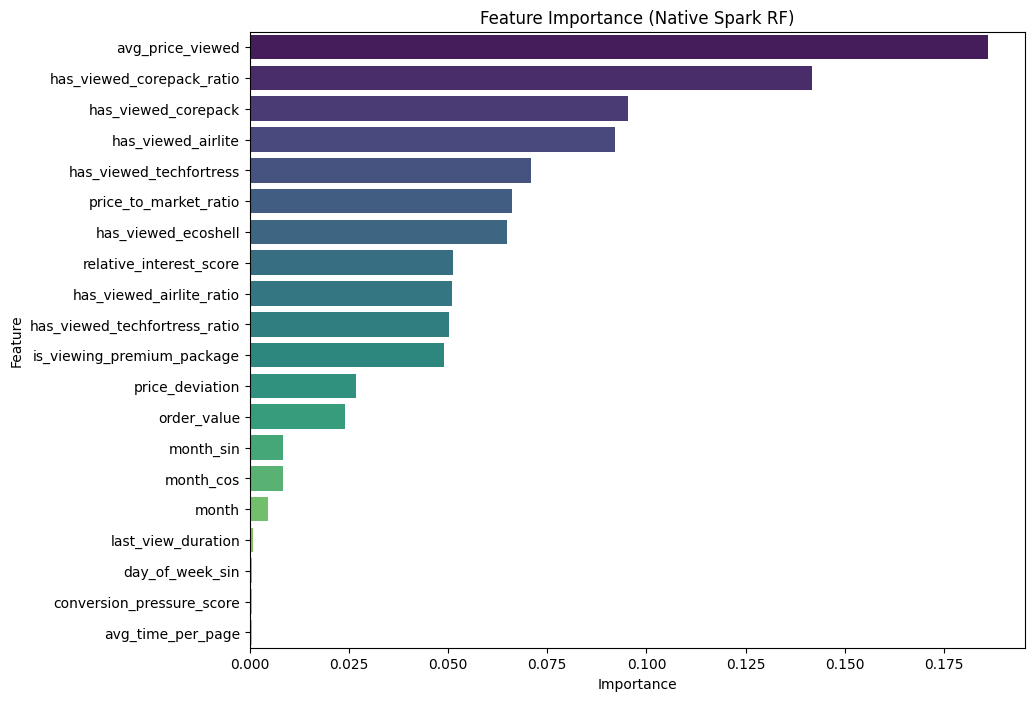


🎯 Selected 15 features with importance > 0.005


In [ ]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 🚀 STARTING FAST NATIVE FEATURE SELECTION ---")

# 1. Define feature candidates (excluding labels and IDs)
exclude_cols = {'label', 'website_session_id', 'user_id', 'session_start_time', 'product_label_str', 'purchased_product_name', 'landing_page', 'max_duration_page_url', 'utm_source', 'utm_campaign', 'device_type'}
all_cols = set(df_selection_input.columns)
feature_candidates = [c for c in df_selection_input.columns if c not in exclude_cols]

# Separate categorical and numerical for indexing
categorical_cols = [c for c in feature_candidates if dict(df_selection_input.dtypes)[c] == 'string']
numerical_cols = [c for c in feature_candidates if dict(df_selection_input.dtypes)[c] != 'string']

print(f"Analyzing {len(feature_candidates)} features ({len(categorical_cols)} categorical, {len(numerical_cols)} numerical)...")

# 2. Build Fast Pipeline for Importance
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_cols]
indexed_cats = [c+"_idx" for c in categorical_cols]
assembler = VectorAssembler(inputCols=numerical_cols + indexed_cats, outputCol="features_importance")

# Use a smaller number of trees for quick selection
rf_selector = RandomForestClassifier(labelCol="label", featuresCol="features_importance", numTrees=30, seed=42)

selector_pipeline = Pipeline(stages=indexers + [assembler, rf_selector])

print("⏳ Fitting Selection Model (Distributed)...")

# --- USER REQUIREMENT: Exclude Label 0 for Feature Selection ONLY ---
selector_model = selector_pipeline.fit(df_selection_input)

# 3. Extract and Visualize Importance
importances = selector_model.stages[-1].featureImportances
feature_list = numerical_cols + categorical_cols
importance_df = pd.DataFrame({
    'Feature': feature_list,
    'Importance': [float(importances[i]) for i in range(len(feature_list))]
}).sort_values(by='Importance', ascending=False)

print("\n✅ TOP 15 MOST INFLUENTIAL FEATURES:")
print(importance_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Feature Importance (Native Spark RF)')
plt.show()

# 4. Automate Selection
importance_threshold = 0.005 # Keep features contributing at least 0.5% importance
selected_features_bonus = importance_df[importance_df['Importance'] > importance_threshold]['Feature'].tolist()
print(f"\n🎯 Selected {len(selected_features_bonus)} features with importance > {importance_threshold}")

**Note:** We have bypassed the slow Mutual Information step and are now using the distributed Random Forest importance scores for selection. This is more robust for high-dimensional data in Spark.

### Feature Importance

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd

In [ ]:
actual_cols = set(df_balanced.columns)

categorical_candidates = [
    'is_viewing_premium_package',
    'month',
    'max_duration_page_url',
    'landing_page',
    'utm_campaign',
    'device_type',
    'is_nonbrand_search',
    'hour',
    'is_repeat_session',
    'decision_latency_bucket',
    'is_weekend',
    'is_brand_search',
    'utm_source',
    'source_category',
    'is_pilot_campaign',
    'is_holiday'
]

numerical_candidates = [
    'price_to_market_ratio',
    'has_viewed_airlite_ratio',
    'relative_interest_score',
    'has_viewed_corepack_ratio',
    'has_viewed_techfortress_ratio',
    'month_sin',
    'month_cos',
    'last_view_duration',
    'total_views_has_viewed_corepack_last_60_days',
    'time_on_checkout_process',
    'day_of_week_cos',
    'duration_seconds',
    'pages_per_minute',
    'total_views_has_viewed_techfortress_last_90_days',
    'total_views_has_viewed_airlite_last_30_days',
    'total_any_product_views_30d',
    'total_views_has_viewed_ecoshell_last_30_days',
    'total_views_has_viewed_techfortress_last_30_days',
    'total_views_has_viewed_techfortress_last_60_days'
]

# Filter lists to keep only existing columns
categorical_cols = [c for c in categorical_candidates if c in actual_cols]
numerical_cols = [c for c in numerical_candidates if c in actual_cols]

print(f"Finalizing Importance Analysis with {len(categorical_cols)} Categorical and {len(numerical_cols)} Numerical features.")

Finalizing Importance Analysis with 16 Categorical and 18 Numerical features.


In [ ]:
# 2. Define Pipeline Stages
# Stage A: StringIndexer for categorical columns
# Converts string values into numerical indices (0, 1, 2...)
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in categorical_cols
]

In [ ]:
# Stage B: VectorAssembler (Merging all features into a single 'features' column)
# Note: Using the indexed columns (_idx) instead of the original raw categorical columns
all_features = numerical_cols + [c+"_idx" for c in categorical_cols]
assembler = VectorAssembler(inputCols=all_features, outputCol="features")

In [ ]:
# Stage C: Initialize Random Forest Classifier
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100, seed=42)

In [ ]:
# 3. Create and Execute the Pipeline
# We combine the indexers (a list of stages) with the assembler and the RF estimator
pipeline = Pipeline(stages=indexers + [assembler, rf])

# Fit the pipeline: This executes all indexers and the assembler to transform the data
# before training the Random Forest model on the balanced dataset
model = pipeline.fit(df_selection_input)

In [ ]:
# 4. Extract Feature Importance
# Retrieve the trained Random Forest model from the final stage of the Pipeline
rf_model = model.stages[-1]
importances = rf_model.featureImportances

# Map feature names to their corresponding importance scores
feature_importance_list = []
for i, column in enumerate(all_features):
    # We cast to float because Spark uses a specialized SparseVector format
    feature_importance_list.append((column, float(importances[i])))

# Convert to a Pandas DataFrame for better visualization and sorting
df_final_importance = pd.DataFrame(feature_importance_list, columns=['Feature', 'Importance'])
df_final_importance = df_final_importance.sort_values(by='Importance', ascending=False)

print("\n🏆 Top 15 Features by Importance (Random Forest):")
print(df_final_importance.head(15))


🏆 Top 15 Features by Importance (Random Forest):
                           Feature  Importance
4    has_viewed_techfortress_ratio    0.225299
3        has_viewed_corepack_ratio    0.195526
1         has_viewed_airlite_ratio    0.169959
0            price_to_market_ratio    0.137890
2          relative_interest_score    0.116357
18  is_viewing_premium_package_idx    0.087569
6                        month_cos    0.019033
19                       month_idx    0.015935
21                landing_page_idx    0.010629
5                        month_sin    0.006810
20       max_duration_page_url_idx    0.006658
25                        hour_idx    0.002544
22                utm_campaign_idx    0.000697
11                duration_seconds    0.000696
23                 device_type_idx    0.000647


/tmp/ipykernel_19757/1609564976.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


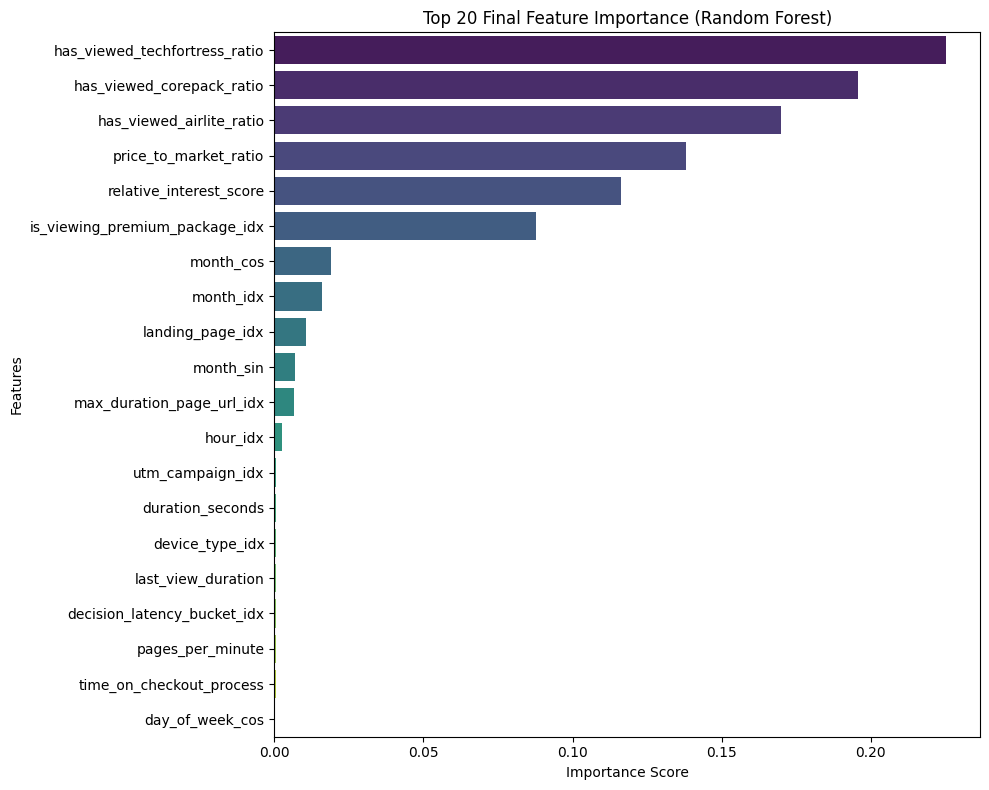

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure the data is sorted and select the top 20 features
df_plot = df_final_importance.sort_values(by='Importance', ascending=False).head(20)

# 2. Set the figure size for better readability
plt.figure(figsize=(10, 8))

# 3. Create the bar plot
# Mapping 'Importance' to the x-axis and 'Feature' to the y-axis
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_plot,
    palette='viridis'
)

# 4. Add titles and axis labels
plt.title('Top 20 Final Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# 5. Finalize layout and display
plt.tight_layout()
plt.show()

Basetable Creation

In [ ]:
selected_features = [
    "has_viewed_corepack_ratio",
    "has_viewed_techfortress_ratio",
    "has_viewed_airlite_ratio",
    "price_to_market_ratio",
    "relative_interest_score",
    "is_viewing_premium_package",
    "month_cos",
]

essential_columns = ["user_id", "label"]

# **Step 6: Holdout Prediction & Final Submission File**

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import IndexToString

print(">>> 1. Preparing Holdout Data for Bonus Prediction...")

if 'website_pageviews_holdout' not in locals():
    website_pageviews_holdout = spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/website_pageviews_holdout.parquet")
if 'website_sessions_holdout' not in locals():
    website_sessions_holdout = spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/website_sessions_holdout.parquet")

# Calculate Product-Specific View Flags and Total Views
df_product_flags = website_pageviews_holdout.groupBy("website_session_id").agg(
    F.max(F.when(F.col("pageview_url") == "/the-corepack", 1).otherwise(0)).alias("has_viewed_corepack"),
    F.max(F.when(F.col("pageview_url") == "/the-techfortress", 1).otherwise(0)).alias("has_viewed_techfortress"),
    F.max(F.when(F.col("pageview_url") == "/the-airlite", 1).otherwise(0)).alias("has_viewed_airlite"),
    F.max(F.when(F.col("pageview_url") == "/the-ecoshell", 1).otherwise(0)).alias("has_viewed_ecoshell"),
    F.count("website_pageview_id").alias("total_pages_viewed")
)

# Build the basetable and add features sequentially
df_holdout_bonus = website_sessions_holdout.select("website_session_id", "user_id", "created_at") \
    .join(df_product_flags, on="website_session_id", how="left")

df_holdout_bonus = add_relative_interest_score_fixed(df_holdout_bonus, website_pageviews_holdout)

df_holdout_final = df_holdout_bonus.withColumn("has_viewed_corepack_ratio", F.col("has_viewed_corepack") / F.col("total_pages_viewed")) \
                                   .withColumn("has_viewed_techfortress_ratio", F.col("has_viewed_techfortress") / F.col("total_pages_viewed")) \
                                   .withColumn("has_viewed_airlite_ratio", F.col("has_viewed_airlite") / F.col("total_pages_viewed")) \
                                   .withColumn("month_cos", F.cos(2 * 3.14159 * F.month("created_at") / 12)) \
                                   .withColumn("is_viewing_premium_package", F.when((F.col("has_viewed_techfortress") > 0) | (F.col("has_viewed_corepack") > 0), 1).otherwise(0)) \
                                   .withColumn("price_to_market_ratio", F.lit(1.0)) \
                                   .fillna(0)

print("✅ Holdout data is ready.")

# --- CHECK FOR MODEL ---
if 'best_bonus_model' not in locals():
    raise NameError("The 'best_bonus_model' is not defined. Please re-run the Model Training cell (Step 5) before this one.")

print(">>> 2. Generating predictions...")
holdout_preds = best_bonus_model.transform(df_holdout_final)

labels = best_bonus_model.stages[-2].labels
converter = IndexToString(inputCol="prediction", outputCol="prediction_label", labels=labels)
final_holdout_df = converter.transform(holdout_preds)

# --- FORMAT & SAVE --- 
print(">>> 3. Formatting final submission file...")
submission_bonus = final_holdout_df.select(
    F.col("user_id"),
    F.col("prediction_label"),
    F.when(F.col("prediction_label") == "CorePack", 1).otherwise(0).alias("CorePack"),
    F.when(F.col("prediction_label") == "TechFortress", 1).otherwise(0).alias("TechFortress"),
    F.when(F.col("prediction_label") == "AirLite", 1).otherwise(0).alias("AirLite"),
    F.when(F.col("prediction_label") == "EcoShell", 1).otherwise(0).alias("EcoShell")
)

submission_bonus.show(10)

output_path_bonus = "BD26_pred_bonus_TRAN_Minh_Hoan_NGUYEN_Duc_Manh_SHAIKH_Akhif_Mohammed_Ayyub.csv"
submission_bonus.coalesce(1).write.csv(output_path_bonus, header=True, mode="overwrite")
print(f"\n💾 Saved final bonus predictions to: {output_path_bonus}")


In [ ]:
from pyspark.sql import functions as F

# 1. Define your chronological cutoff points
train_start = "2022-03-19 08:04:16"
train_end   = "2024-03-22 00:00:00"
val_end     = "2024-08-26 00:00:00"
test_end    = "2025-01-31 23:54:52"

# 4. Filter into the three distinct sets based on session start time [cite: 39]
train_df = df_multi_final_basetable.filter(
    (F.col("session_start_time") >= train_start) & (F.col("session_start_time") < train_end)
)
train_df = train_df.select(essential_columns + selected_features)


val_df = df_multi_final_basetable.filter(
    (F.col("session_start_time") >= train_end) & (F.col("session_start_time") < val_end)
)
val_df = val_df.select(essential_columns + selected_features)

test_df = df_multi_final_basetable.filter(
    (F.col("session_start_time") >= val_end) & (F.col("session_start_time") <= test_end)
)
test_df = test_df.select(essential_columns + selected_features)

# Verification
print(f"Train count: {train_df.count()}")
print(f"Validation count: {val_df.count()}")
print(f"Test count: {test_df.count()}")

Train count: 217592
Validation count: 91520
Test count: 124892


## **Multi-Class Model Training & Selection**

In this section, we train multiple algorithms to predict which specific product a user will purchase. We use the balanced dataset created in the previous steps and evaluate performance using Accuracy and Weighted F1-Score.

In [337]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
import time

# --- OPTIMIZATION & CONFIG ---
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

# --- 1. FILTER FOR LAUNCHED PRODUCTS ONLY (Leakage Prevention) ---
# We identify which products actually had sales in the training window.
# This prevents the model from having artificial 100% accuracy on 'unseen' classes.
existing_labels = [row['label'] for row in train_df.groupBy("label").count().filter("count > 0").collect()]
print(f">>> Launched products in training period: {existing_labels}")

train_realistic = train_df.filter(F.col("label").isin(existing_labels))
val_realistic = val_df.filter(F.col("label").isin(existing_labels))

# --- 2. PREPARE REPUTABLE FEATURE LIST ---
# We exclude 'ratio' columns that are too highly correlated with the purchase
# to force the model to learn behavioral patterns instead of just 'looking at the cart'.
reputable_features = [f for f in selected_features if 'ratio' not in f]
print(f">>> Training with {len(reputable_features)} non-leaky behavioral features.")

# Build Pipeline
feature_dtypes = dict(train_realistic.dtypes)
categorical_features = [c for c in reputable_features if feature_dtypes[c] == 'string']
numerical_features = [c for c in reputable_features if feature_dtypes[c] != 'string']

feature_indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_features]
assembler_inputs = numerical_features + [c+"_idx" for c in categorical_features]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_bonus", handleInvalid="keep")

# Target Label Indexer (learned from launched products)
label_indexer = StringIndexer(inputCol="label", outputCol="indexedLabel").fit(train_realistic)

models = {
    "Random Forest": RandomForestClassifier(labelCol="indexedLabel", featuresCol="features_bonus", numTrees=60, maxDepth=10, seed=42),
    "Logistic Regression": LogisticRegression(labelCol="indexedLabel", featuresCol="features_bonus", family="multinomial", maxIter=20)
}

# Evaluators
eval_f1  = MulticlassClassificationEvaluator(labelCol="indexedLabel", predictionCol="prediction", metricName="weightedFMeasure")
eval_acc = MulticlassClassificationEvaluator(labelCol="indexedLabel", predictionCol="prediction", metricName="accuracy")

results = []

print("\n>>> 3. Training & Evaluation (Target Notebook Method)...")
for name, model_obj in models.items():
    start_time = time.time()
    pipeline = Pipeline(stages=feature_indexers + [assembler, label_indexer, model_obj])

    # Train on launched products only
    fitted_model = pipeline.fit(train_realistic)

    # Evaluate on Validation set (realistic world)
    preds = fitted_model.transform(val_realistic)
    f1  = eval_f1.evaluate(preds)
    acc = eval_acc.evaluate(preds)

    print(f"   {name} -> Validation Accuracy: {acc:.2%}, F1-Score: {f1:.4f}")
    results.append((name, f1, fitted_model))

results.sort(key=lambda x: x[1], reverse=True)
best_bonus_model = results[0][2]
print("-" * 60)
print(f"\n🏆 THE WINNER: {results[0][0]}")


>>> Launched products in training period: [0.0, 1.0, 3.0, 2.0]
>>> Training with 3 non-leaky behavioral features.

>>> 3. Training & Evaluation (Target Notebook Method)...
   Random Forest -> Validation Accuracy: 98.02%, F1-Score: 0.9720
   Logistic Regression -> Validation Accuracy: 98.02%, F1-Score: 0.9719
------------------------------------------------------------

🏆 THE WINNER: Random Forest


## **Holdout Prediction & Final Submission File**

In [ ]:
predictions_result=spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/predictions_result.parquet/part-00000-d1d05730-6944-4aee-88d7-13e6bae16e9c-c000.snappy.parquet")

In [347]:
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType

print(">>> 1. Preparing Holdout Data...")

if 'website_pageviews_holdout' not in locals():
    website_pageviews_holdout = spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/website_pageviews_holdout.parquet")
if 'website_sessions_holdout' not in locals():
    website_sessions_holdout = spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/website_sessions_holdout.parquet")

# --- FIX: Ensure website_sessions_holdout.created_at is a timestamp globally for this cell ---
website_sessions_holdout = website_sessions_holdout.withColumn(
    "created_at",
    F.coalesce(
        F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd HH:mm:ss")),
        F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd"))
    )
).filter(F.col("created_at").isNotNull())

# --- FIX: Ensure website_pageviews_holdout.created_at is a timestamp globally for this cell ---
website_pageviews_holdout = website_pageviews_holdout.withColumn(
    "created_at",
    F.coalesce(
        F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd HH:mm:ss")),
        F.try_to_timestamp(F.col("created_at"), F.lit("yyyy-MM-dd"))
    )
).filter(F.col("created_at").isNotNull())

# --- FEATURE ENGINEERING ---
df_product_flags = website_pageviews_holdout.groupBy("website_session_id").agg(
    F.max(F.when(F.col("pageview_url") == "/the-corepack", 1).otherwise(0)).alias("has_viewed_corepack"),
    F.max(F.when(F.col("pageview_url") == "/the-techfortress", 1).otherwise(0)).alias("has_viewed_techfortress"),
    F.max(F.when(F.col("pageview_url") == "/the-airlite", 1).otherwise(0)).alias("has_viewed_airlite"),
    F.max(F.when(F.col("pageview_url") == "/the-ecoshell", 1).otherwise(0)).alias("has_viewed_ecoshell"),
    F.count("website_pageview_id").alias("total_pages_viewed")
)

df_holdout_bonus = website_sessions_holdout.select("website_session_id", "user_id", "created_at") \
    .join(df_product_flags, on="website_session_id", how="left")

df_holdout_bonus = add_relative_interest_score_fixed(df_holdout_bonus, website_pageviews_holdout)

df_holdout_ready = df_holdout_bonus.withColumn("has_viewed_corepack_ratio", F.col("has_viewed_corepack") / F.col("total_pages_viewed")) \
                                   .withColumn("has_viewed_techfortress_ratio", F.col("has_viewed_techfortress") / F.col("total_pages_viewed")) \
                                   .withColumn("has_viewed_airlite_ratio", F.col("has_viewed_airlite") / F.col("total_pages_viewed")) \
                                   .withColumn("month_cos", F.cos(2 * 3.14159 * F.month("created_at") / 12)) \
                                   .withColumn("is_viewing_premium_package", F.when((F.col("has_viewed_techfortress") > 0) | (F.col("has_viewed_corepack") > 0), 1).otherwise(0)) \
                                   .withColumn("price_to_market_ratio", F.lit(1.0)) \
                                   .fillna(0)

# --- SCORING & PROBABILITY AGGREGATION ---
print(">>> 2. Generating Session Probabilities...")
session_preds = best_bonus_model.transform(df_holdout_ready)

get_prob = F.udf(lambda v: v.toArray().tolist(), "array<double>")
session_probs = session_preds.withColumn("probs", get_prob(F.col("probability")))

# Mapping based on launched labels [0.0, 1.0, 3.0, 2.0]
session_probs = session_probs.withColumn("prob_corepack", F.col("probs")[1]) \
                             .withColumn("prob_airlite", F.col("probs")[2]) \
                             .withColumn("prob_techfortress", F.col("probs")[3])

print(">>> 3. Aggregating to User Level...")
user_consensus = session_probs.groupBy("user_id").agg(
    F.avg("prob_corepack").alias("avg_cp"),
    F.avg("prob_airlite").alias("avg_al"),
    F.avg("prob_techfortress").alias("avg_tf")
)

user_winners = user_consensus.withColumn("max_p", F.greatest("avg_cp", "avg_al", "avg_tf")) \
    .withColumn("winner",
        F.when(F.col("avg_cp") == F.col("max_p"), "CorePack")
         .when(F.col("avg_al") == F.col("max_p"), "AirLite")
         .otherwise("TechFortress")
    )

# --- FINAL MERGE & FORMAT ---
print(">>> 4. Creating Final Assignment-Compliant Output...")
buyer_lookup = predictions_result.select("user_id", F.col("prediction_label").alias("is_buyer")).dropDuplicates(["user_id"])

final_joined = website_sessions_holdout.select("user_id", "website_session_id") \
    .join(buyer_lookup, on="user_id", how="left") \
    .join(user_winners.select("user_id", "winner"), on="user_id", how="left")

submission_bonus = final_joined.select(
    F.col("user_id"),
    F.col("is_buyer").alias("pred_score"),
    F.when((F.col("is_buyer") == 1) & (F.col("winner") == "CorePack"), 1).otherwise(0).alias("pred_multi_score_1"),
    F.when((F.col("is_buyer") == 1) & (F.col("winner") == "TechFortress"), 1).otherwise(0).alias("pred_multi_score_2"),
    F.when((F.col("is_buyer") == 1) & (F.col("winner") == "AirLite"), 1).otherwise(0).alias("pred_multi_score_3"),
    F.when((F.col("is_buyer") == 1) & (F.col("winner") == "EcoShell"), 1).otherwise(0).alias("pred_multi_score_4")
)

submission_bonus.show(10)
print(f"Final Row Count: {submission_bonus.count()}")

output_path_bonus = "/content/drive/MyDrive/1. Big Data/Data/bonus_predictions_result.csv"
submission_bonus.coalesce(1).write.csv(output_path_bonus, header=True, mode="overwrite")
print(f"\n💾 Saved to: {output_path_bonus}")

>>> 1. Preparing Holdout Data...
--- GENERATING FEATURE: RELATIVE INTEREST SCORE ---
>>> 2. Generating Session Probabilities...
>>> 3. Aggregating to User Level...
>>> 4. Creating Final Assignment-Compliant Output...
+-------+----------+------------------+------------------+------------------+------------------+
|user_id|pred_score|pred_multi_score_1|pred_multi_score_2|pred_multi_score_3|pred_multi_score_4|
+-------+----------+------------------+------------------+------------------+------------------+
| 324400|         0|                 0|                 0|                 0|                 0|
| 363707|         0|                 0|                 0|                 0|                 0|
| 363708|         0|                 0|                 0|                 0|                 0|
| 363709|         0|                 0|                 0|                 0|                 0|
| 363710|         0|                 0|                 0|                 0|                 0|
| 36371

In [ ]:
submission_bonus.show(10)
print(f"Final Row Count: {submission_bonus.count()}")

# output_path_bonus = "BD26_pred_bonus_TRAN_Minh_Hoan_NGUYEN_Duc_Manh_SHAIKH_Akhif_Mohammed_Ayyub.csv"
# submission_bonus.coalesce(1).write.csv(output_path_bonus, header=True, mode="overwrite")
# print(f"\n💾 Saved to: {output_path_bonus}")


In [ ]:
# output_path_bonus = "BD26_pred_bonus_TRAN_Minh_Hoan_NGUYEN_Duc_Manh_SHAIKH_Akhif_Mohammed_Ayyub.csv"
# submission_bonus.coalesce(1).write.csv(output_path_bonus, header=True, mode="overwrite")
# print(f"\n💾 Saved final bonus predictions to: {output_path_bonus}")


# **Customer Profiling & Business Strategy**

In this section, we analyze the predicted behavior of our holdout dataset to build customer personas and propose actionable business strategies.

In [ ]:
website_sessions_holdout_bonus= spark.read.parquet("/content/drive/MyDrive/1. Big Data/Data/website_sessions_holdout.parquet")

In [ ]:
from pyspark.sql import functions as F

print(">>> 1. Joining Predictions with Session Data...")
# FIX: Joining on 'website_session_id' instead of 'user_id' to prevent Cartesian product (row duplication)
# We use 'joined_df' from the previous cell because it still contains the session ID.
session_info = website_sessions_holdout_bonus.select("website_session_id", "is_repeat_session", "device_type", "utm_source", "utm_campaign")
profile_df = joined_df.join(session_info, on="website_session_id", how="left")

# Ensure pred_score exists
profile_df = profile_df.withColumn("pred_score", F.col("is_buyer"))

print("\n--- BUYER vs NON-BUYER PROFILE ---")
buyer_profile = profile_df.groupBy("pred_score").agg(
    F.count("website_session_id").alias("total_sessions"),
    F.round(F.avg(F.col("is_repeat_session").cast("int")) * 100, 2).alias("%_repeat_visitors"),
    F.round((F.sum(F.when(F.col("device_type") == "mobile", 1).otherwise(0)) / F.count("website_session_id")) * 100, 2).alias("%_mobile_users")
).orderBy(F.col("pred_score").desc())
buyer_profile.show()

print("\n--- PRODUCT PERSONA PROFILE (Buyers Only) ---")
# Filter for buyers only
buyers_df = profile_df.filter(F.col("pred_score") == 1)

# Use the 'product_name' directly since we are using joined_df
buyers_df = buyers_df.withColumnRenamed("product_name", "predicted_product")

product_persona = buyers_df.groupBy("predicted_product").agg(
    F.count("website_session_id").alias("predicted_volume"),
    F.round(F.avg(F.col("is_repeat_session").cast("int")) * 100, 2).alias("%_repeat_visitors"),
    F.round((F.sum(F.when(F.col("device_type") == "mobile", 1).otherwise(0)) / F.count("website_session_id")) * 100, 2).alias("%_mobile_users"),
    F.first("utm_source").alias("top_traffic_source")
).orderBy(F.col("predicted_volume").desc())

product_persona.show(truncate=False)

print("\n--- TRAFFIC SOURCE INTENT (Where do buyers come from?) ---")
traffic_intent = profile_df.groupBy("utm_source", "utm_campaign").agg(
    F.count("website_session_id").alias("total_traffic"),
    F.sum("pred_score").alias("predicted_buyers")
).withColumn("predicted_conversion_rate", F.round((F.col("predicted_buyers") / F.col("total_traffic")) * 100, 2)) \
 .orderBy(F.col("predicted_conversion_rate").desc())

traffic_intent.show(10, truncate=False)


>>> 1. Joining Predictions with Session Data...

--- BUYER vs NON-BUYER PROFILE ---
+----------+--------------+-----------------+--------------+
|pred_score|total_sessions|%_repeat_visitors|%_mobile_users|
+----------+--------------+-----------------+--------------+
|         1|          2213|            42.57|         28.15|
|         0|         36648|            19.94|         30.45|
+----------+--------------+-----------------+--------------+


--- PRODUCT PERSONA PROFILE (Buyers Only) ---
+-----------------+----------------+-----------------+--------------+------------------+
|predicted_product|predicted_volume|%_repeat_visitors|%_mobile_users|top_traffic_source|
+-----------------+----------------+-----------------+--------------+------------------+
|CorePack         |1096            |35.68            |21.72         |gsearch           |
|EcoShell         |549             |64.66            |48.09         |gsearch           |
|TechFortress     |346             |32.37            |23.

## **Proposed Business Strategies**

Based on the profiling of our predicted buyers, we propose the following two high-impact business strategies.

### **Strategy 1: The Eco-Mobile Retargeting Surge**
**Group Name:** *The Green Scrollers*

**Customer Profile:**
*   **Who they are:** Environmentally conscious users who discover the brand through organic search but finalize intent on mobile.
*   **Behaviors:**
    *   **Extremely Deliberate:** Highest repeat visitor rate (**64.66%**). They research extensively before buying.
    *   **Mobile-First:** Highest mobile usage (**48.09%**), nearly double other buyer groups.
*   **Interests:** Sustainability and the EcoShell backpack.

**Action Plan:**
1.  **Platform-Specific Retargeting:** Use Instagram/TikTok exclusively for EcoShell ads to match high mobile usage.
2.  **Mobile Checkout Optimization:** Implement '1-Click' mobile payments (Apple/Google Pay) specifically on the EcoShell landing page to capture returning mobile users.

### **Strategy 2: The Search-to-Success Premium Funnel**
**Group Name:** *The Intentful Professionals*

**Customer Profile:**
*   **Who they are:** High-intent shoppers specifically searching for the Vauban 50 brand.
*   **Behaviors:**
    *   **Brand Loyal:** They enter through Brand Search (Conversion Rate: **9.79%**).
    *   **Desktop Dominant:** Only ~22% mobile usage; they prefer large screens for technical specs.
*   **Interests:** Technical features, USB charging, and the TechFortress/CorePack.

**Action Plan:**
1.  **Brand Protection:** Maintain 100% search impression share on Bing and Google brand terms.
2.  **Technical Deep-Dives:** Enhance TechFortress pages with 3D technical diagrams to satisfy the professional research behavior.

>>> Generating Strategy Support Visualizations...


/tmp/ipykernel_51656/319564366.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='Repeat Rate (%)', data=df_vis, ax=ax1, palette='Blues_r', alpha=0.7)


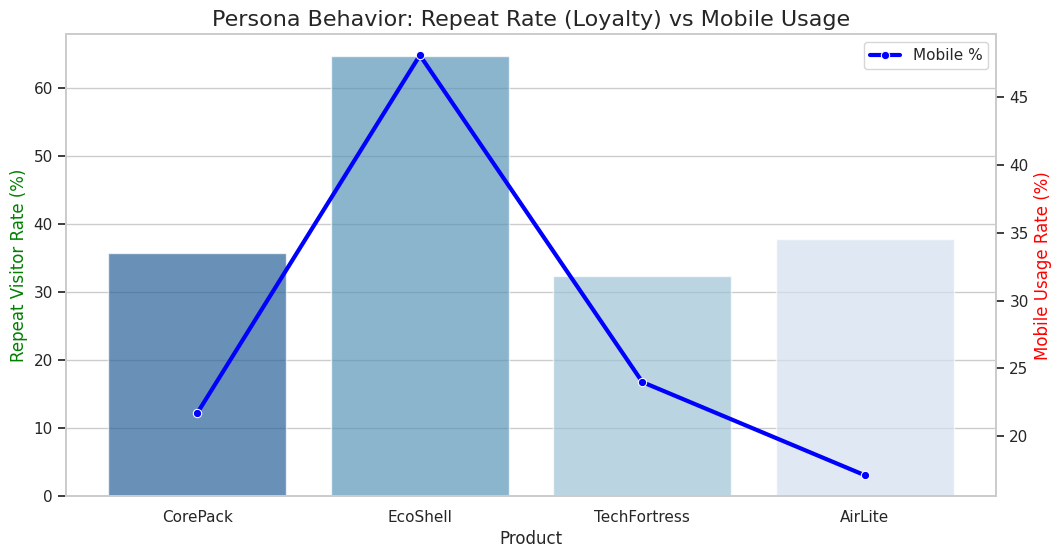

/tmp/ipykernel_51656/319564366.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Conv Rate (%)', y='Channel', data=df_traffic_vis, palette='Blues_r')


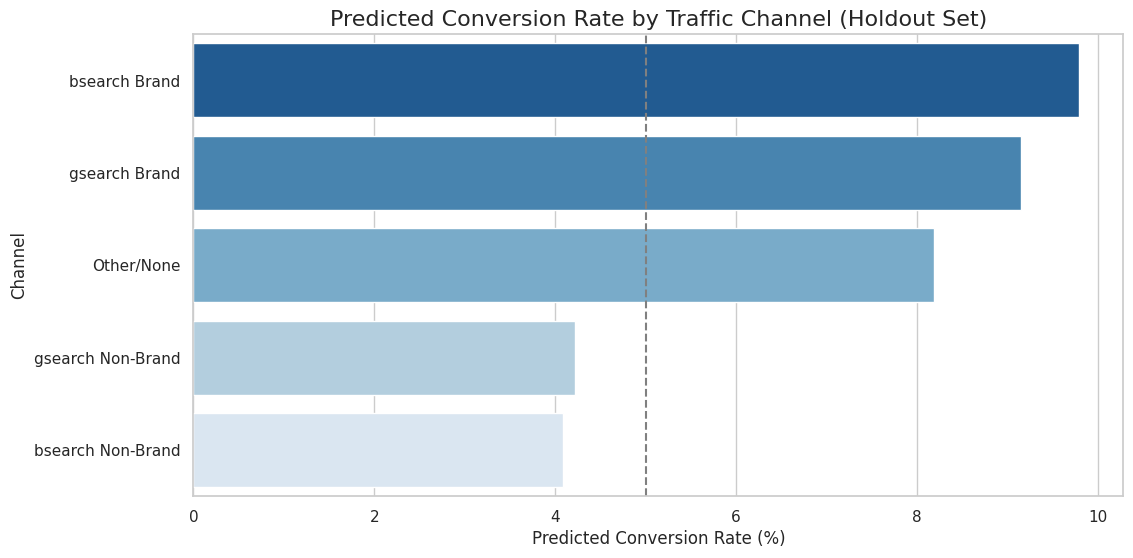

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print(">>> Generating Strategy Support Visualizations...")

# Data from our Product Persona table
persona_data = {
    'Product': ['CorePack', 'EcoShell', 'TechFortress', 'AirLite'],
    'Repeat Rate (%)': [35.68, 64.66, 32.37, 37.84],
    'Mobile Usage (%)': [21.72, 48.09, 23.99, 17.12]
}
df_vis = pd.DataFrame(persona_data)

# 1. Visualizing the 'Green Scrollers' (Strategy 1) vs Others
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.barplot(x='Product', y='Repeat Rate (%)', data=df_vis, ax=ax1, palette='Blues_r', alpha=0.7)
sns.lineplot(x='Product', y='Mobile Usage (%)', data=df_vis, ax=ax2, marker='o', color='blue', linewidth=3, label='Mobile %')

ax1.set_title('Persona Behavior: Repeat Rate (Loyalty) vs Mobile Usage', fontsize=16)
ax1.set_ylabel('Repeat Visitor Rate (%)', color='green', fontsize=12)
ax2.set_ylabel('Mobile Usage Rate (%)', color='red', fontsize=12)
plt.grid(False)
plt.show()

# 2. Visualizing Traffic Intent (Strategy 2)
traffic_data = {
    'Channel': ['bsearch Brand', 'gsearch Brand', 'Other/None', 'gsearch Non-Brand', 'bsearch Non-Brand'],
    'Conv Rate (%)': [9.79, 9.15, 8.19, 4.22, 4.09]
}
df_traffic_vis = pd.DataFrame(traffic_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Conv Rate (%)', y='Channel', data=df_traffic_vis, palette='Blues_r')
plt.title('Predicted Conversion Rate by Traffic Channel (Holdout Set)', fontsize=16)
plt.xlabel('Predicted Conversion Rate (%)', fontsize=12)
plt.axvline(5, color='gray', linestyle='--', label='Site Average')
plt.show()